In [5]:
%reload_ext autoreload
%autoreload 2
from SymptomPreprocessing import *
from SpatialPreprocessing import *
import Preprocessing as P
import Cluster
import Metrics
import re
import RPorts
import Utils
from AucComp import delong
from warnings import simplefilter

from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, GradientBoostingRegressor, AdaBoostRegressor, RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.mixture import GaussianMixture, BayesianGaussianMixture
from sklearn.decomposition import PCA
from sklearn.calibration import CalibratedClassifierCV
from sklearn.feature_selection import f_classif, f_regression, mutual_info_regression, mutual_info_classif
from sklearn.metrics import accuracy_score,f1_score, auc, precision_recall_fscore_support, matthews_corrcoef, roc_auc_score, recall_score, precision_score, roc_curve
from datetime import datetime
import statsmodels.api as sm
from scipy.stats import chi2
import seaborn as sns
import joblib

simplefilter(action='ignore')
pd.set_option('display.max_rows', 1000)

In [6]:
def timestamp():
    return datetime.now().strftime('%Y%d%H%M%S%f')
for i in range(10):
    print(timestamp())
    
def get_all_dvh(ct, key='V'):
    return sorted([col for col in ct.df if re.match(key+'\d+',col) is not None], key = lambda x: int(x[1:]) )


202323144748583770
202323144748583840
202323144748583893
202323144748583908
202323144748583950
202323144748584096
202323144748584110
202323144748584214
202323144748584227
202323144748584238


In [7]:
rds = RadDataset()
rds.get_value_array(rds.dvh_df.columns,as_df=True)

spellchecking...
renaming things
filtering pateints
adding nan values for missing organs
adding histograms
176.0 91.77084266874341 406.1887464658043
264.0 109.22534647050192 407.1108350538819


,Esophagus_D45,Esophagus_level_0,Esophagus_V20,Esophagus_D75,Esophagus_V15,Esophagus_mean_dose,Esophagus_D2,Esophagus_D95,Esophagus_min_dose,Esophagus_D20,...,Glottic_Area_D40,Glottic_Area_D60,Glottic_Area_D70,Glottic_Area_V5,Glottic_Area_D90,Glottic_Area_max_dose,Glottic_Area_D5,Glottic_Area_D25,Glottic_Area_D30,Glottic_Area_V50
id,,,,,,,,,,,,,,,,,,,,,
2.0,38.437500,9.0,85.687500,31.812500,88.250000,35.720554,54.531250,6.160156,2.97,47.093750,...,25.250000,20.171875,18.656250,100.000000,16.500000,53.34,44.968750,30.906250,29.046875,1.166992
6.0,38.625000,49.0,72.562500,17.093750,75.375000,30.499019,48.062500,2.529297,1.84,42.781250,...,32.937500,31.640625,31.093750,100.000000,29.343750,46.54,43.125000,34.656250,34.312500,0.000000
7.0,30.843750,83.0,61.500000,6.578125,64.750000,22.765716,39.968750,2.570312,1.00,35.250000,...,29.390625,28.703125,28.390625,100.000000,27.703125,31.56,30.968750,29.906250,29.734375,0.000000
8.0,24.875000,123.0,49.187500,7.281250,55.343750,19.083992,33.437500,5.300781,3.52,31.203125,...,14.078125,11.890625,9.812500,100.000000,7.859375,28.49,27.984375,15.312500,15.023438,0.000000
9.0,35.125000,37.0,86.187500,24.453125,96.437500,33.666962,56.656250,15.859375,13.58,46.031250,...,17.203125,6.519531,6.218750,100.000000,5.820312,34.52,29.468750,21.531250,20.046875,0.000000
10.0,33.968750,219.0,64.687500,10.156250,68.937500,27.220497,47.843750,4.238281,3.07,42.000000,...,44.093750,39.031250,35.718750,100.000000,29.406250,66.83,65.875000,53.656250,51.125000,31.390625
11.0,9.101562,253.0,29.250000,6.921875,34.531250,13.436690,27.562500,6.230469,5.94,25.093750,...,12.859375,11.070312,10.750000,100.000000,8.773438,34.83,20.515625,18.234375,16.093750,0.000000
12.0,1.450195,299.0,0.000000,0.770020,0.000000,1.584915,4.550781,0.020004,1.00,2.460938,...,7.421875,2.199219,1.940430,47.250000,1.629883,38.37,28.093750,12.781250,10.726562,0.000000
13.0,39.437500,333.0,78.375000,28.234375,79.625000,31.537254,43.000000,2.800781,1.00,41.406250,...,11.210938,9.679688,8.757812,100.000000,7.031250,29.07,23.343750,15.046875,14.132812,0.000000


In [8]:
def add_dose_limits(df,organ_list=None):
    #dose limits as binary values from https://applications.emro.who.int/imemrf/Rep_Radiother_Oncol/Rep_Radiother_Oncol_2013_1_1_35_48.pdf
    #not inlcudeing other stuff like eyes at this time
    #also, my max dose is weird so I'm using V10 for that because I feel like that makes sense
    #using the 
    if organ_list is None:
        organ_list = Const.organ_list[:]
    df = df.copy()
    original_cols = set(df.columns)
    getval = lambda organ,param: df[param].apply(lambda x: x[organ_list.index(organ)])
    get_lr_val = lambda organ,param: np.maximum(getval('Lt_'+organ,param),getval('Rt_'+organ,param))
    
    maxdose_var = 'max_dose'
    #symptomatic necrosis
    df['Brainstem_limit'] = (getval('Brainstem','D2') > 59) | (getval('Brainstem','D99') > 54)
    
    #myelopathy
    df['Spinal_Cord_limit'] = getval('Spinal_Cord',maxdose_var) > 50
    
    #xerostomia. >25 for 1 or >20 for both
    df['Parotid_Gland_limit'] = (get_lr_val('Parotid_Gland','mean_dose') > 20) | (getval('Lt_Parotid_Gland','mean_dose') > 25) | (getval('Rt_Parotid_Gland','mean_dose') > 25)
    
    #alternative threshold
    df['Parotid_Gland_limit2'] = get_lr_val('Parotid_Gland','mean_dose') >= 35.7
    
    #there is 50 for PEG tube and 60 for aspiration so i'll do 50
    for o in ['IPC','MPC',"SPC"]:
        df[o+"_limit"] = getval(o,'mean_dose') > 50
        df[o+"_limit2"] = getval(o,'mean_dose') > 60
    
    #ORN?
    df['Mandible_limit'] = getval('Mandible',maxdose_var) > 70
    
    #edema
    df['Larynx_limit'] = getval('Larynx','V50') > 27
    
    #Nerve damage
    df['Brachial_Plexus_limit'] = get_lr_val('Brachial_Plexus',maxdose_var) > 60
    
    #Esophagitus
    elimits = [('V35',50),('V50',40),('V70',20),('V60',30)]
    df['Esophagus_limit'] = np.stack([(getval('Esophagus',v) > lim) for v,lim in elimits]).sum(axis=0) > 0
    
#     print(df[[c for c in df.columns if  c not in original_cols]].sum())
    return df

def rds_to_df(rds,use_lstm=False,required=None,required_late=None):
    sd_df = P.get_merged_symp_dose_df(rds,roll_up=True,use_lstm=use_lstm,required_late=required_late,required=required)
#     sd_df = P.get_symptoms_max(sd_df)
    sd_df =  P.add_sd_dose_clusters(sd_df)
#     sd_df = P.add_sd_symptom_clusters(sd_df)
    sd_df = add_dose_limits(sd_df)
    return sd_df

#this version uses patients with a baselien drymouth
sddf = rds_to_df(rds,required=[],required_late=[])
sddf = P.add_sd_dose_clusters(sddf)
sddf[[c for c in sddf.columns if 'bmi' in c or 'weight' in c or 'height' in c] ].describe()

before drop count 823
after drop count 643
error (%) 0.6365789696303189
[('severe_6wk_symptoms', 0.013996889580093312), ('severe_late_symptoms', 0.015552099533437015), ('moderate_6wk_symptoms', 0.06220839813374806), ('moderate_late_symptoms', 0.05287713841368585), ('mild_6wk_symptoms', 0.208398133748056), ('mild_late_symptoms', 0.18506998444790046)]
dose ids: 484 syptom ids: 643 merged ids: 414


,baseline_height,end_of_treatment_weight,baseline_weight,wk6_weight,baseline_bmi,wk6_bmi,end_of_treatment_bmi,bmi_change,weight_loss_5kg,longterm_bmi_change
count,414.00000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,175.56715,85.423188,92.848068,82.228744,30.107357,26.819806,27.834584,-2.272773,0.125604,-3.287551
std,7.95668,9.676458,18.209778,7.242615,5.684240,3.550097,3.971563,4.825394,0.331803,5.110323
min,108.00000,54.200000,53.000000,49.300000,18.815075,17.018756,18.744796,-29.111499,0.000000,-29.912208
25%,171.00000,85.000000,82.200000,82.200000,26.836614,24.815843,25.686609,-3.684073,0.000000,-5.319626
50%,175.50000,85.000000,89.600000,82.200000,29.090673,26.688095,27.597179,-1.661137,0.000000,-2.676469
75%,181.00000,85.000000,102.500000,82.200000,32.520651,28.335318,29.411765,-0.380727,0.000000,-0.724518
max,196.50000,135.600000,186.800000,116.200000,75.445816,70.473251,72.873800,12.982271,1.000000,11.846322


In [9]:
#patients with drymout at either 6weeks or 6months
sddf2 = rds_to_df(rds,required=[],required_late=['drymouth'])
sddf2 = P.add_sd_dose_clusters(sddf2)
sddf2[[c for c in sddf2.columns if 'bmi' in c or 'weight' in c or 'height' in c] ].describe()

before drop count 823
after drop count 578
error (%) 0.617583184815022
[('severe_6wk_symptoms', 0.015570934256055362), ('severe_late_symptoms', 0.01730103806228374), ('moderate_6wk_symptoms', 0.06747404844290658), ('moderate_late_symptoms', 0.05536332179930796), ('mild_6wk_symptoms', 0.21972318339100347), ('mild_late_symptoms', 0.19377162629757785)]
dose ids: 484 syptom ids: 578 merged ids: 379


,baseline_height,end_of_treatment_weight,baseline_weight,wk6_weight,baseline_bmi,wk6_bmi,end_of_treatment_bmi,bmi_change,weight_loss_5kg,longterm_bmi_change
count,379.000000,379.000000,379.000000,379.000000,379.000000,379.000000,379.000000,379.000000,379.000000,379.000000
mean,175.593668,85.335884,93.124011,82.264908,30.191188,26.830482,27.811430,-2.379758,0.124011,-3.360706
std,8.115040,9.452492,18.455737,7.458127,5.793786,3.665851,4.043778,4.927218,0.330029,5.166807
min,108.000000,54.200000,53.000000,49.300000,18.815075,17.018756,18.744796,-29.082902,0.000000,-29.883611
25%,171.000000,85.100000,81.700000,82.300000,26.925030,24.757887,25.622476,-3.725960,0.000000,-5.472708
50%,175.750000,85.100000,90.400000,82.300000,29.266970,26.644598,27.551097,-1.726181,0.000000,-2.692623
75%,181.000000,85.100000,103.000000,82.300000,32.577667,28.389640,29.446367,-0.416850,0.000000,-0.678206
max,196.500000,125.700000,186.800000,116.200000,75.445816,70.558985,72.873800,13.022841,1.000000,11.886892


In [10]:
sddf3 = rds_to_df(rds,required=['M6_mdasi_drymouth'])
sddf3

before drop count 823
after drop count 511
error (%) 0.7169430029265533
[('severe_6wk_symptoms', 0.011741682974559686), ('severe_late_symptoms', 0.01761252446183953), ('moderate_6wk_symptoms', 0.05283757338551859), ('moderate_late_symptoms', 0.05870841487279843), ('mild_6wk_symptoms', 0.20156555772994128), ('mild_late_symptoms', 0.20743639921722112)]
dose ids: 484 syptom ids: 511 merged ids: 349


,D10,D15,D2,D20,D25,D30,D35,D40,D45,D5,...,IPC_limit,IPC_limit2,MPC_limit,MPC_limit2,SPC_limit,SPC_limit2,Mandible_limit,Larynx_limit,Brachial_Plexus_limit,Esophagus_limit
id,,,,,,,,,,,,,,,,,,,,,
2,"[51.625, 26.890625, 56.1875, 53.625, 53.75, 57...","[49.78125, 26.515625, 54.6875, 52.21875, 52.96...","[54.53125, 28.1875, 59.84375, 57.40625, 55.937...","[47.09375, 25.875, 53.09375, 50.875, 52.4375, ...","[44.4375, 25.453125, 51.375, 49.75, 52.03125, ...","[42.53125, 25.078125, 49.71875, 48.6875, 51.65...","[41.03125, 24.703125, 48.03125, 47.75, 51.3125...","[39.78125, 24.375, 46.46875, 46.625, 51.0, 51....","[38.4375, 24.125, 44.875, 45.6875, 50.5625, 51...","[53.21875, 27.4375, 58.28125, 55.5, 54.90625, ...",...,False,False,True,True,True,True,True,False,True,True
7,"[37.625, 37.15625, 66.3125, 60.3125, 49.4375, ...","[36.5625, 36.75, 64.0625, 59.96875, 48.375, 49...","[39.96875, 38.0625, 71.8125, 60.90625, 52.1562...","[35.25, 36.34375, 62.71875, 59.71875, 47.34375...","[34.0625, 35.90625, 61.53125, 59.40625, 46.562...","[33.125, 35.5, 60.34375, 59.1875, 45.6875, 43....","[32.28125, 35.03125, 59.03125, 58.90625, 44.75...","[31.609375, 34.625, 57.71875, 58.625, 43.96875...","[30.84375, 34.1875, 56.40625, 58.3125, 43.1875...","[38.6875, 37.625, 71.0625, 60.625, 50.75, 53.8...",...,True,False,True,False,True,False,True,False,True,False
8,"[32.15625, 32.0625, 65.375, 56.6875, 22.5, 31....","[31.703125, 31.109375, 63.34375, 55.75, 21.312...","[33.4375, 34.09375, 68.75, 58.28125, 33.6875, ...","[31.203125, 30.25, 61.34375, 54.5625, 17.84375...","[30.609375, 29.40625, 60.03125, 52.375, 14.367...","[29.9375, 28.390625, 59.5, 50.5625, 13.140625,...","[28.96875, 27.453125, 58.96875, 49.46875, 11.7...","[27.1875, 26.46875, 58.53125, 48.59375, 11.203...","[24.875, 25.453125, 58.125, 48.0, 10.9609375, ...","[32.78125, 33.125, 67.375, 57.65625, 25.3125, ...",...,True,False,True,True,True,True,True,True,True,False
9,"[51.4375, 27.515625, 51.4375, 51.4375, 18.6875...","[48.59375, 26.671875, 48.59375, 48.59375, 15.0...","[56.65625, 29.5625, 56.65625, 56.65625, 27.312...","[46.03125, 25.9375, 46.03125, 46.03125, 13.0, ...","[43.53125, 25.296875, 43.53125, 43.53125, 11.3...","[41.28125, 24.671875, 41.28125, 41.28125, 10.3...","[39.15625, 24.046875, 39.15625, 39.15625, 9.82...","[37.0, 23.359375, 37.0, 37.0, 9.4609375, 11.28...","[35.125, 22.625, 35.125, 35.125, 9.109375, 9.3...","[54.46875, 28.625, 54.46875, 54.46875, 23.3125...",...,False,False,False,False,False,False,False,False,False,False
10,"[44.21875, 35.625, 64.75, 55.9375, 52.84375, 5...","[43.1875, 34.28125, 62.6875, 54.3125, 50.78125...","[47.84375, 39.21875, 68.5625, 58.15625, 57.406...","[42.0, 33.125, 59.53125, 52.84375, 48.875, 46....","[40.71875, 32.34375, 58.65625, 51.4375, 47.343...","[38.90625, 31.625, 58.3125, 50.0, 46.5, 44.687...","[36.875, 30.921875, 57.8125, 48.75, 46.125, 43...","[35.5625, 30.1875, 56.6875, 47.6875, 45.75, 43...","[33.96875, 29.4375, 55.03125, 46.4375, 45.3125...","[45.71875, 37.34375, 66.6875, 57.46875, 55.25,...",...,True,True,True,True,True,True,True,True,True,False
12,"[3.279296875, 34.4375, 49.25, 1.7197265625, 7....","[2.83984375, 33.34375, 49.0, 1.400390625, 5.67...","[4.55078125, 37.125, 49.6875, 8.3203125, 19.34...","[2.4609375, 32.375, 48.71875, 1.259765625, 4.3...","[2.16015625, 31.453125, 48.375, 1.169921875, 3...","[1.9404296875, 30.515625, 47.9375, 1.110351562...","[1.759765625, 29.515625, 47.3125, 1.0498046875...","[1.599609375, 28.171875, 46.46875, 1.0, 2.5097...","[1.4501953125, 22.609375, 45.21875, 0.95996093...","[3.900390625, 35.8125, 49.53125, 4.3515625, 11...",...,False,False,False,False,False,False,False,False,False,False
13,"[42.21875, 29.625, 60.46875, 48.6875, 19.5, 41...","[41.8125, 29.046875, 58.34375, 48.15625, 14.52...","[43.0, 31.0, 70.625, 54.09375, 35.5625, 51.0, ...","[41.40625, 28.46875, 56.4375, 47.8125, 12.9921...","[41.03125, 27.859375, 54.5, 47.59375, 10.29687...","[40.65625, 27.234375, 52.78125, 47.375, 9.3593...",

In [11]:
def get_symptom_stats(df,symptoms=None,weeks=[33],thresholds=[1,3,5]):
    if symptoms is None:
        symptoms = [c.replace('symptoms_','') for c in df.columns if 'symptoms_' in c and 'original' not in c]
    res = []
    for week in weeks:
        dateloc = df.dates.iloc[0].index(week)
        for s in symptoms:
            for threshold in thresholds:
                vals = df['symptoms_'+s]
                start = vals.apply(lambda x: x[0]).values
                end = vals.apply(lambda x: x[dateloc]).values
                severe_change = (end-start >= threshold).astype(float)
                severe = (end >= threshold).astype(float)
                quants = np.quantile(end,[.05,.5,.95])
                entry = {
                    'symptom': s,
                    'threshold': threshold,
                    'endpoint': week,
                    'severe_total': severe.sum(),
                    'severe_mean': severe.mean(),
                    'severe_change_total': severe_change.sum(),
                    'severe_change_mean': severe_change.mean(),
                    'symptom_mean': end.mean(),
                }
                for i,q in zip([.05,.5,.95],quants):
                    entry[str(int(i*100))+'%'] = q
                res.append(entry)
    return pd.DataFrame(res)

get_symptom_stats(sddf3,symptoms=['drymouth','swallow','choke','mucus','mucositis','voice'])

,symptom,threshold,endpoint,severe_total,severe_mean,severe_change_total,severe_change_mean,symptom_mean,5%,50%,95%
0,drymouth,1,33,331.0,0.948424,295.0,0.845272,4.338109,0.4,4.0,9.0
1,drymouth,3,33,241.0,0.690544,203.0,0.581662,4.338109,0.4,4.0,9.0
2,drymouth,5,33,153.0,0.438395,114.0,0.326648,4.338109,0.4,4.0,9.0
3,swallow,1,33,259.0,0.742120,199.0,0.570201,2.137536,0.0,2.0,7.0
4,swallow,3,33,112.0,0.320917,73.0,0.209169,2.137536,0.0,2.0,7.0
5,swallow,5,33,46.0,0.131805,29.0,0.083095,2.137536,0.0,2.0,7.0
6,choke,1,33,177.0,0.507163,137.0,0.392550,1.111748,0.0,1.0,5.0
7,choke,3,33,52.0,0.148997,34.0,0.097421,1.111748,0.0,1.0,5.0
8,choke,5,33,19.0,0.054441,14.0,0.040115,1.111748,0.0,1.0,5.0
9,mucus,1,33,255.0,0.730659,202.0,0.578797,2.263610,0.0,2.0,8.0


In [12]:
#patients with choke at either 6weeks or 6months
choke_df = rds_to_df(rds,required=['M6_mdasi_choke'],required_late=[])
choke_df

before drop count 823
after drop count 509
error (%) 0.7465936106253808
[('severe_6wk_symptoms', 0.011787819253438114), ('severe_late_symptoms', 0.01768172888015717), ('moderate_6wk_symptoms', 0.05304518664047151), ('moderate_late_symptoms', 0.05893909626719057), ('mild_6wk_symptoms', 0.20039292730844793), ('mild_late_symptoms', 0.2082514734774067)]
dose ids: 484 syptom ids: 509 merged ids: 347


,D10,D15,D2,D20,D25,D30,D35,D40,D45,D5,...,IPC_limit,IPC_limit2,MPC_limit,MPC_limit2,SPC_limit,SPC_limit2,Mandible_limit,Larynx_limit,Brachial_Plexus_limit,Esophagus_limit
id,,,,,,,,,,,,,,,,,,,,,
2,"[51.625, 26.890625, 56.1875, 53.625, 53.75, 57...","[49.78125, 26.515625, 54.6875, 52.21875, 52.96...","[54.53125, 28.1875, 59.84375, 57.40625, 55.937...","[47.09375, 25.875, 53.09375, 50.875, 52.4375, ...","[44.4375, 25.453125, 51.375, 49.75, 52.03125, ...","[42.53125, 25.078125, 49.71875, 48.6875, 51.65...","[41.03125, 24.703125, 48.03125, 47.75, 51.3125...","[39.78125, 24.375, 46.46875, 46.625, 51.0, 51....","[38.4375, 24.125, 44.875, 45.6875, 50.5625, 51...","[53.21875, 27.4375, 58.28125, 55.5, 54.90625, ...",...,False,False,True,True,True,True,True,False,True,True
7,"[37.625, 37.15625, 66.3125, 60.3125, 49.4375, ...","[36.5625, 36.75, 64.0625, 59.96875, 48.375, 49...","[39.96875, 38.0625, 71.8125, 60.90625, 52.1562...","[35.25, 36.34375, 62.71875, 59.71875, 47.34375...","[34.0625, 35.90625, 61.53125, 59.40625, 46.562...","[33.125, 35.5, 60.34375, 59.1875, 45.6875, 43....","[32.28125, 35.03125, 59.03125, 58.90625, 44.75...","[31.609375, 34.625, 57.71875, 58.625, 43.96875...","[30.84375, 34.1875, 56.40625, 58.3125, 43.1875...","[38.6875, 37.625, 71.0625, 60.625, 50.75, 53.8...",...,True,False,True,False,True,False,True,False,True,False
8,"[32.15625, 32.0625, 65.375, 56.6875, 22.5, 31....","[31.703125, 31.109375, 63.34375, 55.75, 21.312...","[33.4375, 34.09375, 68.75, 58.28125, 33.6875, ...","[31.203125, 30.25, 61.34375, 54.5625, 17.84375...","[30.609375, 29.40625, 60.03125, 52.375, 14.367...","[29.9375, 28.390625, 59.5, 50.5625, 13.140625,...","[28.96875, 27.453125, 58.96875, 49.46875, 11.7...","[27.1875, 26.46875, 58.53125, 48.59375, 11.203...","[24.875, 25.453125, 58.125, 48.0, 10.9609375, ...","[32.78125, 33.125, 67.375, 57.65625, 25.3125, ...",...,True,False,True,True,True,True,True,True,True,False
9,"[51.4375, 27.515625, 51.4375, 51.4375, 18.6875...","[48.59375, 26.671875, 48.59375, 48.59375, 15.0...","[56.65625, 29.5625, 56.65625, 56.65625, 27.312...","[46.03125, 25.9375, 46.03125, 46.03125, 13.0, ...","[43.53125, 25.296875, 43.53125, 43.53125, 11.3...","[41.28125, 24.671875, 41.28125, 41.28125, 10.3...","[39.15625, 24.046875, 39.15625, 39.15625, 9.82...","[37.0, 23.359375, 37.0, 37.0, 9.4609375, 11.28...","[35.125, 22.625, 35.125, 35.125, 9.109375, 9.3...","[54.46875, 28.625, 54.46875, 54.46875, 23.3125...",...,False,False,False,False,False,False,False,False,False,False
10,"[44.21875, 35.625, 64.75, 55.9375, 52.84375, 5...","[43.1875, 34.28125, 62.6875, 54.3125, 50.78125...","[47.84375, 39.21875, 68.5625, 58.15625, 57.406...","[42.0, 33.125, 59.53125, 52.84375, 48.875, 46....","[40.71875, 32.34375, 58.65625, 51.4375, 47.343...","[38.90625, 31.625, 58.3125, 50.0, 46.5, 44.687...","[36.875, 30.921875, 57.8125, 48.75, 46.125, 43...","[35.5625, 30.1875, 56.6875, 47.6875, 45.75, 43...","[33.96875, 29.4375, 55.03125, 46.4375, 45.3125...","[45.71875, 37.34375, 66.6875, 57.46875, 55.25,...",...,True,True,True,True,True,True,True,True,True,False
12,"[3.279296875, 34.4375, 49.25, 1.7197265625, 7....","[2.83984375, 33.34375, 49.0, 1.400390625, 5.67...","[4.55078125, 37.125, 49.6875, 8.3203125, 19.34...","[2.4609375, 32.375, 48.71875, 1.259765625, 4.3...","[2.16015625, 31.453125, 48.375, 1.169921875, 3...","[1.9404296875, 30.515625, 47.9375, 1.110351562...","[1.759765625, 29.515625, 47.3125, 1.0498046875...","[1.599609375, 28.171875, 46.46875, 1.0, 2.5097...","[1.4501953125, 22.609375, 45.21875, 0.95996093...","[3.900390625, 35.8125, 49.53125, 4.3515625, 11...",...,False,False,False,False,False,False,False,False,False,False
13,"[42.21875, 29.625, 60.46875, 48.6875, 19.5, 41...","[41.8125, 29.046875, 58.34375, 48.15625, 14.52...","[43.0, 31.0, 70.625, 54.09375, 35.5625, 51.0, ...","[41.40625, 28.46875, 56.4375, 47.8125, 12.9921...","[41.03125, 27.859375, 54.5, 47.59375, 10.29687...","[40.65625, 27.234375, 52.78125, 47.375, 9.3593...",

In [13]:
swallowdf = rds_to_df(rds,required=['M6_mdasi_swallow'],required_late=[])
swallowdf

before drop count 823
after drop count 512
error (%) 0.7015278718251049
[('severe_6wk_symptoms', 0.01171875), ('severe_late_symptoms', 0.017578125), ('moderate_6wk_symptoms', 0.0546875), ('moderate_late_symptoms', 0.05859375), ('mild_6wk_symptoms', 0.193359375), ('mild_late_symptoms', 0.20703125)]
dose ids: 484 syptom ids: 512 merged ids: 349


,D10,D15,D2,D20,D25,D30,D35,D40,D45,D5,...,IPC_limit,IPC_limit2,MPC_limit,MPC_limit2,SPC_limit,SPC_limit2,Mandible_limit,Larynx_limit,Brachial_Plexus_limit,Esophagus_limit
id,,,,,,,,,,,,,,,,,,,,,
2,"[51.625, 26.890625, 56.1875, 53.625, 53.75, 57...","[49.78125, 26.515625, 54.6875, 52.21875, 52.96...","[54.53125, 28.1875, 59.84375, 57.40625, 55.937...","[47.09375, 25.875, 53.09375, 50.875, 52.4375, ...","[44.4375, 25.453125, 51.375, 49.75, 52.03125, ...","[42.53125, 25.078125, 49.71875, 48.6875, 51.65...","[41.03125, 24.703125, 48.03125, 47.75, 51.3125...","[39.78125, 24.375, 46.46875, 46.625, 51.0, 51....","[38.4375, 24.125, 44.875, 45.6875, 50.5625, 51...","[53.21875, 27.4375, 58.28125, 55.5, 54.90625, ...",...,False,False,True,True,True,True,True,False,True,True
7,"[37.625, 37.15625, 66.3125, 60.3125, 49.4375, ...","[36.5625, 36.75, 64.0625, 59.96875, 48.375, 49...","[39.96875, 38.0625, 71.8125, 60.90625, 52.1562...","[35.25, 36.34375, 62.71875, 59.71875, 47.34375...","[34.0625, 35.90625, 61.53125, 59.40625, 46.562...","[33.125, 35.5, 60.34375, 59.1875, 45.6875, 43....","[32.28125, 35.03125, 59.03125, 58.90625, 44.75...","[31.609375, 34.625, 57.71875, 58.625, 43.96875...","[30.84375, 34.1875, 56.40625, 58.3125, 43.1875...","[38.6875, 37.625, 71.0625, 60.625, 50.75, 53.8...",...,True,False,True,False,True,False,True,False,True,False
8,"[32.15625, 32.0625, 65.375, 56.6875, 22.5, 31....","[31.703125, 31.109375, 63.34375, 55.75, 21.312...","[33.4375, 34.09375, 68.75, 58.28125, 33.6875, ...","[31.203125, 30.25, 61.34375, 54.5625, 17.84375...","[30.609375, 29.40625, 60.03125, 52.375, 14.367...","[29.9375, 28.390625, 59.5, 50.5625, 13.140625,...","[28.96875, 27.453125, 58.96875, 49.46875, 11.7...","[27.1875, 26.46875, 58.53125, 48.59375, 11.203...","[24.875, 25.453125, 58.125, 48.0, 10.9609375, ...","[32.78125, 33.125, 67.375, 57.65625, 25.3125, ...",...,True,False,True,True,True,True,True,True,True,False
9,"[51.4375, 27.515625, 51.4375, 51.4375, 18.6875...","[48.59375, 26.671875, 48.59375, 48.59375, 15.0...","[56.65625, 29.5625, 56.65625, 56.65625, 27.312...","[46.03125, 25.9375, 46.03125, 46.03125, 13.0, ...","[43.53125, 25.296875, 43.53125, 43.53125, 11.3...","[41.28125, 24.671875, 41.28125, 41.28125, 10.3...","[39.15625, 24.046875, 39.15625, 39.15625, 9.82...","[37.0, 23.359375, 37.0, 37.0, 9.4609375, 11.28...","[35.125, 22.625, 35.125, 35.125, 9.109375, 9.3...","[54.46875, 28.625, 54.46875, 54.46875, 23.3125...",...,False,False,False,False,False,False,False,False,False,False
10,"[44.21875, 35.625, 64.75, 55.9375, 52.84375, 5...","[43.1875, 34.28125, 62.6875, 54.3125, 50.78125...","[47.84375, 39.21875, 68.5625, 58.15625, 57.406...","[42.0, 33.125, 59.53125, 52.84375, 48.875, 46....","[40.71875, 32.34375, 58.65625, 51.4375, 47.343...","[38.90625, 31.625, 58.3125, 50.0, 46.5, 44.687...","[36.875, 30.921875, 57.8125, 48.75, 46.125, 43...","[35.5625, 30.1875, 56.6875, 47.6875, 45.75, 43...","[33.96875, 29.4375, 55.03125, 46.4375, 45.3125...","[45.71875, 37.34375, 66.6875, 57.46875, 55.25,...",...,True,True,True,True,True,True,True,True,True,False
12,"[3.279296875, 34.4375, 49.25, 1.7197265625, 7....","[2.83984375, 33.34375, 49.0, 1.400390625, 5.67...","[4.55078125, 37.125, 49.6875, 8.3203125, 19.34...","[2.4609375, 32.375, 48.71875, 1.259765625, 4.3...","[2.16015625, 31.453125, 48.375, 1.169921875, 3...","[1.9404296875, 30.515625, 47.9375, 1.110351562...","[1.759765625, 29.515625, 47.3125, 1.0498046875...","[1.599609375, 28.171875, 46.46875, 1.0, 2.5097...","[1.4501953125, 22.609375, 45.21875, 0.95996093...","[3.900390625, 35.8125, 49.53125, 4.3515625, 11...",...,False,False,False,False,False,False,False,False,False,False
13,"[42.21875, 29.625, 60.46875, 48.6875, 19.5, 41...","[41.8125, 29.046875, 58.34375, 48.15625, 14.52...","[43.0, 31.0, 70.625, 54.09375, 35.5625, 51.0, ...","[41.40625, 28.46875, 56.4375, 47.8125, 12.9921...","[41.03125, 27.859375, 54.5, 47.59375, 10.29687...","[40.65625, 27.234375, 52.78125, 47.375, 9.3593...",

In [14]:
mucus_df = rds_to_df(rds,required=['M6_mdasi_mucus'],required_late=[])
mucus_df

before drop count 823
after drop count 512
error (%) 0.8534130335039721
[('severe_6wk_symptoms', 0.01171875), ('severe_late_symptoms', 0.017578125), ('moderate_6wk_symptoms', 0.0546875), ('moderate_late_symptoms', 0.05859375), ('mild_6wk_symptoms', 0.1953125), ('mild_late_symptoms', 0.20703125)]
dose ids: 484 syptom ids: 512 merged ids: 349


,D10,D15,D2,D20,D25,D30,D35,D40,D45,D5,...,IPC_limit,IPC_limit2,MPC_limit,MPC_limit2,SPC_limit,SPC_limit2,Mandible_limit,Larynx_limit,Brachial_Plexus_limit,Esophagus_limit
id,,,,,,,,,,,,,,,,,,,,,
2,"[51.625, 26.890625, 56.1875, 53.625, 53.75, 57...","[49.78125, 26.515625, 54.6875, 52.21875, 52.96...","[54.53125, 28.1875, 59.84375, 57.40625, 55.937...","[47.09375, 25.875, 53.09375, 50.875, 52.4375, ...","[44.4375, 25.453125, 51.375, 49.75, 52.03125, ...","[42.53125, 25.078125, 49.71875, 48.6875, 51.65...","[41.03125, 24.703125, 48.03125, 47.75, 51.3125...","[39.78125, 24.375, 46.46875, 46.625, 51.0, 51....","[38.4375, 24.125, 44.875, 45.6875, 50.5625, 51...","[53.21875, 27.4375, 58.28125, 55.5, 54.90625, ...",...,False,False,True,True,True,True,True,False,True,True
7,"[37.625, 37.15625, 66.3125, 60.3125, 49.4375, ...","[36.5625, 36.75, 64.0625, 59.96875, 48.375, 49...","[39.96875, 38.0625, 71.8125, 60.90625, 52.1562...","[35.25, 36.34375, 62.71875, 59.71875, 47.34375...","[34.0625, 35.90625, 61.53125, 59.40625, 46.562...","[33.125, 35.5, 60.34375, 59.1875, 45.6875, 43....","[32.28125, 35.03125, 59.03125, 58.90625, 44.75...","[31.609375, 34.625, 57.71875, 58.625, 43.96875...","[30.84375, 34.1875, 56.40625, 58.3125, 43.1875...","[38.6875, 37.625, 71.0625, 60.625, 50.75, 53.8...",...,True,False,True,False,True,False,True,False,True,False
8,"[32.15625, 32.0625, 65.375, 56.6875, 22.5, 31....","[31.703125, 31.109375, 63.34375, 55.75, 21.312...","[33.4375, 34.09375, 68.75, 58.28125, 33.6875, ...","[31.203125, 30.25, 61.34375, 54.5625, 17.84375...","[30.609375, 29.40625, 60.03125, 52.375, 14.367...","[29.9375, 28.390625, 59.5, 50.5625, 13.140625,...","[28.96875, 27.453125, 58.96875, 49.46875, 11.7...","[27.1875, 26.46875, 58.53125, 48.59375, 11.203...","[24.875, 25.453125, 58.125, 48.0, 10.9609375, ...","[32.78125, 33.125, 67.375, 57.65625, 25.3125, ...",...,True,False,True,True,True,True,True,True,True,False
9,"[51.4375, 27.515625, 51.4375, 51.4375, 18.6875...","[48.59375, 26.671875, 48.59375, 48.59375, 15.0...","[56.65625, 29.5625, 56.65625, 56.65625, 27.312...","[46.03125, 25.9375, 46.03125, 46.03125, 13.0, ...","[43.53125, 25.296875, 43.53125, 43.53125, 11.3...","[41.28125, 24.671875, 41.28125, 41.28125, 10.3...","[39.15625, 24.046875, 39.15625, 39.15625, 9.82...","[37.0, 23.359375, 37.0, 37.0, 9.4609375, 11.28...","[35.125, 22.625, 35.125, 35.125, 9.109375, 9.3...","[54.46875, 28.625, 54.46875, 54.46875, 23.3125...",...,False,False,False,False,False,False,False,False,False,False
10,"[44.21875, 35.625, 64.75, 55.9375, 52.84375, 5...","[43.1875, 34.28125, 62.6875, 54.3125, 50.78125...","[47.84375, 39.21875, 68.5625, 58.15625, 57.406...","[42.0, 33.125, 59.53125, 52.84375, 48.875, 46....","[40.71875, 32.34375, 58.65625, 51.4375, 47.343...","[38.90625, 31.625, 58.3125, 50.0, 46.5, 44.687...","[36.875, 30.921875, 57.8125, 48.75, 46.125, 43...","[35.5625, 30.1875, 56.6875, 47.6875, 45.75, 43...","[33.96875, 29.4375, 55.03125, 46.4375, 45.3125...","[45.71875, 37.34375, 66.6875, 57.46875, 55.25,...",...,True,True,True,True,True,True,True,True,True,False
12,"[3.279296875, 34.4375, 49.25, 1.7197265625, 7....","[2.83984375, 33.34375, 49.0, 1.400390625, 5.67...","[4.55078125, 37.125, 49.6875, 8.3203125, 19.34...","[2.4609375, 32.375, 48.71875, 1.259765625, 4.3...","[2.16015625, 31.453125, 48.375, 1.169921875, 3...","[1.9404296875, 30.515625, 47.9375, 1.110351562...","[1.759765625, 29.515625, 47.3125, 1.0498046875...","[1.599609375, 28.171875, 46.46875, 1.0, 2.5097...","[1.4501953125, 22.609375, 45.21875, 0.95996093...","[3.900390625, 35.8125, 49.53125, 4.3515625, 11...",...,False,False,False,False,False,False,False,False,False,False
13,"[42.21875, 29.625, 60.46875, 48.6875, 19.5, 41...","[41.8125, 29.046875, 58.34375, 48.15625, 14.52...","[43.0, 31.0, 70.625, 54.09375, 35.5625, 51.0, ...","[41.40625, 28.46875, 56.4375, 47.8125, 12.9921...","[41.03125, 27.859375, 54.5, 47.59375, 10.29687...","[40.65625, 27.234375, 52.78125, 47.375, 9.3593...",

In [15]:
voice_df = rds_to_df(rds,required=['M6_mdasi_voice'],required_late=[])
voice_df

before drop count 823
after drop count 508
error (%) 0.6599186271873672
[('severe_6wk_symptoms', 0.00984251968503937), ('severe_late_symptoms', 0.015748031496062992), ('moderate_6wk_symptoms', 0.051181102362204724), ('moderate_late_symptoms', 0.05511811023622047), ('mild_6wk_symptoms', 0.19881889763779528), ('mild_late_symptoms', 0.20275590551181102)]
dose ids: 484 syptom ids: 508 merged ids: 346


,D10,D15,D2,D20,D25,D30,D35,D40,D45,D5,...,IPC_limit,IPC_limit2,MPC_limit,MPC_limit2,SPC_limit,SPC_limit2,Mandible_limit,Larynx_limit,Brachial_Plexus_limit,Esophagus_limit
id,,,,,,,,,,,,,,,,,,,,,
2,"[51.625, 26.890625, 56.1875, 53.625, 53.75, 57...","[49.78125, 26.515625, 54.6875, 52.21875, 52.96...","[54.53125, 28.1875, 59.84375, 57.40625, 55.937...","[47.09375, 25.875, 53.09375, 50.875, 52.4375, ...","[44.4375, 25.453125, 51.375, 49.75, 52.03125, ...","[42.53125, 25.078125, 49.71875, 48.6875, 51.65...","[41.03125, 24.703125, 48.03125, 47.75, 51.3125...","[39.78125, 24.375, 46.46875, 46.625, 51.0, 51....","[38.4375, 24.125, 44.875, 45.6875, 50.5625, 51...","[53.21875, 27.4375, 58.28125, 55.5, 54.90625, ...",...,False,False,True,True,True,True,True,False,True,True
7,"[37.625, 37.15625, 66.3125, 60.3125, 49.4375, ...","[36.5625, 36.75, 64.0625, 59.96875, 48.375, 49...","[39.96875, 38.0625, 71.8125, 60.90625, 52.1562...","[35.25, 36.34375, 62.71875, 59.71875, 47.34375...","[34.0625, 35.90625, 61.53125, 59.40625, 46.562...","[33.125, 35.5, 60.34375, 59.1875, 45.6875, 43....","[32.28125, 35.03125, 59.03125, 58.90625, 44.75...","[31.609375, 34.625, 57.71875, 58.625, 43.96875...","[30.84375, 34.1875, 56.40625, 58.3125, 43.1875...","[38.6875, 37.625, 71.0625, 60.625, 50.75, 53.8...",...,True,False,True,False,True,False,True,False,True,False
8,"[32.15625, 32.0625, 65.375, 56.6875, 22.5, 31....","[31.703125, 31.109375, 63.34375, 55.75, 21.312...","[33.4375, 34.09375, 68.75, 58.28125, 33.6875, ...","[31.203125, 30.25, 61.34375, 54.5625, 17.84375...","[30.609375, 29.40625, 60.03125, 52.375, 14.367...","[29.9375, 28.390625, 59.5, 50.5625, 13.140625,...","[28.96875, 27.453125, 58.96875, 49.46875, 11.7...","[27.1875, 26.46875, 58.53125, 48.59375, 11.203...","[24.875, 25.453125, 58.125, 48.0, 10.9609375, ...","[32.78125, 33.125, 67.375, 57.65625, 25.3125, ...",...,True,False,True,True,True,True,True,True,True,False
9,"[51.4375, 27.515625, 51.4375, 51.4375, 18.6875...","[48.59375, 26.671875, 48.59375, 48.59375, 15.0...","[56.65625, 29.5625, 56.65625, 56.65625, 27.312...","[46.03125, 25.9375, 46.03125, 46.03125, 13.0, ...","[43.53125, 25.296875, 43.53125, 43.53125, 11.3...","[41.28125, 24.671875, 41.28125, 41.28125, 10.3...","[39.15625, 24.046875, 39.15625, 39.15625, 9.82...","[37.0, 23.359375, 37.0, 37.0, 9.4609375, 11.28...","[35.125, 22.625, 35.125, 35.125, 9.109375, 9.3...","[54.46875, 28.625, 54.46875, 54.46875, 23.3125...",...,False,False,False,False,False,False,False,False,False,False
10,"[44.21875, 35.625, 64.75, 55.9375, 52.84375, 5...","[43.1875, 34.28125, 62.6875, 54.3125, 50.78125...","[47.84375, 39.21875, 68.5625, 58.15625, 57.406...","[42.0, 33.125, 59.53125, 52.84375, 48.875, 46....","[40.71875, 32.34375, 58.65625, 51.4375, 47.343...","[38.90625, 31.625, 58.3125, 50.0, 46.5, 44.687...","[36.875, 30.921875, 57.8125, 48.75, 46.125, 43...","[35.5625, 30.1875, 56.6875, 47.6875, 45.75, 43...","[33.96875, 29.4375, 55.03125, 46.4375, 45.3125...","[45.71875, 37.34375, 66.6875, 57.46875, 55.25,...",...,True,True,True,True,True,True,True,True,True,False
12,"[3.279296875, 34.4375, 49.25, 1.7197265625, 7....","[2.83984375, 33.34375, 49.0, 1.400390625, 5.67...","[4.55078125, 37.125, 49.6875, 8.3203125, 19.34...","[2.4609375, 32.375, 48.71875, 1.259765625, 4.3...","[2.16015625, 31.453125, 48.375, 1.169921875, 3...","[1.9404296875, 30.515625, 47.9375, 1.110351562...","[1.759765625, 29.515625, 47.3125, 1.0498046875...","[1.599609375, 28.171875, 46.46875, 1.0, 2.5097...","[1.4501953125, 22.609375, 45.21875, 0.95996093...","[3.900390625, 35.8125, 49.53125, 4.3515625, 11...",...,False,False,False,False,False,False,False,False,False,False
13,"[42.21875, 29.625, 60.46875, 48.6875, 19.5, 41...","[41.8125, 29.046875, 58.34375, 48.15625, 14.52...","[43.0, 31.0, 70.625, 54.09375, 35.5625, 51.0, ...","[41.40625, 28.46875, 56.4375, 47.8125, 12.9921...","[41.03125, 27.859375, 54.5, 47.59375, 10.29687...","[40.65625, 27.234375, 52.78125, 47.375, 9.3593...",

In [17]:
def get_lr_dose(df,key='mean_dose'):
    left_organs = [Const.organ_list.index(c) for c in Const.organ_list if 'Lt_' in c]
    right_organs= [Const.organ_list.index(c) for c in Const.organ_list if 'Rt_' in c]
    left = df[key].apply(lambda x: np.sum([x[i] for i in left_organs]))
    right = df[key].apply(lambda x: np.sum([x[i] for i in right_organs]))
    return left > right
[get_lr_dose(sddf).mean(),get_lr_dose(sddf2).mean()]

[0.961352657004831, 0.9604221635883905]

In [16]:
def add_pscore(df,treatment,covariates,
               model=None,
               use_cv=False):
    x = df[treatment].values
    z = np.stack(df[covariates].apply(lambda x: np.stack([np.array(xx) for xx in x])).values)
    pp = predict_propensity(x,z,model=model,use_cv=use_cv)
    df = df.copy()
    df.loc[:,'propensity'] = pp['pscore']
    return df

def predict_cv(model,x,y,cvsize=None):
    #currently leave-one-out
    predictions = []
    y = y.reshape(-1,1)
    if cvsize == None:
        cvsize = int(x.shape[0]*.1)+1
    nsteps = int(np.ceil(x.shape[0]/cvsize))
    start = 0
    for i in range(nsteps):
        stop = min(start + cvsize,x.shape[0])
        test_idx = np.arange(start,stop)
        x_train = np.delete(x, test_idx,axis=0)
        x_test = x[test_idx]
        y_train = np.delete(y,test_idx)
        y_test = y[test_idx]
        
        if x_test.ndim < 2:
            x_test = x_test.reshape(1,-1)
        model.fit(x_train,y_train)
        
        ypred = model.predict_proba(x_test)
        predictions.append(ypred)
        
        start=stop
    ypred = np.concatenate(predictions)
    ypred = ypred.reshape(x.shape[0],-1)
    return ypred

def get_metrics(y,ypred):
    #binary
    squeeze = lambda x: np.argmax(x,axis=1).ravel()
#     y_true = pd.get_dummies(y.loc[:,model.classes_]).values#one-hot encoe
    y_true = y.reshape(-1,1)#binary output shoud work like this idk
    roc = roc_auc_score(y_true,ypred[:,1])
    accuracy = accuracy_score(y_true, squeeze(ypred))
    fscore = f1_score(y_true,squeeze(ypred))
    return {'roc': roc, 'accuracy': accuracy,'fscore':fscore}

def predict_propensity(x,z,model=None,use_cv=False,calibrate=True):
    #assumes binary outcome
    if model is None:
        model = LogisticRegression(penalty='elasticnet',l1_ratio=.5,solver='saga',class_weight='balanced',random_state=0)
    if calibrate:
        model = CalibratedClassifierCV(base_estimator=model)
    if use_cv:
        predictions = predict_cv(model,z,x)
    else:
        predictions = model.fit(z,x)
        predictions = model.predict_proba(z)
    model.fit(z,x)
    results  = {'pscore': predictions[:,1], "model": model}
    metrics = get_metrics(x,predictions)
    results['metrics'] = metrics
    return results

def add_weights(cdf,treatment,covariates,model=None):
    if 'propensity' not in cdf.columns:
        cdf = add_pscore(cdf.copy(), treatment, covariates,model=model)
    def get_weight(row):
        if row[treatment] == 1:
            weight = 1/row['propensity']
        else:
            weight = 1/(1-row['propensity'])
        return weight
    cdf.loc[:,'weights'] = cdf.apply(get_weight,axis=1)
    return cdf

def propensity_df(treatment,y,confounders,p_model=None):
    cdf = pd.DataFrame({'treatment':treatment,'outcome':y})
    confounder_cols = ['confounder_'+str(i) for i in range(confounders.shape[1])]
    for i,col in enumerate(confounder_cols):
        cdf[col] = confounders[:,i].tolist()
    if p_model is None:
        p_model = LogisticRegression(penalty='elasticnet',l1_ratio=.5,solver='saga',class_weight='balanced',random_state=0)
#         p_model = RandomForestClassifier(class_weight='balanced',random_state=0)
    cdf = add_weights(cdf.copy(), 
                      'treatment', 
                      confounder_cols,
                      model=p_model) 
    return cdf[['treatment','propensity','weights']]

def get_dr_ate(treatment,outcome,confounders,
               weights = True,
               covariates = None, 
               p_model=None,
               dr_model=None,
               use_proba=True,
               min_propensity=.01,
               calibrate=True,
              ):
    try:
        #this is giving me weird results
        if p_model is None:
            p_model = LogisticRegression(penalty='elasticnet',l1_ratio=.5,solver='saga',class_weight='balanced',random_state=0)
#             p_model = RandomForestClassifier(class_weight='balanced',random_state=0)
        if dr_model is None:
            dr_model = LogisticRegression(penalty='elasticnet',l1_ratio=.5,solver='saga',class_weight='balanced',random_state=0)
            
        if calibrate:
            max_cv = outcome.sum()
            if max_cv < 3:
                cv = max_cv -1
            else:
                cv=5
            dr_model = CalibratedClassifierCV(base_estimator=dr_model,cv=cv)
            p_model = CalibratedClassifierCV(base_estimator=p_model,cv=cv)
        cdf = pd.DataFrame({'treatment':treatment,'outcome':outcome})
        confounder_cols = ['confounder_'+str(i) for i in range(confounders.shape[1])]
        for i,col in enumerate(confounder_cols):
            cdf[col] = confounders[:,i].tolist()

        if 'weights' not in cdf.columns:
            cdf = add_weights(cdf.copy(), 
                              'treatment', 
                              confounder_cols,
                              model=p_model)   
        cdf = cdf[(cdf['propensity'] >= min_propensity) | (cdf.treatment.astype('bool'))]
        cdf.propensity = cdf.propensity.apply(lambda x: np.clip(x,.01,.99))
        y = cdf['outcome'].values.astype('bool')
        input_x = cdf[['treatment']+confounder_cols]

        xcols = ['treatment']+confounder_cols
        x_1 = cdf[xcols]
        x_0 = cdf[xcols]

        x_1.loc[:,'treatment'] = 1
        x_0.loc[:,'treatment'] = 0
        
        dr_model.fit(input_x,y)
        y_1 = dr_model.predict_proba(x_1).astype('float')[:,-1]
        y_0 = dr_model.predict_proba(x_0).astype('float')[:,-1]
        
        if not use_proba:
            y_1 = (y_1 > .5).astype('float')
            y_0 = (y_0 < .5).astype('float')
        cdf['y_0'] = y_0#[:,-1]
        cdf['y_1'] = y_1#[:,-1]


        def dr1(row):
            #https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3070495/ table 1
            n1 = row['outcome']*row['treatment']
            n2 = row['y_1']*(row['treatment']-row['propensity'])
            prop = row['propensity']
            return (n1 - n2)/(prop)

        def dr0(row):
            #https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3070495/ table 1
            n1 = row['outcome']*(1-row['treatment'])
            n2 = row['y_0']*(row['treatment'] -row['propensity'])
            return (n1 + n2)/(1-row['propensity'])
        
        cdf['d1'] = cdf.apply(dr1,axis=1)
        cdf['d0'] = cdf.apply(dr0,axis=1)

        ate = cdf['d1'].mean() - cdf['d0'].mean()
        return ate#, cdf.drop(confounder_cols,axis=1)
    except Exception as e:
        print('error in doubly robust ate', e)
        return -1

    
def get_iptw_ate(treatment,outcome,confounders,
               weights = True,
               covariates = None, 
               p_model=None,
               use_proba=True,
               min_propensity=.001,
               calibrate=True,
              ):
    try:
        if p_model is None:
            p_model = LogisticRegression(penalty='elasticnet',l1_ratio=.25,solver='saga',class_weight='balanced',random_state=0)
#             p_model = RandomForestClassifier(class_weight='balanced',max_depth=4,random_state=0)
        if calibrate:
            p_model = CalibratedClassifierCV(base_estimator=p_model)
        cdf = pd.DataFrame({'treatment':treatment,'outcome':outcome})
        confounder_cols = ['confounder_'+str(i) for i in range(confounders.shape[1])]
        for i,col in enumerate(confounder_cols):
            cdf[col] = confounders[:,i].tolist()

        if 'weights' not in cdf.columns:
            cdf = add_weights(cdf.copy(), 
                              'treatment', 
                              confounder_cols,
                              model=p_model)   
        cdf = cdf[(cdf['propensity'] >= min_propensity) | (cdf.treatment.astype('bool'))]
        treat= cdf[cdf['treatment']]
        con = cdf[~cdf['treatment']]
        y_1 = (treat['outcome'] * treat['weights']).sum()/treat.shape[0]
        y_0 = (con['outcome'] * con['weights']).sum()/con.shape[0]
        return y_1 - y_0
    except Exception as e:
        print('error in iptw ate', e)
        return -1

def get_matching_ate(treatment,outcome,confounders,
               weights = True,
               covariates = None, 
               p_model=None,
               use_proba=True,
               min_propensity=.001,
               replacement = False,
               calibrate=True,
              ):
    try:
        if p_model is None:
#             p_model = RandomForestClassifier(class_weight='balanced')
            p_model = LogisticRegression(penalty='elasticnet',l1_ratio=.5,solver='saga',class_weight='balanced',random_state=0)
        if calibrate:
            p_model = CalibratedClassifierCV(base_estimator=p_model)
        cdf = pd.DataFrame({'treatment':treatment,'outcome':outcome})
        confounder_cols = ['confounder_'+str(i) for i in range(confounders.shape[1])]
        for i,col in enumerate(confounder_cols):
            cdf[col] = confounders[:,i].tolist()

        if 'propensity' not in cdf.columns:
            cdf = add_pscore(cdf.copy(), 
                              'treatment', 
                              confounder_cols,
                              model=p_model)   
        cdf = cdf[(cdf['propensity'] >= min_propensity) | (cdf.treatment.astype('bool'))]
        treat= cdf[cdf['treatment']]
        control = cdf[~cdf['treatment']]
        matches = []
        for i,row in treat.iterrows():
            con = control.copy()
            con['pdiff'] = con['propensity'].apply(lambda x: np.abs(x - row['propensity']))
            matchdf = con[con.pdiff == con.pdiff.min()]
            if not replacement:
                control = control.drop(matchdf.index)
                if control.shape[0] < 2:
                    break
            matches.append(matchdf)
        matched_control= pd.concat(matches,axis=0)
        standard_ate = (treat['outcome'].mean() - matched_control['outcome'].mean())
        return standard_ate
    except Exception as e:
        print('error in matching ate', e)
        return -1
    
def ate_worker(args):
    #used in the clusterTester class for multiprocessing bootstraped ate stuff in parallel
    [treatment,outcome,confounders,threshold,use_iptw,use_dr,use_matching,confounder_pval_filter,cluster_value] = args
    if confounder_pval_filter < 1:
        temp_confounders = filter_confounders(confounders,treatment,outcome,
                                             max_pval=confounder_pval_filter)
        confounder_names = list(temp_confounders.columns)
        temp_confounders=temp_confounders.values
    else:
        temp_confounders = confounders.values
        confounder_names = list(confounders.columns)
    ate_entry = {'threshold':threshold, 'cluster_value':cluster_value,'confounders':confounder_names}
    if use_iptw:
        iptw = get_iptw_ate(treatment,outcome,temp_confounders)
        ate_entry['iptw_ate'] = iptw
    if use_dr:
        dr = get_dr_ate(treatment,outcome,temp_confounders)
        ate_entry['dr_ate'] = dr
    if use_matching:
        matching = get_matching_ate(treatment,outcome,temp_confounders)
        ate_entry['matching_ate'] = matching
    print(ate_entry,end='\r')
    return ate_entry
    
# treatment = sddf['dose_clusters'].apply(lambda x: x == 3).values
# outcome = sddf['t3'].values
# confounders = sddf[['n3','old']].values
# print(treatment.shape,outcome.shape,confounders.shape)
# propensity_df(treatment,outcome,confounders)
# get_iptw_ate(treatment,outcome,confounders)

In [4]:
sddf3

NameError: name 'sddf3' is not defined

In [17]:
def get_aggregate_outcome(df,symptoms,dates,aggfunc=None):
    if aggfunc is None:
        aggfunc = np.max
    df = df.copy()
    date_idxs = [i for i,d in enumerate(df.dates.iloc[0]) if d in dates]
#     print('dates',dates,date_idxs)
    s_array = np.zeros((df.shape[0],len(symptoms)))
    for col,symptom in enumerate(symptoms):
        if 'symptoms_'+symptom not in df.columns:
            print('missing',symptom)
        svals = df['symptoms_'+symptom].apply(lambda x: np.max([x[i] for i in date_idxs]) )
        s_array[:,col] = svals
    res = np.apply_along_axis(aggfunc,1,s_array)
    return res

def add_outcomes(df,symptoms,dates,aggfunc=None):
    vals = get_aggregate_outcome(df,symptoms,dates,aggfunc)
    name = '_'.join(symptoms) + '_' + '-'.join([str(d) for d in dates])
    df = df.copy()
    df[name] = vals
    return df

def filter_confounders(confounders,treatment,outcome,max_pval = .1):
    #gvien a list of covariates, get true confounders based on correlation vis f-test
    #only returns covariates with a correlation below max_pval
    #if none, returns the most correlated value so i'ts not an empty set
    xz = f_classif(confounders,treatment)[1]
    xy = f_classif(confounders,outcome)[1]
    max_p = np.maximum(xz,xy)
    #if none below threshold, take the minimum pvalue instead
    max_pval = max(np.min(max_p),max_pval)
    valid = max_p <= max_pval
    #assumes confounders is a df for now
    return confounders.iloc[:,valid]

def aggregate_ate_results(res):
    agg_by = [c for c in res.columns if '_ate' not in c and 'confounders' not in c]
    ate_cols = [c for c in res.columns if '_ate' in c]
    new_results = []
    for i, subdf in res.groupby(agg_by):
        entry = {}
        for name, val in zip(agg_by,i):
            entry[name] = val
        for atetype in ate_cols:
            quants = subdf[atetype].quantile([.05,.5,.95]).values
            is_negative = np.sign(np.max(quants)) < 0
            is_positive = np.sign(np.min(quants)) > 0
            significant = is_negative or is_positive
            entry[atetype + '_05'] = quants[0]
            entry[atetype + '_median'] = quants[1]
            entry[atetype + '_95'] = quants[2]
            entry[atetype + '_sig'] = significant
            entry[atetype + '_positive'] = is_positive
        if 'confounders' in subdf.columns:
            all_conf = []
            clist = subdf.confounders.apply(lambda x: ','.join(sorted(x)))
            for c in clist:
                all_conf.append(c)
            entry['confounders'] = clist
        new_results.append(entry)
    return pd.DataFrame(new_results)

def var_tests(df, testcol, ycol,xcols, 
             regularize = True,
             scale=True):
    df = df.fillna(0)
    y = df[ycol]
    if y.max() > 1:
        y = y/y.max()
    if testcol not in xcols:
        xcols = xcols + [testcol]
    x = df[xcols].astype(float)
    if regularize:
        for col in xcols:
            x[col] = (x[col] - x[col].mean())/(x[col].std()+ .01)
    if scale:
        for col in xcols:
            x[col] = (x[col] - x[col].min())/(x[col].max() - x[col].min())
    for col in xcols:
        if x[col].std() < .00001:
#             print(col)
            x = x.drop(col,axis=1)
    x2 = x.copy()
    x2 = x2.drop(testcol,axis=1)
    boolean = (df[ycol].max() <= 1) and (len(df[ycol].unique()) <= 2)
    if boolean:
        model = sm.Logit
        method = 'bfgs'
        
    else:
        model = sm.OLS
        method= 'qr'
    logit = model(y,x)
    logit_res = logit.fit(maxiter=500,
                          disp=False,
                          method=method,
                         )
    
    logit2 = model(y,x2)
    logit2_res = logit2.fit(maxiter=500,
                            disp=False,
                            method=method,
                           )
    
    llr_stat = 2*(logit_res.llf - logit2_res.llf)
    llr_p_val = chi2.sf(llr_stat,1)
    
    aic_diff = logit_res.aic - logit2_res.aic
    bic_diff = logit_res.bic - logit2_res.bic
    odds = np.exp(logit_res.params)
    results = {
        'ttest_pval': logit_res.pvalues[testcol],
        'ttest_tval': logit_res.tvalues[testcol],
        'lrt_pval': llr_p_val,
        'aic_diff': aic_diff,
        'bic_diff': bic_diff,
        'odds_ratio': odds[testcol],
    }
    return results

def multi_var_tests(df, testcols, ycol,xcols, 
#              boolean=True,
             regularize = True,
             scale=True):
    df = df.fillna(0)
    y = df[ycol]
    if y.max() > 1:
        y = y/y.max()
    xcols = list(set(xcols).union(set(testcols)))
    x = df[xcols].astype(float)
    if regularize:
        for col in xcols:
            x[col] = (x[col] - x[col].mean())/(x[col].std()+ .01)
    if scale:
        for col in xcols:
            x[col] = (x[col] - x[col].min())/(x[col].max() - x[col].min())
    for col in xcols:
        if x[col].std() < .00001:
#             print(col)
            x = x.drop(col,axis=1)
    x2 = x.copy()
    x2 = x2.drop(testcols,axis=1)
    boolean = (df[ycol].max() <= 1) and (len(df[ycol].unique()) <= 2)
    if boolean:
        model = sm.Logit
        method = 'bfgs'
        
    else:
        model = sm.OLS
        method= 'qr'
    logit = model(y,x)
    logit_res = logit.fit(maxiter=500,
                          disp=False,
                          method=method,
                         )
    
    logit2 = model(y,x2)
    logit2_res = logit2.fit(maxiter=500,
                            disp=False,
                            method=method,
                           )
    
    llr_stat = 2*(logit_res.llf - logit2_res.llf)
    llr_p_val = chi2.sf(llr_stat,len(testcols))
    
    aic_diff = logit_res.aic - logit2_res.aic
    bic_diff = logit_res.bic - logit2_res.bic
    odds = np.exp(logit_res.params)
    results = {
        'lrt_pval': llr_p_val,
        'aic_diff': aic_diff,
        'bic_diff': bic_diff,
    }
#     for testcol in testcols:
#         results['odds_'+str(testcol)] = odds[testcol]
#         results['ttest_pval_' + str(testcol)]= logit_res.pvalues[testcol]
#         results['ttest_tval_' + str(testcol)]= logit_res.tvalues[testcol]
    return results

def get_stratification_metrics(y,ypred):
    #binary
    squeeze = lambda x: np.argmax(x,axis=1).ravel()
#     y_true = pd.get_dummies(y.loc[:,model.classes_]).values#one-hot encoe
    y_true = y.reshape(-1,1)#binary output shoud work like this idk
    roc = roc_auc_score(y_true,ypred[:,1])
    accuracy = accuracy_score(y_true, squeeze(ypred))
#     fscore = f1_score(y_true,squeeze(ypred))
    [precision,recall,fscore,support] = precision_recall_fscore_support(y_true,squeeze(ypred),average='binary')
    fbeta = lambda b: (1+b**2)*(precision*recall)/((b**2)*precision + recall)
    f_half = fbeta(.5)
    f2 = fbeta(2)
    matthews = matthews_corrcoef(y_true,squeeze(ypred))
    dor = (recall*precision)/((1-recall)*(1-precision))
    results=  {
        'roc': roc, 
        'mcc': matthews,
        'dor': dor,
        'accuracy': accuracy,
        'precision': precision,
        'recall':recall,
        'f1': fscore,
        'f_half': f_half,
        'f2': f2,
    }
    return results


In [18]:
def extract_dose_vals(df,organs,features,include_limits = False):
    oidxs = [Const.organ_list.index(o) for o in organs if o in Const.organ_list]
    df = df.copy()
    vals = []
    names = []
    for f in features:
        for (oname, oidx) in zip(organs,oidxs):
            values = df[f].apply(lambda x: x[oidx]).values
            vals.append(values.reshape((-1,1)))
            names.append(f+'_'+oname)
    vals = np.hstack(vals)
    vals = pd.DataFrame(vals,columns=names,index=df.index)
    if include_limits:
        limit_cols = [t for t in df.columns if '_limit' in t]
        for l in limit_cols:
            vals[l] = df[l].astype(int).fillna(0)
    return vals 

def get_outcomes(df,symptoms,dates,threshold=None):
    date_idxs = [i for i,d in enumerate(df.dates.iloc[0]) if d in dates]
    res = []
    get_max_sval = lambda s: df['symptoms_'+s].apply(lambda x: np.max([x[i] for i in date_idxs]) ).values
    res = {symp:get_max_sval(symp) for symp in symptoms}
    return pd.DataFrame(res,index=df.index)

def add_post_clusters(df,post_results):
    cmap = {}
    for c_entry in post_results['clusterData']:
        cId = c_entry['clusterId']
        for pid in c_entry['ids']:
            cmap[int(pid)] = cId
    df = df.copy()
    df['post_cluster'] = df.id.apply(lambda i: cmap.get(int(i),-1))
    return df
        
def process_rule_async(args):
    [df,col,y,currval,min_split_size,min_odds,min_info] = args
    vals = df[col]
    rule = vals >= currval
    entry = {
        'features': [col],
        'thresholds': [currval],
        'splits': [rule],
        'rule': rule
    }
    entry = evaluate_rule(entry,y)
    if valid_rule(entry,min_split_size,min_odds=min_odds,min_info=min_info):
        return entry
    return False
    
def get_rule_df(df,y,granularity=2,min_split_size=10,min_odds=0,min_info=.01):
    split_args = []
    minval = df.values.min().min()
    maxval = df.values.max().max()
    granularity_vals = [i*granularity + minval for i in np.arange(np.ceil(maxval/granularity))]
    for col in df.columns:
        if '_limit' in col:
            split_args.append((df,col,y,.5,1,0,0))
        else:
            for g in granularity_vals:
                split_args.append((df,col,y,g,min_split_size,min_odds,min_info))
    splits = joblib.Parallel(n_jobs=-2)(
        joblib.delayed(process_rule_async)(args) for args in split_args)
    return [s for s in splits if s is not False]

def combine_rule(r1,r2):
    if r1 is None:
        combined = r2
    elif r2 is None:
        combined = r1
    else:
        newthresholds = r1['thresholds'][:]
        newfeatures = r1['features'][:]
        newsplits = r1['splits'][:]
        newrule = r1['rule']
        fstring = stringify_features(newfeatures)
        for i,f in enumerate(r2['features']):
            #only one split per feature
            if stringify_features([f]) not in fstring:
                newfeatures.append(f)
                t = r2['thresholds'][i]
                s = r2['splits'][i]
                newthresholds.append(t)
                newsplits.append(s)
                newrule = newrule*s
        combined = {
            'features': list(newfeatures),
            'thresholds': list(newthresholds),
            'splits': newsplits,
            'rule': newrule
        }
    return combined

def evaluate_rule(rule, y):
    r = rule['rule']
    upper = y[r]
    lower = y[~r]
    entry = {k:v for k,v in rule.items()}
    entry['info'] = mutual_info_classif(r.values.reshape(-1,1),y.values.ravel(),
                                        random_state=1,discrete_features=True,n_neighbors=5)[0]
    ucount = upper.mean().values[0]
    lcount = lower.mean().values[0]
    if ucount < lcount:
        temp = ucount
        ucount = lcount
        lcount = temp
    lcount = max(lcount, 1)
    entry['odds_ratio'] = ucount / lcount
    for prefix, yy in zip(['lower','upper'],[lower,upper]):
        entry[prefix+'_count'] = yy.shape[0]
        entry[prefix+'_tp'] = yy.sum().values[0]
        entry[prefix+'_mean'] = yy.mean().values[0]
    return entry 

def filter_rules(rulelist, bests,tholds,criteria):
    is_best = lambda r: (r[criteria] >= bests.get(stringify_features(r['features']),0)) and (
        stringify_thresholds(r['thresholds']) == tholds.get(stringify_features(r['features'])) )
    filtered = [r for r in rulelist if is_best(r)]
    return filtered

def seperate_organ(string):
    if 'max_dose' in string or 'mean_dose' in string:
        return string.replace('max_dose','').replace('mean_dose','')
    if string == 'V5' or string == 'D5':
        return string.replace('V5','').replace('D5','')
    else:
        return string[3:]
    
def stringify_features(l):
    #turns a list of features in the form 'VXX_Organ' into a hashable set
    #removes V thing becuase I think it shold be per organ
    return ''.join(sorted([seperate_organ(ll) for ll in l]))

def stringify_thresholds(t):
    return ''.join([str(int(tt)) for tt in t])

def combine_and_eval_rule(args):
    [baserule,rule,outcome_df] = args
    r = combine_rule(baserule,rule)
    r = evaluate_rule(r,outcome_df)
    return r

def get_best_rules(front, allrules,outcome_df,min_odds,criteria='info'):
    new_rules = []
    bests = {}
    best_thresholds = {}
    if len(front) < 1:
        front = [None]
    minsplit = max(5,int(outcome_df.shape[0]/10))
    for baserule in front:
        combined_rules = joblib.Parallel(n_jobs=4)(joblib.delayed(combine_and_eval_rule)((baserule,r,outcome_df)) for r in allrules)
        for combined_rule in combined_rules:
            if valid_rule(combined_rule,minsplit,min_odds):
                if (baserule is not None) and combined_rule[criteria] <= baserule.get(criteria,0):
                    continue
                rname = stringify_features(combined_rule['features'])
                if bests.get(rname,0) < combined_rule[criteria]:
                    #look at best info/odds ratio fro each set of organs
                    bests[rname] = combined_rule[criteria]
                    #svae thresholds as a tie-breaker
                    best_thresholds[rname] = stringify_thresholds(combined_rule['thresholds'])
                new_rules.append(combined_rule)
    new_rules = filter_rules(new_rules,bests,best_thresholds,criteria)
    return new_rules
    

def valid_rule(r,min_split_size=5,min_odds=0,min_info=.01):
    if r['odds_ratio'] < min_odds:
        return False
    if r.get('info',0) <= min_info:
        return False
    if min(r['upper_count'],r['lower_count']) < min_split_size:
        return False
    return True

In [19]:

class ClusterTester():
    
    outlier_ids = set([
        428,617,706,768,265,773,649,228,189,
    ])
    def __init__(self,df,
                 cluster_organs, 
                 n_clusters=3, 
                 symptoms=None,
                 cluster_features=None,
                 outcome_dates=None,
                 default_confounders=None,
                 agg_type='max',
                 filter_outliers = False,
                 **kwargs,
                ):
        
        self.cluster_organs = cluster_organs
        self.n_clusters = n_clusters
        if symptoms is None:
            symptoms = ['drymouth']
        self.symptoms = symptoms
        
        if cluster_features is None:
            cluster_features = ['V35','V40','V45','V50','V55','V60']
        self.cluster_features = cluster_features
        
        if outcome_dates is None:
            outcome_dates = [13,33]
        self.outcome_dates = outcome_dates
        
        if agg_type == 'mean' or agg_type == 'average':
            self.agg_func = np.nanmean
        else:
            self.agg_func = np.nanmax
            
            
        if default_confounders is None:
            default_confounders = [
                't_severe',
                'n_severe',
                'performance_1',
                'performance_2',
                'hpv',
                'age_65',
                'BOT','Tonsil',
                'Parotid_Gland_limit',
#                 'IMRT','VMAT'
            ]
        self.default_confounders = default_confounders
        df = df.copy()
        df = self.filter_df(df,filter_outliers= filter_outliers)
        df = self.add_total_cluster_doses(df)
        self.df = df
        self.cluster_df=None
        self.current_mimic = None
        self.current_rules = None
        self.rule_candidates = None
        
    def add_total_cluster_doses(self,df,cols=None):
        df = df.copy()
        if cols is None:
            cols = ['mean_dose'] + self.cluster_features
        opositions = [Const.organ_list.index(o) for o in self.cluster_organs if o in Const.organ_list]
        for col in cols:
            if col in df.columns:
                df['total_'+col+'_cluster'] = df[col].apply(lambda x: np.sum([x[i] for i in opositions]))
        return df
    
    def toggle_use_change(self,value=None):
        if value == None:
            value = (not self.use_outcome_change)
        self.use_outcome_change = value
        
    def get_cluster_df(self,
                       resample=False,
                       use_mimic=False,
                       df = None,
                       use_cached=True,
                       **kwargs):
        # resampling is weird so I'd just avooid it and try to do it before passing df
        #if not caching and afterwords otherwise
        if df is None:
            df = self.df.copy()
        if resample:
            df = df.sample(frac=1)
        if use_mimic:
            if self.current_mimic is not None and use_cached and not (resample):
                df = self.current_mimic.copy()
            else:
                df, _ = self.get_mimic_clusters(df=df,max_rules=1,save_rule=(not resample),**kwargs)
            df = df.copy()
            df['dose_clusters'] = df['mimic_cluster_'+str(self.n_clusters-1)+'_0'].astype(int)
        else:
            if use_cached and self.cluster_df is not None and (not resample):
                df = self.cluster_df.copy()
            else:
                df,score = P.add_sd_dose_clusters(df,
                                    features=self.cluster_features,
                                    organ_subset=self.cluster_organs,
                                    return_score=True,
                                    n_clusters = self.n_clusters)
                self.score = score
        return df
    
    def get_outcome(self,threshold=5,df=None,use_change=False):
        if df is None:
            df = self.df.copy()
        outcome = get_aggregate_outcome(df,self.symptoms,self.outcome_dates,aggfunc=self.agg_func)
        if use_change:
            baseline = get_aggregate_outcome(df,self.symptoms,[0],aggfunc=self.agg_func)
            outcome=outcome-baseline
        if threshold > 0:
            outcome = outcome >= threshold
        return outcome
    
    def df_with_outcome(self,key='outcome',threshold=5):
        df = self.df.copy()
        df[key] = self.get_outcome(threshold=threshold)
        return df
        
    def filter_df(self,df,filter_outliers=False):
        keywords = ['_original','_max_','_6wk_symptoms','_late_symptoms']
        for keyword in keywords:
            to_drop = [col for col in df.columns if keyword in col]
            df = df.drop(to_drop,axis=1)
        if filter_outliers:
            iname = df.index.name
            df = df.reset_index()
            df = df[df.id.apply(lambda x: x not in ClusterTester.outlier_ids)]
            df = df.set_index(iname)
            print('after filter',df.shape)
        return df
    
    def extract_dose_vals(self,organ_list,df=None,features=None,as_df=True):
        oidxs = [Const.organ_list.index(o) for o in organ_list if o in Const.organ_list]
        
        if features is None:
            features = self.cluster_features
        if df is None:
            df = self.df.copy()
        vals = []
        names = []
        for f in features:
            for (oname, oidx) in zip(organ_list, oidxs):
                values = df[f].apply(lambda x: x[oidx])
                vals.append(values.values.reshape((-1,1)))
                names.append(f+'_'+oname)
        vals = np.hstack(vals)
        if as_df:
            vals = pd.DataFrame(vals,columns=names,index=self.df.index)
        return vals
    
    def extract_confounders(self,df=None,categorical_confounders=None,use_dose_confounders=False,organ_confounders=None,organ_confounder_features=None):
        if df is None:
            df = self.df.copy()
        if categorical_confounders is None:
            categorical_confounders = [dc for dc in self.default_confounders if dc != 'age']
            if 'age' in self.default_confounders:
                categorical_confounders = categorical_confounders + ['old']
        categorical_confounders = [c for c in categorical_confounders if c in df.columns]
        confounders = df[categorical_confounders].astype('float')
        if organ_confounders is None and use_dose_confounders:
            organ_confounders = [o for o in Const.organ_list if o not in self.cluster_organs]
        if organ_confounders is not None:
            if organ_confounder_features is None:
                organ_confounder_features = self.cluster_features
            dose_confounders = self.extract_dose_vals(
                organ_confounders,
                df = df,
                features=organ_confounder_features)
            confounders = pd.concat([dose_confounders,confounders],axis=1)
        return confounders
    
    def resample_df(self):
        df = self.df.copy().sample(frac=1)
    
    def propensity_scores(self,
                          thresholds=None,
                          use_dose_confounders=False,
                          confounder_pval_filter=1,
                          clusters=None,
                          use_mimic=False,
                         **kwargs):
        df = self.get_cluster_df(use_mimic=use_mimic)
        if clusters is None:
            clusters = list(df.dose_clusters.unique())
        #this doesn't actually affect propensity score but I have it because I'm dumb
        #will affect automatically determined confounders so 5 by default
        if thresholds is None:
            thresholds=[5]
        confounders = self.extract_confounders(
                df=df,
                use_dose_confounders=use_dose_confounders,
                **kwargs
        )
        
        results = []
        for c in clusters:
            treatment = df['dose_clusters'].apply(lambda x: x==c).values.ravel()
            for threshold in thresholds:
                outcome = self.get_outcome(threshold=threshold,df=df).ravel()
                if confounder_pval_filter < 1:
                    conf = filter_confounders(confounders,treatment,outcome,
                                                         max_pval=confounder_pval_filter)
                    confounder_names = list(conf.columns)
                    conf=conf.values
                else:
                    confounder_names = list(confounders.columns)
                    conf = confounders.values
                    
                entry = {
                    'cluster': c,
                    'threshold': threshold,
                    'confounders': confounder_names,
                }
                
                prop_df = propensity_df(treatment,outcome,conf)
                untreated = prop_df[prop_df.treatment.apply(lambda x: not x)].propensity.values
                treated = prop_df[prop_df.treatment].propensity.values
                for name, vals in zip(['untreated','treated'],[untreated,treated]):
                    entry[name] = vals
                    entry[name+'_mean'] = np.nanmean(vals)
                    qvals = [.05,.25,.5,.75,.95]
                    quantiles = np.quantile(vals,qvals)
                    for quant, val in zip(qvals,quantiles):
                        entry[name+'_'+str(quant)] = val
                    
                results.append(entry)
        return pd.DataFrame(results)
            
    def all_propensity_scores(self,**kwargs):
        base = self.propensity_scores(**kwargs)
        mimic = self.propensity_scores(**kwargs)
        mimic = mimic[mimic.cluster == 1]
        mimic.cluster = 'simple'
        return pd.concat([base,mimic],ignore_index=True)
    
    def get_ate(self,
            use_iptw=True,
            use_dr=True,
            use_matching=False,
            thresholds=[5,-5],
            use_dose_confounders=False,
            n_iters = 10,
            confounder_pval_filter=.1,
            skip_first = False,
            clusters=None,
            aggregate = True,
            use_mimic=False,
            **kwargs):
        resample_df = (n_iters > 1)
        arglist = []
        base_df = self.get_cluster_df(resample=False,use_mimic=use_mimic)
        for n in range(n_iters):
            if resample_df:
                df =self.get_cluster_df(resample=resample_df,use_cached=False,use_mimic=use_mimic)
            else:
                df = base_df.copy()
            if clusters is None:
                clustvals = df['dose_clusters'].unique()
            else:
                clustvals = clusters[:]
                skip_first = False
            confounders = self.extract_confounders(
                df= df,
                use_dose_confounders=use_dose_confounders,
                **kwargs)
            
            for c in clustvals:
                if c == np.min(clustvals) and skip_first:
                    continue
                treatment = df['dose_clusters'].apply(lambda x: x == c).values.ravel()
                for threshold in thresholds:
                    use_change= (threshold < 0)
                    t = np.abs(threshold)
                    outcome = self.get_outcome(threshold=t,use_change=use_change,df=df).ravel()
                    args = (treatment,outcome,confounders,threshold,use_iptw,use_dr,use_matching,confounder_pval_filter,c)
                    arglist.append(args)
        results = joblib.Parallel(n_jobs=4)(joblib.delayed(ate_worker)(args) for args in arglist)
        results = pd.DataFrame(results)
        results = results.sort_values(['cluster_value','threshold'],kind='mergesort')
        if aggregate and n_iters > 1:
            results = aggregate_ate_results(results)
        return results

    def get_basic_correlation(self,n_iters = 1, cluster=None, threshold = 0,use_mimic=False):
        pvals = []
        odds = []
        #gets pvalue or odds ratio with optional bootstrapping
        #will use fisher exact is both cluster and outcome are boolean
        #cluster = None and threshold = 0 use categorical
        if use_mimic:
            cluster=1
        use_chi2 = (cluster==None) or threshold < 1
        for n in range(n_iters):
            resample = n_iters > 1
            df = self.get_inference_df(threshold=threshold,cluster=cluster,use_mimic=use_mimic)
            x = df['x']
            outcome = df['outcome']
            try:
                if use_chi2:
                    odds_ratio,pval = Metrics.vector_chi2(x,outcome)
                else:
                    odds_ratio, pval = Metrics.boolean_fisher_exact(x,outcome)
                pvals.append(pval)
                odds.append(odds_ratio)
            except Exception as e:
                print(e)
        return pvals, odds
    
    def get_base_correlation_df(self,n_iters=1,thresholds=None,use_mimic=False):
        #get pvalue correlations for all/individual clusters either as a linear thing
        #or with different threhsolds
        results = []
        clusters = [None] + [i for i in range(self.n_clusters)]
        #threshold = 0 will be 1-10 isntead of the boolean thing
        if thresholds is None:
            thresholds = [0,3,5,7]
        for thold in thresholds:
            for clust in clusters:
                pvals, odds = self.get_basic_correlation(cluster=clust,
                                                         threshold=thold,
                                                         use_mimic=use_mimic,
                                                         n_iters=n_iters)
                for p,o in zip(pvals,odds):
                    entry = {
                        'threshold': thold,
                        'cluster': clust if clust is not None else -1,
                        'pval': p,
                        'effect_size': o,
                    }
                    results.append(entry)
        return pd.DataFrame(results)
    
    
    def get_inference_df(self,
                         cluster=None,
                         threshold=0,
                         resample=False,
                         use_mimic=False,
                         onehotify=False,
                         confounders=None,
                        use_change=False):
        #I wrote this after the ate stuff so it won't update in that funcion call if you change this
        df = self.get_cluster_df(resample=resample,use_mimic=use_mimic)
        df['x'] = df['dose_clusters']
        if cluster is not None and cluster >= 0:
            df['x'] = df['dose_clusters'].apply(lambda x: x==cluster)
        df['outcome'] = self.get_outcome(threshold=threshold,use_change=use_change)
        to_keep = ['x','outcome']
        if confounders is not None:
            to_keep.extend(confounders)
        to_keep = [c for c in to_keep if c in df.columns]
        df = df[to_keep]
        if onehotify:
            ignore = ['outcome']
            for c in confounders:
                if len(df[c].unique() < 5):
                    ignore = ignore + [c]
            if len(df['x'].unique()) <= 2:
                ignore = ignore + ['x']
            if len([c for c in df.columns if c not in ignore]) > 0:
                df = Utils.onehotify(df,ignore=ignore,drop_first=True)
        return df
    
    def get_lrt_correlations(self,confounders=None,
                             resample=False,
                             threshold=0,
                             use_mimic=False,
                             use_individual_effects=True,
                             cluster=None,
                            **kwargs):
        if confounders is None:
            confounders =self.default_confounders[:]
        df = self.get_inference_df(threshold=threshold,
                                   onehotify=True,
                                   cluster=cluster,
                                   use_mimic=use_mimic,
                                   resample=resample,
                                   confounders=confounders,
                                  **kwargs)
        treatment = ['x']
        #this wouldn't work if you have aconfounder with a similar label idk
        confounders = [c for c in df.columns if np.any([cc in c for cc in confounders])]
        if cluster is None and not use_mimic and self.n_clusters > 2:
            treatment = [c for c in df.columns if 'x_' in c and c not in confounders]
            results = multi_var_tests(df.fillna(0),treatment,'outcome',confounders)
        else:
            results = var_tests(df.fillna(0),treatment[0],'outcome',confounders)
        #basically calculates pvalues when we don't include other clusters for each clusters
        #these currently use the smae name convention so it will replace the old values if future you don't change stuff
        #I think the other way doens't really make sense since clusters are redundant
#         for t in treatment:
#             vals =var_tests(df.fillna(0),t,'outcome',confounders)
#             for k,v in vals.items():
#                 key = k+'_'+t
#                 results[key] = v
        return results
    
    def get_lrt_correlation_df(self,
                               thresholds=None,
                               delta_thresholds = None,
                               confounder_list=None,
                               resample=False,
                               use_mimic=False,
                               include_delong=True,
                               clusters=None):
        #get pvalue correlations for all/individual clusters either as a linear thing
        #or with different threhsolds
        results = []
        #because it does individual coefficients you doen't really need other clusters idk
        if clusters is None:
            clusters = [None]
        #threshold = 0 will be 1-10 isntead of the boolean thing
        if thresholds is None:
            thresholds = [0,3,5,7] #-1 will be change
        if delta_thresholds is None:
            delta_thresholds = [0,3,5,7]
        if confounder_list is None:
            confounder_list = [self.default_confounders]
            
        def run_threshold(thold,use_change):
            for clust in clusters:
                for confounders in confounder_list:
                    res = self.get_lrt_correlations(cluster=clust,
                                                    threshold=thold,
                                                    resample=resample,
                                                    use_mimic=use_mimic,
                                                    use_change=use_change,
                                                    confounders=confounders)
                    
                    
                    entry = {
                        'cluster': clust if clust is not None else -1,
                        'confounders': confounders,
                        'outcome_change': use_change,
                    }
                    if use_change:
                        if thold == 0:
                            entry['threshold'] = -1
                        else:
                            entry['threshold'] = -thold
                    else:
                        entry['threshold'] = thold
                        
                    for k,v in res.items():
                        entry[k] = v
                    if include_delong:
                        pval = 1
                        if thold > 0:
                            pval = self.delong_roc(cluster=clust,threshold=thold,use_mimic=use_mimic,confounders=confounders,use_change=use_change)
                        dcol = 'delong_pval' 
                        entry[dcol] = pval
                    results.append(entry)
                    
        for thresh in thresholds:
            run_threshold(thresh,False)
        for dthresh in delta_thresholds:
            run_threshold(dthresh,True)
            
        return pd.DataFrame(results)
    
    def predict_cv(self,
                   confounders=None,
                   threshold=5,
                   cluster=None,
                   use_mimic=False,
                   resample=False,            
                   model=None,**kwargs):
        if confounders is None:
            confounders =self.default_confounders
        df = self.get_inference_df(threshold=threshold,
                                   onehotify=True,
                                   cluster=cluster,
                                   resample=resample,
                                   use_mimic=use_mimic,
                                   confounders=confounders,**kwargs)
        treatment = ['x']
        
        confounders = [c for c in df.columns if np.any([cc in c for cc in confounders])]
        if cluster is None and not use_mimic and self.n_clusters > 2:
            treatment = [c for c in df.columns if 'x_' in c and c not in confounders]
        xcols = treatment+confounders
        y = df['outcome'].values
        if model is None:
            model = LogisticRegression(penalty='elasticnet',l1_ratio=.5,solver='saga',class_weight='balanced',random_state=0)
        scale = lambda x: (x - x.min())/(x.max()-x.min())
        for c in treatment+confounders:
            if df[c].dtype != bool:
                df[c] = scale(df[c].fillna(0))
        ypred = predict_cv(model,df[treatment+confounders].values,y)
        ypred_baseline = predict_cv(model,df[confounders].values,y)
        return y, ypred, ypred_baseline
    
    def delong_roc(self,threshold=5,**kwargs):
        y, ypred, ypred_baseline = self.predict_cv(threshold=threshold,**kwargs)
        return delong(y.astype(int), ypred[:,1], ypred_baseline[:,1])[0][0]
        
    def get_cv_auc(self,model=None,**kwargs):
        if model is None:
            model = LogisticRegression(penalty='elasticnet',l1_ratio=.5,solver='saga',class_weight='balanced',random_state=0)
        y, ypred, ypred_baseline = self.predict_cv(model=model,**kwargs)
        metrics = get_stratification_metrics(y,ypred)
        metrics_baseline = get_stratification_metrics(y,ypred_baseline)
        
        results = {}
        for k,v in metrics.items():
            results[k] = v
            baseline = metrics_baseline[k]
            if baseline is None:
                baseline = 0
            results[k+'_change'] = v - baseline
        return results
    
    def get_demographic_breakdown(self,
                                  cat_cols = None, 
                                  cont_cols = None,
                                  include_outcome=True,
                                  use_mimic=False,
                                 ):
        df = self.get_cluster_df(use_mimic=use_mimic)
        df.n_stage = df.n_stage.apply(lambda x: 'n2b' if x == 'n2' else x)
        clust_col = 'dose_clusters'
        if cat_cols is None:
            cat_cols = [
                'is_male','t_stage','n_stage','hpv',
                'performance_score',
                'ic','os','subsite','BOT','Tonsil',
                'Parotid_Gland_limit','IPC_limit','MPC_limit','SPC_limit',
                'previously_treated',
                'ic_prior_to_enrollment',
                'rt_prior_to_enrollment',
                'concurrent_prior_to_enrollment',
                'sx_prior_to_enrollment',
                'sx_prior_to_enrollment',
                'Technique',
                'sxprimary',
                'surgery',
                'dose_70','rt_dose','rt_fraction',
            ]
        if cont_cols is None:
            cont_cols = [
                'age',
                'followup_days',
                'rt_dose',
                'rt_fraction',
            ] + [c for c in df.columns if 'total_' in c]
        if include_outcome:
            outcome_name = '-'.join(self.symptoms)
            for thold in [3,5,7]:
                cname = outcome_name+'>'+str(thold)
                df[cname] = self.get_outcome(threshold=thold)
                cat_cols.append(cname)
        results = {'counts': pd.Series({c: d.shape[0] for c,d in df.groupby('dose_clusters')},name='cluster')}
        for col in cat_cols:
            if np.issubdtype(df[col].dtype,np.number):
                catdf = df.fillna(-1,downcast='infer')
            else:
                catdf = df.fillna('unknown').astype(str)
#             catdf = df[~df[col].isnull()]
            entrys = {}
            vchi2 = Metrics.vector_chi2(catdf[clust_col],catdf[col])
            for clust, subdf in catdf.groupby(clust_col):
                subchi2 = Metrics.vector_chi2(catdf.dose_clusters.apply(lambda x: x == clust), catdf[col])
                clust_entry = {'pval': subchi2[1],'tval':subchi2[0],'overall_pval':vchi2[1]}
                csize = subdf.shape[0]
                for vName, subsubdf in subdf.groupby(col):
                    count = subsubdf.shape[0]
                    clust_entry[vName] = str(count) + ' (' + str(np.round(count*100/csize,1)) + ')%'
                entrys[clust] = clust_entry
            edf = pd.DataFrame(entrys).T
            edf.index.name = 'cluster'
            results[col] = edf
        cont_results = {}
        def get_dist(vals):
            vals = vals.astype(float)
            [q5,median,q95] = vals.quantile([.05,.5,.95])
            mean = vals.mean()
            std = vals.std()
            ce = {
                'mean': mean,
                'std': std,
                'q5': q5,
                'median': median,
                'q95': q95,
            }
            return ce
        
        for col in cont_cols:
            tempdf = df[~df[col].isnull()]
            tempdf = df[df[col] > 0]
            combined_entry = get_dist(tempdf[col])
            tempchi2 = Metrics.vector_chi2(tempdf.dose_clusters, tempdf[col])
            combined_entry['tval'] = tempchi2[0]
            combined_entry['pval'] = tempchi2[1]
            entrys = {'total': combined_entry}
            for clust, subdf in tempdf.groupby(clust_col):
                clust_entry = get_dist(subdf[col])
                tempchi2 = Metrics.vector_chi2(tempdf.dose_clusters.apply(lambda x: x == clust), tempdf[col])
                clust_entry['tval'] = tempchi2[0]
                clust_entry['pval'] = tempchi2[1]
                entrys[clust] = clust_entry
            edf = pd.DataFrame(entrys).T
            edf.index.name = 'cluster'
            results[col] = edf
        return results
    
    def get_current_rules(self,**kwargs):
        if self.current_rules is None:
            self.get_mimic_clusters(**kwargs)
        rule = self.current_rules[self.n_clusters-1]
        return rule[0]
    
    def show_all_rules(self,**kwargs):
        string = ''
        if self.rule_candidates is None:
            self.get_mimic_clusters(**kwargs)
        for rule in self.rule_candidates:
            string += self.show_rule(rule=rule)
            string += ' \r\n '
            string += '_________________'
            string += ' \r\n '
        return string
    
    def show_rule(self,rule=None,**kwargs):
        if rule is None:
            rule = self.get_current_rules(**kwargs)
        f = rule.get('features')
        t = rule.get('thresholds')
        string = ''
        if f is not None and t is not None:
            for ff,tt in zip(f,t):
                string += str(ff) + '>' + str(tt) + ', '
        string = string[:len(string)-2] + ' \r\n'
        metrics = [k for k in rule.keys() if 'roc_' in k or 'cluster_' in k]
        for m in metrics:
            string += ' ' + m + ':' + str(np.round(rule.get(m,-1),3))
        return string[:len(string)-2]
    
    def get_mimic_clusters(self,
                           df=None,
                           granularity=1,
                           max_frontier=20,
                           max_rules=6,
                           criteria='info',
                           useLimits=False,
                           target_clusters=None,
                           min_odds = 0,
                           min_info= .08,
                           save_rule=None,
                           maxdepth=4):
        if df is None:
            df = self.get_cluster_df()
            if save_rule is None:
                save_rule = True
        elif save_rule is None:
            save_rule=False
            
        organs =self.cluster_organs[:]
#         features = self.cluster_features[:] + ['mean_dose','max_dose']
        features = get_all_dvh(self) + ['mean_dose','max_dose']
        outcome = self.get_outcome(df=df,threshold=-1)
        outcome_diff = self.get_outcome(df=df,use_change=True,threshold=-1)
        dose_df = extract_dose_vals(df,organs,features,include_limits=useLimits)

        if target_clusters == None:
            target_clusters = [self.n_clusters -1]
        rulesets = {}
        for target_cluster in target_clusters:
            df['y'] = df.dose_clusters.apply(lambda x: x == target_cluster)
            y = df[['y']]
            rules = get_rule_df(dose_df,y,min_odds=min_odds,granularity=granularity)
            
            sort_rules = lambda rlist: sorted(rlist, key=lambda x: -x[criteria])
            rules = sort_rules(rules)
            min_info = min(rules[0].get('info',0.0)*.6,float(min_info))
            rules = [r for r in rules if r.get('info',0) >= min_info]
#             print('n rules',len(rules))
            frontier = [None]
            #idk sometime it does'nt work
            best_rules = [rules[0]]
            depth = 0
            while (depth < maxdepth) and (frontier is not None) and (len(frontier) > 0):
                frontier = get_best_rules(frontier,rules,y,min_odds=min_odds,criteria=criteria)
                frontier = sorted(frontier, key = lambda x: -x[criteria] if x is not None else 0)
                frontier = frontier[:max_frontier]
                depth += 1
                best_rules.extend(frontier)
                print('lb',len(best_rules))
#                 print()
            best_rules = sort_rules(best_rules)
            best_rules = best_rules[:max_rules]
            best_rules = [self.eval_rule(r,y,outcome,outcome_diff) for r in best_rules]
            for i,rule in enumerate(best_rules):
                df['mimic_cluster_'+str(target_cluster)+'_'+str(i)] = rule['rule'].astype(int).values
            rulesets[target_cluster]= best_rules
        if save_rule:
            self.current_mimic = df.copy()
            self.rule_candidates = best_rules[:]
            self.current_rules = {k:v for k,v in rulesets.items()}
        return df, rulesets
    
    def eval_rule(self,r,y,outcome,outcome_diff):
        rule = r['rule'].values.reshape(-1,1)
        for threshold in [3,5,7]:
            o = (outcome > threshold)
            ot = (outcome_diff > threshold)
            
            r['roc_cluster'] = roc_auc_score(y,rule)
            r['roc_outcome_' + str(threshold)] = roc_auc_score(o,rule)
            r['roc_outcome_change_' + str(threshold)] = roc_auc_score(ot,rule)
            
            yprecision, yrecall, yf1, ysupport = precision_recall_fscore_support(y.values.ravel(),rule.ravel())
            r['cluster_precision'] = yprecision
            r['cluster_recall'] = yrecall
            r['cluster_f1'] = yf1
        return r
    
    def unsupervised_predictor(self,cluster=None,use_mimic=False,**kwargs):
        #converts cluster into a prediction to user for stuff
        df = self.get_cluster_df(use_mimic=use_mimic,**kwargs)
        clusters = df.dose_clusters.values
        if cluster is not None and cluster >= 0:
            clusters = (clusters == cluster).astype(int)
        else:
            clusters = clusters/clusters.max()
        #get_stratificaiotn metrics assumes the output is 2 dimensional    
        clusters = clusters.reshape(-1,1)
        ypred = np.concatenate([1-clusters,clusters],axis=1)
        return ypred 
    
    def unsupervised_metrics(self,use_mimic=False,threshold=5,model=None,**kwargs):
        #gives model metrics using just the clusters as the prediction values
        ypred = self.unsupervised_predictor(use_mimic=use_mimic,**kwargs)
        outcome = self.get_outcome(threshold=threshold)
        if model is None:
            model = LogisticRegression(penalty='elasticnet',l1_ratio=.5,solver='saga',class_weight='balanced',random_state=0)
        return get_stratification_metrics(outcome,ypred)
        
  
def lrt_stuff(ct,confounders=None,**kwargs):
    #returns a nice formatted table of performance for non-crossvalidated regression based tests (lrt, aic, bic) + delong pval on cross-validated stuff
    # -1 in cluster means all clusters
    # linear: -1 -> linear predictor of change from baselines, 0 -> linear predictor of raw value. Negative values are change from baseline >= value, while normal values are raw value >= threshold
    if confounders is None:
        confounders = [ct.default_confounders[:]]
    clusters = [None] + [n for n in range(ct.n_clusters)]
    lrt_df = ct.get_lrt_correlation_df(use_mimic=False,clusters=clusters,confounder_list=confounders,include_delong=False,**kwargs)
    
    mimic = ct.get_lrt_correlation_df(use_mimic=True,confounder_list=confounders,include_delong=False,**kwargs)
    mimic['cluster'] = 'simplified'
    
    shared_cols = [c for c in lrt_df.columns if c in mimic.columns]
    lrt_df = pd.concat([lrt_df,mimic],axis=0)
#     to_sort = ['threshold','confounders']
    fix = lambda d: d['confounders'].apply(lambda x: ','.join(x))
    
    lrt_df['confounders'] = fix(lrt_df)
    
    lrt_df = lrt_df.sort_values('confounders',kind='mergesort')
    tlist = [0,1,2,3,4,5,6,7,-1,-2,-3,-4,-5,-6,-7]
    tlist = [t for t in tlist if t in lrt_df.threshold.unique()]
    lrt_df = lrt_df.set_index('threshold').loc[tlist,:].reset_index()
    lrt_df = lrt_df[shared_cols]

    drop_dup_cols = lambda d: d.loc[:,~d.columns.duplicated()]
    lrt_df = drop_dup_cols(lrt_df).groupby(['threshold','cluster','confounders']).first()
    to_keep = ['lrt_pval','odds_ratio','aic_diff','bic_diff']
    return lrt_df[to_keep]

def show_dems(ct):
    test = ct.get_demographic_breakdown()
    mtest = ct.get_demographic_breakdown(use_mimic=True)

    for k,v in test.items():
        print(k)
        print(v)
        print('--mimic--')
        print(mtest[k].iloc[1])
        print('_________________')
        print('_________________')

def eval_ct(ct,**kwargs):
    print(ct.show_all_rules())
    return lrt_stuff(ct,**kwargs)

ooi = [
    'Rt_Parotid_Gland',
    'Lt_Parotid_Gland',
    'Rt_Submandibular_Gland',
    'Lt_Submandibular_Gland',
      ]
n =3

ct = ClusterTester(sddf3,
                   ooi+ ['Hard_Palate'],
                   n_clusters=n,
                   outcome_dates=[33],
                   cluster_features=['V25','V30','V35','V40','V45','V50','V55',"V60"],
                  )
eval_ct(ct)


lb 6
lb 16
lb 26
lb 31
V45_Rt_Parotid_Gland>1.0, V45_Rt_Submandibular_Gland>62.0 
 roc_cluster:0.936 roc_outcome_3:0.585 roc_outcome_change_3:0.578 cluster_precision:[0.879 0.983] cluster_recall:[0.981 0.891] cluster_f1:[0.927 0.935] roc_outcome_5:0.574 roc_outcome_change_5:0.596 roc_outcome_7:0.564 roc_outcome_change_7:0.5 
 _________________ 
 V45_Rt_Parotid_Gland>1.0, V5_Rt_Submandibular_Gland>94.0, V45_Rt_Submandibular_Gland>62.0 
 roc_cluster:0.936 roc_outcome_3:0.585 roc_outcome_change_3:0.578 cluster_precision:[0.879 0.983] cluster_recall:[0.981 0.891] cluster_f1:[0.927 0.935] roc_outcome_5:0.574 roc_outcome_change_5:0.596 roc_outcome_7:0.564 roc_outcome_change_7:0.5 
 _________________ 
 V50_Rt_Submandibular_Gland>46.0, V5_Rt_Parotid_Gland>41.0, V45_Rt_Parotid_Gland>1.0 
 roc_cluster:0.935 roc_outcome_3:0.585 roc_outcome_change_3:0.585 cluster_precision:[0.884 0.977] cluster_recall:[0.974 0.896] cluster_f1:[0.927 0.935] roc_outcome_5:0.576 roc_outcome_change_5:0.6 roc_outcome_7

lrt_pval  \
threshold cluster    confounders                                                        
-7        -1         t_severe,n_severe,performance_1,performance_2,h...  2.506009e-02   
          0          t_severe,n_severe,performance_1,performance_2,h...  8.200387e-02   
          1          t_severe,n_severe,performance_1,performance_2,h...  1.326323e-02   
          2          t_severe,n_severe,performance_1,performance_2,h...  8.458481e-03   
          simplified t_severe,n_severe,performance_1,performance_2,h...  2.070423e-02   
-5        -1         t_severe,n_severe,performance_1,performance_2,h...  8.936512e-03   
          0          t_severe,n_severe,performance_1,performance_2,h...  2.365023e-01   
          1          t_severe,n_severe,performance_1,performance_2,h...  2.469841e-02   
          2          t_severe,n_severe,performance_1,performance_2,h...  2.281086e-03   
          simplified t_severe,n_severe,performance_1,performance_2,h...  2.115693e-03   
-3        -1         t_severe,n_severe,performance_1,performance_2,h...  2.365612e-04   
          0          t_severe,n_severe,performance_1,performance_2,h...  7.699193e-01   
          1          t_severe,n_severe,performance_1,performance_2,h...  5.501953e-04   
          2          t_severe,n_severe,performance_1,performance_2,h...  4.456801e-05   
          simplified t_severe,n_severe,performance_1,performance_2,h...  1.355050e-05   
-1        -1         t_severe,n_severe,performance_1,performance_2,h...  1.940988e-05   
          0          t_severe,n_severe,performance_1,performance_2,h...  2.435100e-01   
          1          t_severe,n_severe,performance_1,performance_2,h...  5.416481e-02   
          2          t_severe,n_severe,performance_1,performance_2,h...  6.089908e-05   
          simplified t_severe,n_severe,performance_1,performance_2,h...  1.884537e-04   
 0        -1         t_severe,n_severe,performance_1,performance_2,h...  1.393179e-06   
          0          t_severe,n_severe,performance_1,performance_2,h...  9.650595e-04   
          1          t_severe,n_severe,performance_1,performance_2,h...  1.604326e-03   
          2          t_severe,n_severe,performance_1,performance_2,h...  7.151213e-07   
          simplified t_severe,n_severe,performance_1,performance_2,h...  8.374227e-06   
 3        -1         t_severe,n_severe,performance_1,performance_2,h...  1.394029e-05   
          0          t_severe,n_severe,performance_1,performance_2,h...  2.459996e-01   
          1          t_severe,n_severe,performance_1,performance_2,h...  1.597410e-05   
          2          t_severe,n_severe,performance_1,performance_2,h...  3.494185e-06   
          simplified t_severe,n_severe,performance_1,performance_2,h...  1.783973e-05   
 5        -1         t_severe,n_severe,performance_1,performance_2,h...  2.933086e-04   
          0          t_severe,n_severe,performance_1,performance_2,h...  9.660166e-01   
          1          t_severe,n_severe,performance_1,performance_2,h...  6.929541e-04   
          2          t_severe,n_severe,performance_1,performance_2,h...  5.602258e-05   
          simplified t_severe,n_severe,performance_1,performance_2,h...  1.799390e-04   
 7        -1         t_severe,n_severe,performance_1,performance_2,h...  9.054508e-03   
          0          t_severe,n_severe,performance_1,performance_2,h...  2.169187e-01   
          1          t_severe,n_severe,performance_1,performance_2,h...  6.682792e-03   
          2          t_severe,n_severe,performance_1,performance_2,h...  2.475224e-03   
          simplified t_severe,n_severe,performance_1,performance_2,h...  4.192786e-03   

                                                                         odds_ratio  \
threshold cluster    confounders                                                      
-7        -1         t_severe,n_severe,performance_1,performance_2,h...         NaN   
          0          t_severe,n_severe,performance_1,performance_2,h...    0.

In [20]:
ct.get_cluster_df(df=sddf,use_cached=False)

,D10,D15,D2,D20,D25,D30,D35,D40,D45,D5,...,IPC_limit,IPC_limit2,MPC_limit,MPC_limit2,SPC_limit,SPC_limit2,Mandible_limit,Larynx_limit,Brachial_Plexus_limit,Esophagus_limit
id,,,,,,,,,,,,,,,,,,,,,
2,"[51.625, 26.890625, 56.1875, 53.625, 53.75, 57...","[49.78125, 26.515625, 54.6875, 52.21875, 52.96...","[54.53125, 28.1875, 59.84375, 57.40625, 55.937...","[47.09375, 25.875, 53.09375, 50.875, 52.4375, ...","[44.4375, 25.453125, 51.375, 49.75, 52.03125, ...","[42.53125, 25.078125, 49.71875, 48.6875, 51.65...","[41.03125, 24.703125, 48.03125, 47.75, 51.3125...","[39.78125, 24.375, 46.46875, 46.625, 51.0, 51....","[38.4375, 24.125, 44.875, 45.6875, 50.5625, 51...","[53.21875, 27.4375, 58.28125, 55.5, 54.90625, ...",...,False,False,True,True,True,True,True,False,True,True
7,"[37.625, 37.15625, 66.3125, 60.3125, 49.4375, ...","[36.5625, 36.75, 64.0625, 59.96875, 48.375, 49...","[39.96875, 38.0625, 71.8125, 60.90625, 52.1562...","[35.25, 36.34375, 62.71875, 59.71875, 47.34375...","[34.0625, 35.90625, 61.53125, 59.40625, 46.562...","[33.125, 35.5, 60.34375, 59.1875, 45.6875, 43....","[32.28125, 35.03125, 59.03125, 58.90625, 44.75...","[31.609375, 34.625, 57.71875, 58.625, 43.96875...","[30.84375, 34.1875, 56.40625, 58.3125, 43.1875...","[38.6875, 37.625, 71.0625, 60.625, 50.75, 53.8...",...,True,False,True,False,True,False,True,False,True,False
8,"[32.15625, 32.0625, 65.375, 56.6875, 22.5, 31....","[31.703125, 31.109375, 63.34375, 55.75, 21.312...","[33.4375, 34.09375, 68.75, 58.28125, 33.6875, ...","[31.203125, 30.25, 61.34375, 54.5625, 17.84375...","[30.609375, 29.40625, 60.03125, 52.375, 14.367...","[29.9375, 28.390625, 59.5, 50.5625, 13.140625,...","[28.96875, 27.453125, 58.96875, 49.46875, 11.7...","[27.1875, 26.46875, 58.53125, 48.59375, 11.203...","[24.875, 25.453125, 58.125, 48.0, 10.9609375, ...","[32.78125, 33.125, 67.375, 57.65625, 25.3125, ...",...,True,False,True,True,True,True,True,True,True,False
9,"[51.4375, 27.515625, 51.4375, 51.4375, 18.6875...","[48.59375, 26.671875, 48.59375, 48.59375, 15.0...","[56.65625, 29.5625, 56.65625, 56.65625, 27.312...","[46.03125, 25.9375, 46.03125, 46.03125, 13.0, ...","[43.53125, 25.296875, 43.53125, 43.53125, 11.3...","[41.28125, 24.671875, 41.28125, 41.28125, 10.3...","[39.15625, 24.046875, 39.15625, 39.15625, 9.82...","[37.0, 23.359375, 37.0, 37.0, 9.4609375, 11.28...","[35.125, 22.625, 35.125, 35.125, 9.109375, 9.3...","[54.46875, 28.625, 54.46875, 54.46875, 23.3125...",...,False,False,False,False,False,False,False,False,False,False
10,"[44.21875, 35.625, 64.75, 55.9375, 52.84375, 5...","[43.1875, 34.28125, 62.6875, 54.3125, 50.78125...","[47.84375, 39.21875, 68.5625, 58.15625, 57.406...","[42.0, 33.125, 59.53125, 52.84375, 48.875, 46....","[40.71875, 32.34375, 58.65625, 51.4375, 47.343...","[38.90625, 31.625, 58.3125, 50.0, 46.5, 44.687...","[36.875, 30.921875, 57.8125, 48.75, 46.125, 43...","[35.5625, 30.1875, 56.6875, 47.6875, 45.75, 43...","[33.96875, 29.4375, 55.03125, 46.4375, 45.3125...","[45.71875, 37.34375, 66.6875, 57.46875, 55.25,...",...,True,True,True,True,True,True,True,True,True,False
11,"[26.15625, 31.984375, 57.125, 45.40625, 29.265...","[25.625, 31.359375, 56.875, 45.15625, 26.48437...","[27.5625, 33.25, 57.65625, 45.84375, 36.75, 44...","[25.09375, 30.71875, 56.65625, 45.0, 22.828125...","[22.625, 30.15625, 56.46875, 44.8125, 19.85937...","[19.75, 29.65625, 56.21875, 44.625, 17.640625,...","[14.1484375, 29.234375, 55.9375, 44.46875, 15....","[11.09375, 28.84375, 55.6875, 44.21875, 14.210...","[9.1015625, 28.46875, 55.4375, 44.03125, 12.53...","[26.8125, 32.71875, 57.40625, 45.625, 33.03125...",...,True,False,True,False,True,False,True,False,False,False
12,"[3.279296875, 34.4375, 49.25, 1.7197265625, 7....","[2.83984375, 33.34375, 49.0, 1.400390625, 5.67...","[4.55078125, 37.125, 49.6875, 8.3203125, 19.34...","[2.4609375, 32.375, 48.71875, 1.259765625, 4.3...","[2.16015625, 31.453125, 48.375, 1.169921875, 3...","[1.9404296875, 30.515625, 47.9375, 1.110351562...","[1.

In [21]:
show_dems(ct)


counts
0     34
1    122
2    193
Name: cluster, dtype: int64
--mimic--
175
_________________
_________________
is_male
             pval      tval overall_pval       False         True
cluster                                                          
0        0.584573    0.2989      0.55211    2 (5.9)%   32 (94.1)%
1        0.783571  0.075443      0.55211   11 (9.0)%  111 (91.0)%
2        0.442063  0.590921      0.55211  22 (11.4)%  171 (88.6)%
--mimic--
pval               0.487092
tval               0.482944
overall_pval       0.487092
False            20 (11.4)%
True            155 (88.6)%
Name: 1, dtype: object
_________________
_________________
t_stage
             pval       tval overall_pval         t0          t1          t2  \
cluster                                                                        
0        0.048979  12.647987     0.000007  4 (11.8)%  11 (32.4)%   9 (26.5)%   
1         0.00002  31.513303     0.000007  10 (8.2)%  52 (42.6)%  48 (39.3)%   
2        0.00

In [22]:
test = ct.get_demographic_breakdown()
test2 = ct.get_demographic_breakdown(use_mimic=True)

In [23]:
test['rt_fraction'].reset_index().to_csv('rt_fraction_paper_drymouth_clusters.csv')
test['rt_fraction']

,mean,std,q5,median,q95,tval,pval
cluster,,,,,,,
total,33.142857,10.951670,30.0,33.0,34.00,28.664192,0.052641
0,32.666667,1.372610,30.0,33.0,34.85,8.628663,0.472233
1,32.115385,1.590675,30.0,33.0,33.00,20.400210,0.015597
2,33.958621,14.932197,30.0,33.0,33.80,17.415248,0.042597


In [24]:
# def fix_dose_frac(df):
#     temp = df.copy()
#     for i,row in temp.iterrows():
#         if np.isnan(row['rt_fraction']) or np.isnan(row['rt_dose']):
#             continue
#         if row['rt_fraction'] > row['rt_dose']:
#             tdose = row['rt_dose']
#             tfrac = row['rt_fraction']
#             temp.loc[i,'rt_dose'] = tfrac
#             temp.loc[i,'rt_fraction'] = tdose
#     return temp
# temp = fix_dose_frac(sddf)
# temp[((temp.rt_fraction.apply(lambda x: np.nan_to_num(x)) > 36) | (temp.rt_dose.apply(lambda x: np.nan_to_num(x)) < 60)) & (temp.rt_dose.apply(lambda x: np.nan_to_num(x)) > 0)].loc[:,['rt_dose','rt_fraction']]

In [25]:
# fig, ax = plt.subplots(2,1,figsize=(10,5))
# ax[0].hist(temp.rt_dose[temp.rt_dose.apply(lambda x: np.nan_to_num(x)) > 0],bins=100)
# def fix_rt_fraction(val):
# #     while val > 100:
# #         val = val/10
#     return val
# ax[1].hist(temp[~temp.rt_fraction.isnull()].rt_fraction.apply(fix_rt_fraction),bins=100)

In [26]:
# test['rt_dose'].reset_index().to_csv('rt_dose_paper_drymouth_clusters.csv')
# test['rt_dose']

In [27]:
# len(Const.mdasi_surgery_alone), len(Const.mdasi_surgery)

In [28]:
# ct_i = ClusterTester(sddf3,
#                    ooi+ ['Hard_Palate'],
#                    n_clusters=n,
#                    outcome_dates=[13],
#                    cluster_features=['V25','V30','V35','V40','V45','V50','V55',"V60"],
#                   )

# eval_ct(ct_i)

In [29]:
# show_dems(ct_i)

In [30]:
def ate_groups(ct,n_iters = 60, 
               categorical_confounders= None,
               use_limits=True,
               use_dose_confounders=False,
               include_mimic= True,
               min_pval=.25, **kwargs):
    if categorical_confounders is None:
        categorical_confounders=[
                't4','t3',
                'n2','n3',
                'hpv',
                'BOT','Tonsil',
                'IMRT','VMAT',
            ]
    if use_limits:
        limits = [
            'Parotid_Gland_limit',
            'SPC_limit','IPC_limit','MPC_limit',
            "Esophagus_limit",
            'Larynx_limit'
        ]
        for l in limits:
            if l not in categorical_confounders:
                categorical_confounders.append(l)
    
    dose_ate = ct.get_ate(n_iters=n_iters,
               confounder_pval_filter=min_pval,
               use_dose_confounders=use_dose_confounders,
               categorical_confounders=categorical_confounders,
#                clusters=[1,ct.n_clusters-1],
                skip_first=False,
               use_mimic=False,
                aggregate=False,
                **kwargs)
    if include_mimic:
        mimic_ate = ct.get_ate(n_iters=n_iters,
                   confounder_pval_filter=min_pval,
                   use_dose_confounders=use_dose_confounders,
                   categorical_confounders=categorical_confounders,
                   skip_first=True,
                   use_mimic=True,
                    aggregate=False,
                    **kwargs)
        mimic_ate.cluster_value = mimic_ate.cluster_value.apply(lambda x: 'simple' if x == 1 else x)
        dose_ate = pd.concat([dose_ate,mimic_ate],ignore_index = True)
    plot_ate(dose_ate)
    return dose_ate

def plot_ate(df,y = ['dr_ate'],kind='box',minval = -100,maxval =100,height=15):
    dfs =[]
    for ytemp in y:
        tempdf = df.copy()
        tempdf['y'] = tempdf[ytemp]
        tempdf['yname'] = ytemp
        tempdf = tempdf[tempdf['y'] >= minval]
        tempdf = tempdf[tempdf['y'] <= maxval]
        dfs.append(tempdf)
    df = pd.concat(dfs,axis=0,ignore_index=True)
    chart = sns.catplot(
        data = df,
        kind=kind,
        x = 'threshold',
        y = 'y',
        hue='cluster_value',
        palette='colorblind',
        col='yname',
        height=height,
        aspect=.7*len(y),
#         notch=True,
#         showfliers=False,
    )

# pd.options.mode.chained_assignment = None
# d = ate_groups(ct,
#                  n_iters=60,
#                thresholds=[5,-5],
#                  min_pval = 1,
#                use_iptw=False,
#                categorical_confounders=['t_severe','hpv', 'n_severe', 'BOT', 'Tonsil', 'SPC_limit', 'MPC_limit', 'Esophagus_limit', 'Larynx_limit'],
#                use_limits=False,
#                 )

In [31]:
# plot_ate(d,y=['dr_ate'],kind='bar')
# aggregate_ate_results(d).drop(['dr_ate_sig','dr_ate_positive','confounders'],axis=1)

In [32]:
# prop_df = ct.all_propensity_scores(categorical_confounders= [
#     't_severe','hpv','n_severe',
#     'BOT', 'Tonsil', 
#     'SPC_limit', 'MPC_limit', 'Esophagus_limit', 'Larynx_limit'
# ])
# prop_df = prop_df.set_index('cluster')
# prop_df = prop_df.loc[[0,1,2,'simple'],:]
# fig,axes = plt.subplots(1,prop_df.shape[0],figsize=(prop_df.shape[0]*7,5))
# i = 0
# for cluster,row in prop_df.iterrows():
#     t = row['treated'].reshape(-1,1)
#     ut = row['untreated'].reshape(-1,1)
#     minval = np.min([t.min(),ut.min()])
#     maxval= np.max([t.max(),ut.max()])
#     axis = axes[i]
#     axis.hist(t,color='blue',alpha=.3,bins=np.linspace(minval,maxval),density=True)
#     axis.hist(ut,color='green',alpha=.3,bins=np.linspace(minval,maxval),density=True)
#     axis.set_title('cluster ' + str(cluster))
#     i += 1
# prop_df[['treated_mean','untreated_mean','treated_0.25','untreated_0.25','treated_0.5','untreated_0.5','treated_0.75','untreated_0.75']]

In [33]:
# d_i = ate_groups(ct_i,
#                  n_iters=60,
#                thresholds=[5,-5],
#                  min_pval = 1,
#                use_iptw=False,
#                categorical_confounders=['t_severe','hpv', 'n_severe', 'BOT', 'Tonsil', 'SPC_limit', 'MPC_limit', 'Esophagus_limit', 'Larynx_limit'],
#                use_limits=False,
#                 )
# plot_ate(d_i,y=['dr_ate'],kind='bar')
# aggregate_ate_results(d_i).drop(['dr_ate_sig','dr_ate_positive','confounders'],axis=1)

In [34]:
from sklearn.preprocessing import quantile_transform

def fold_i_of_k(dataset, i, k):
    n = len(dataset)
    return dataset[n*(i-1)//k:n*i//k]

def stratify_cluster(traindf,testdf,as_rank=True,key='x'):
    res = []
    for c, subdf in traindf.groupby('x'):
        mean_y = subdf.outcome.mean()
        res.append((c,mean_y))
    res = sorted(res,key = lambda x: x[1])
#     print(res)
    maxR = np.max([x[1] for x in res])
    res = {k: v/(maxR+1) for (k,v) in res}
    ypred = testdf[key].apply(lambda x: res.get(x,0)).values
    if as_rank:
        ranks = sorted(np.unique(ypred))
        denom = max(1,len(ranks)-1)
        ypred = np.array([ranks.index(i)/denom for i in ypred])
    return ypred

def unsupervised_predictors(ct,mimic=False,as_probability=True,as_rank=True,cluster=None,threshold=-1,n_cvs=10):
    df = ct.get_cluster_df(use_mimic=mimic)
    df = df.copy()
    outcome = ct.get_outcome(threshold=threshold)
    df['outcome'] = outcome
    df['x'] = df.dose_clusters#.astype(str) + df.performance_high.astype('str')
    if cluster is not None and not mimic:
        df['x'] = df.dose_clusters.apply(lambda x: x == cluster)
    ypreds = []
    subdfs = np.array_split(df,n_cvs)
    for subdf in subdfs:
        traindf = df.drop(index=subdf.index)
        ypred = stratify_cluster(traindf,subdf,as_rank=as_rank)
        ypreds.append(ypred)
    ypred = np.concatenate(ypreds,axis=0)
    if as_probability:
        ypred = np.stack([1-ypred,ypred],axis=1)
    return ypred

# unsupervised_predictors(ct,threshold=3,cluster=ct.n_clusters-1)

In [35]:
def predict_ntcp_cv(ct,clinical=None,model=None,threshold=5,organs = None):
    df = ct.df.copy()
    if organs is None:
        if ct.symptoms[0] in ['drymouth','salivary_mean','salivary_max']:
            #from https://www.sciencedirect.com/science/article/pii/S016781401200117X#s0060
            #suppelment stuff.  They also uses cheeks and sublingual glands which i use oral cavity  and mylogeniohyoid instead
            print('using drymtouh ntcp')
            organs = [
                'Lt_Parotid_Gland','Rt_Parotid_Gland',
                'Lt_Submandibular_Gland','Rt_Submandibular_Gland',
                'Soft_Palate',
                'Upper_Lip','Lower_Lip',
                'Extended_Oral_Cavity',
                'Mylogeniohyoid_M',
             ]
        elif ct.symptoms[0] in ['choke','swallow']:
            print('using choke ntcp')
            #https://pure.rug.nl/ws/portalfiles/portal/74422467/Chapter_4.pdf
            organs = [
                'SPC','IPC','Supraglottic_Larynx',
                'Rt_Parotid_Gland','Cricopharyngeal_Muscle'
            ]
        elif ct.symptoms[0] in ['mucus','mucositis']:
            #https://pure.rug.nl/ws/portalfiles/portal/74422467/Chapter_4.pdf
            organs = [
                'Soft_Palate','Hard_Palate',
                "Extended_Oral_Cavity",
                'Mandible','Tongue',
                'Lt_Parotid_Gland','Rt_Parotid_Gland',
            ]
        elif ct.symptoms[0] in ['voice']:
            #I don't have a baseline idk
            organs = [
                'Larynx',
                'Supraglottic_Larynx',
                'Tongue',
                'Genioglossus_M',
                'Mylogeniohyoid_M',
            ]
            print('using voice ntcp')
        else:
            organs = Const.organ_list[:]
            print('idk using all organs for ntcp model',ct.symptoms[0])
    #I don't use their clinical stuff tho
    if clinical is None:
        clinical = ct.default_confounders[:]
    opositions = [Const.organ_list.index(o) for o in organs if o in Const.organ_list]
    vals = df.mean_dose.apply(lambda x: [x[i] for i in opositions]).values
    vals = np.stack(vals)
    cvals = df[clinical]
    if len([c for c in cvals if c  != 'age']) > 0:
        cvals = Utils.onehotify(cvals,ignore=(['age'] if 'age' in clinical else []),drop_first=True).values
    else:
        cvals = cvals.values
    cvals = (cvals - cvals.min(axis=0))/(cvals.max(axis=0) - cvals.min(axis=0))
    x = np.hstack([vals,cvals])
    y = ct.get_outcome(threshold=threshold)
    if model is None:
        model = LogisticRegression(C=10000,random_state=0)
    ypred = predict_cv(model,x,y)
    return y,ypred

def ntcp_model(ct,clinical=None,model=None,md_organs=None,thresholds=None):
    if thresholds is None:
        thresholds = [3,5,7]
    res= []
    for threshold in thresholds:
        y,ypred = predict_ntcp_cv(ct,clinical=clinical,model=model,threshold=threshold,organs=md_organs)
        metrics = get_stratification_metrics(y,ypred)
        metrics['threshold'] = threshold
        res.append(metrics)
    return pd.DataFrame(res)

# ntcp_model(ct)

In [36]:
def plot_roc_curves(ct_list,thresholds=None,size=7,**kwargs):
    if thresholds is None:
        thresholds = [3,5,7]
    figsize=(2.1*size,size*len(thresholds))
    fig = plt.figure(constrained_layout=True,figsize=figsize)
    subfigures = fig.subfigures(len(thresholds),1)
    
    res = []
    for i, t in enumerate(thresholds):
        axes = subfigures[i].subplots(1,2)
        for row,use_change in enumerate([False,True]):
            axis= axes[row]
            for c in ct_list:
                y, y1, y0 = c.predict_cv(threshold=t,use_mimic=False,use_change=use_change,**kwargs)

#                 _, y2, y0_alt = c.predict_cv(threshold=t,use_mimic=True,use_change=use_change,**kwargs)
                
                #these are just static stratifications
                y3 = unsupervised_predictors(c, mimic=False,threshold=t)
                y4 = unsupervised_predictors(c, mimic=False,threshold=t,cluster=c.n_clusters-1)
                y5 = unsupervised_predictors(c, mimic=True,threshold=t)
                
                _, y6 = predict_ntcp_cv(c,threshold=t)
                axis.plot([0,1],[0,1],color='grey',linestyle='dashed',linewidth=2)
                colors = [
#                     'grey',
                    'black',
                    'blue',
                    'cyan',
                    'red'
#                     'brown',
#                     'green',
                ]
                names = [
#                     'base',
                    'ntcp',
#                     'clust_lr',
#                     'simple_lr',
                    'clusters',
                    'hd cluster',
                    'simplified',
                ]
                pstring = lambda p: str(np.round(p,2))
                title = ('change' if use_change else 'base') + ' AUCs\n'
                to_plot = [
#                     y0,
                    y6,
                    y3,
                    y4,
                    y5,
                ]
                for iii, ycurr in enumerate(to_plot):
                    (fpr, tpr, _threh) = roc_curve(y,ycurr[:,1])
                    axis.plot(fpr,tpr,color=colors[iii],linewidth=3)
                    performance = get_stratification_metrics(y,ycurr)
                    pval = np.round(delong(y.astype(int), ycurr[:,1], y0[:,1])[0][0],3)
                    entry = {
                        'threshold': t,
                        'use_change': use_change,
                        'outcome': ','.join(c.symptoms),
                        'name': names[iii],
                    }
                    for k,v in performance.items():
                        entry[k] = v
                    entry['delong_pval'] = pval
                    res.append(entry)
#                     print(names[iii],performance['roc'],pval)
                    title += names[iii] + ':' + str(np.round(performance['roc'],3))
                    if iii == 1:
                        title += '\n'
                    else:
                        title += '|'
                axis.set_title(title,fontdict={'fontsize': 18})
        suptitle = ''.join(ct_list[0].symptoms) + '>' + str(t) + '\n'
        subfigures[i].suptitle(suptitle,fontsize=26,y=1.05)
    plt.subplots_adjust(hspace=.4)
#     fig.tight_layout()
    return pd.DataFrame(res).groupby(['threshold','outcome','use_change','name']).first()

def plot_roc_sets(ct,df=None,organs=None,features=None, symptomlists = None, model=None,confounders=None,n_clusters=None,thresholds=None,**kwargs):
    if organs is None:
        organs = ct.cluster_organs[:]
    if df is None:
        df = ct.df.copy()
    if symptomlists is None:
        symptomlists = [
            ct.symptoms,
        ]
    if confounders is None:
        confounders = ct.default_confounders[:]
    if n_clusters is None:
        n_clusters = ct.n_clusters
    if features is None:
        features = ct.cluster_features[:]
    cts = []
    for symptoms in symptomlists:
        ctester = ClusterTester(df,
                       organs,
                       symptoms=symptoms, 
                       confounders=confounders,
                       n_clusters = n_clusters,
                        cluster_features=features,
                        outcome_dates = ct.outcome_dates[:],
                       **kwargs,
                      )
        cts.append(ctester)
    return plot_roc_curves(cts,model=model,thresholds=thresholds)

# plot_roc_sets(ct)

In [ ]:
# plot_roc_sets(ct_i)

In [ ]:
#results  for other stuff
#sddf is no filtering based of having an outcome currently idk

In [37]:
choke_organs = [
   'IPC',
    'MPC',
    'Supraglottic_Larynx',
    "Esophagus",
    'Mylogeniohyoid_M',
]
choke_ct = ClusterTester(sddf3,
                       choke_organs,
                       symptoms=['choke'],
                       n_clusters=3,
                       outcome_dates=[33],
                       default_confounders=[
                           'hpv',
                           'age_65',
                           'Larynx_limit',
                           'performance_1','performance_2',
                           't_severe','n_severe'
                       ],
                       cluster_features=['V30','V35','V40','V45','V50','V55','V60','V65'],
                      )
eval_ct(choke_ct,thresholds=[5],delta_thresholds=[5])

lb 5
lb 11
lb 15
lb 16
V60_Supraglottic_Larynx>41.0, V55_MPC>52.0, V40_IPC>23.0 
 roc_cluster:0.932 roc_outcome_3:0.684 roc_outcome_change_3:0.686 cluster_precision:[0.96  0.886] cluster_recall:[0.939 0.924] cluster_f1:[0.95  0.905] roc_outcome_5:0.716 roc_outcome_change_5:0.73 roc_outcome_7:0.701 roc_outcome_change_7:0.8 
 _________________ 
 mean_dose_MPC>59.0, V40_IPC>23.0 
 roc_cluster:0.921 roc_outcome_3:0.69 roc_outcome_change_3:0.692 cluster_precision:[0.948 0.891] cluster_recall:[0.944 0.898] cluster_f1:[0.946 0.895] roc_outcome_5:0.722 roc_outcome_change_5:0.736 roc_outcome_7:0.707 roc_outcome_change_7:0.8 
 _________________ 
 V60_Supraglottic_Larynx>41.0, V55_MPC>52.0 
 roc_cluster:0.921 roc_outcome_3:0.667 roc_outcome_change_3:0.669 cluster_precision:[0.967 0.828] cluster_recall:[0.9   0.941] cluster_f1:[0.933 0.881] roc_outcome_5:0.7 roc_outcome_change_5:0.714 roc_outcome_7:0.685 roc_outcome_change_7:0.8 
 _________________ 
 mean_dose_MPC>59.0 
 roc_cluster:0.904 roc_outc

lrt_pval  \
threshold cluster    confounders                                                    
-5        -1         hpv,age_65,Larynx_limit,performance_1,performan...  0.000008   
          0          hpv,age_65,Larynx_limit,performance_1,performan...  0.000282   
          1          hpv,age_65,Larynx_limit,performance_1,performan...  0.000002   
          2          hpv,age_65,Larynx_limit,performance_1,performan...  0.338139   
          simplified hpv,age_65,Larynx_limit,performance_1,performan...  0.284253   
 5        -1         hpv,age_65,Larynx_limit,performance_1,performan...  0.000016   
          0          hpv,age_65,Larynx_limit,performance_1,performan...  0.004131   
          1          hpv,age_65,Larynx_limit,performance_1,performan...  0.000004   
          2          hpv,age_65,Larynx_limit,performance_1,performan...  0.324218   
          simplified hpv,age_65,Larynx_limit,performance_1,performan...  0.300085   

                                                                         odds_ratio  \
threshold cluster    confounders                                                      
-5        -1         hpv,age_65,Larynx_limit,performance_1,performan...         NaN   
          0          hpv,age_65,Larynx_limit,performance_1,performan...    0.074042   
          1          hpv,age_65,Larynx_limit,performance_1,performan...    0.043683   
          2          hpv,age_65,Larynx_limit,performance_1,performan...    1.748002   
          simplified hpv,age_65,Larynx_limit,performance_1,performan...    1.813714   
 5        -1         hpv,age_65,Larynx_limit,performance_1,performan...         NaN   
          0          hpv,age_65,Larynx_limit,performance_1,performan...    0.213587   
          1          hpv,age_65,Larynx_limit,performance_1,performan...    0.082355   
          2          hpv,age_65,Larynx_limit,performance_1,performan...    1.707478   
          simplified hpv,age_65,Larynx_limit,performance_1,performan...    1.703475   

                                                                          aic_diff  \
threshold cluster    confounders                                                     
-5        -1         hpv,age_65,Larynx_limit,performance_1,performan... -19.363732   
          0          hpv,age_65,Larynx_limit,performance_1,performan... -11.188079   
          1          hpv,age_65,Larynx_limit,performance_1,performan... -20.345151   
          2          hpv,age_65,Larynx_limit,performance_1,performan...   1.082527   
          simplified hpv,age_65,Larynx_limit,performance_1,performan...   0.853355   
 5        -1         hpv,age_65,Larynx_limit,performance_1,performan... -18.130356   
          0          hpv,age_65,Larynx_limit,performance_1,performan...  -6.225420   
          1          hpv,age_65,Larynx_limit,performance_1,performan... -19.187940   
          2          hpv,age_65,Larynx_limit,performance_1,performan...   1.028143   
          simplified hpv,age_65,Larynx_limit,performance_1,performan...   0.926185   

                                                                          bic_diff  
threshold cluster    confounders                                                    
-5        -1         hpv,age_65,Larynx_limit,performance_1,performan... -11.653589  
          0          hpv,age_65,Larynx_limit,performance_1,performan...  -7.333007  
          1          hpv,age_65,Larynx_limit,performance_1,performan... -16.490080  
          2          hpv,age_65,Larynx_limit,performance_1,performan...   4.937599  
          simplified hpv,age_65,Larynx_limit,performance_1,performan...   4.708427  
 5        -1         hpv,age_65,Larynx_limit,performance_1,performan... -10.420213  
          0          hpv,age_65,Larynx_limit,performance_1,performan...  -2.370348  
          1          hpv,age_65,Larynx_limit,performance_1,performan... -15.332868  
          2          hpv,age_65,Larynx_limit,performance_1,performan...   4.883215  
          simplified hpv,age_65,Larynx_

lb 5
lb 11
lb 15
lb 16
using choke ntcp
using choke ntcp
using choke ntcp
using choke ntcp


roc       mcc       dor  \
threshold outcome use_change name                                       
3         choke   False      clusters    0.641997  0.262262  0.674303   
                             hd cluster  0.674210  0.262262  0.674303   
                             ntcp        0.618622  0.043446  0.013333   
                             simplified  0.602305  0.146734  0.419672   
                  True       clusters    0.636134  0.214561  0.420139   
                             hd cluster  0.671148  0.214561  0.420139   
                             ntcp        0.573203  0.014245  0.004329   
                             simplified  0.597712  0.116707  0.255061   
5         choke   False      clusters    0.729426  0.202246  0.376923   
                             hd cluster  0.710845  0.202246  0.376923   
                             ntcp        0.566667 -0.028928  0.000000   
                             simplified  0.656300  0.142838  0.280000   
                  True       clusters    0.775373  0.224293  0.679245   
                             hd cluster  0.770362  0.224293  0.679245   
                             ntcp        0.576972 -0.024646  0.000000   
                             simplified  0.716631  0.171222  0.507042   

                                         accuracy  precision    recall  \
threshold outcome use_change name                                        
3         choke   False      clusters    0.702006   0.279661  0.634615   
                             hd cluster  0.702006   0.279661  0.634615   
                             ntcp        0.839542   0.250000  0.038462   
                             simplified  0.593123   0.207792  0.615385   
                  True       clusters    0.690544   0.186441  0.647059   
                             hd cluster  0.690544   0.186441  0.647059   
                             ntcp        0.885387   0.125000  0.029412   
                             simplified  0.581662   0.136364  0.617647   
5         choke   False      clusters    0.687679   0.118644  0.736842   
                             hd cluster  0.687679   0.118644  0.736842   
                             ntcp        0.931232   0.000000  0.000000   
                             simplified  0.584527   0.090909  0.736842   
                  True       clusters    0.690544   0.101695  0.857143   
                             hd cluster  0.690544   0.101695  0.857143   
                             ntcp        0.945559   0.000000  0.000000   
                             simplified  0.587393   0.077922  0.857143   

                                               f1    f_half        f2  \
threshold outcome use_change name                                       
3         choke   False      clusters    0.388235  0.314885  0.506135   
                             hd cluster  0.388235  0.314885  0.506135   
                             ntcp        0.066667  0.119048  0.046296   
                             simplified  0.310680  0.239521  0.441989   
                  True       clusters    0.289474  0.217391  0.433071   
                             hd cluster  0.289474  0.217391  0.433071   
                             ntcp        0.047619  0.075758  0.034722   
                             simplified  0.223404  0.161538  0.362069   
5         choke   False      clusters    0.204380  0.142566  0.360825   
                             hd cluster  0.204380  0.142566  0.360825   
                             ntcp        0.000000       NaN       NaN   
                             simplified  0.161850  0.110236  0.304348   
                  True       clusters    0.181818  0.123457  0.344828   
                             hd cluster  0.181818  0.123457  0.344828   
                             ntcp        0.000000       NaN       NaN   
                             simplified  0.142857  0.095238  0.285714   

                                         delong_pval  
threshold outcome use_change

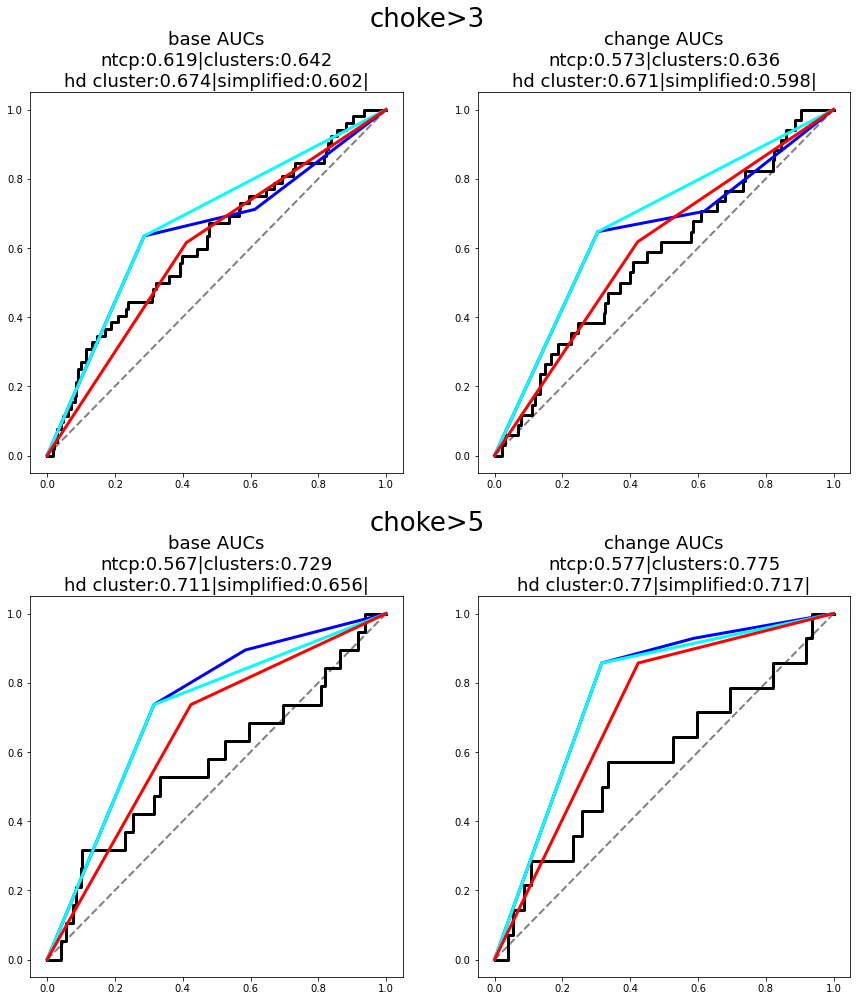

In [38]:
plot_roc_sets(choke_ct,thresholds=[3,5])

In [39]:
swallow_organs = [
   'IPC',
    'MPC',
    'SPC',
    'Supraglottic_Larynx',
    'Esophagus',
]
swallow_ct = ClusterTester(swallowdf,
                       swallow_organs,
                       symptoms=['swallow'],
                       n_clusters=3,
                       outcome_dates=[33],
                       default_confounders=[
                           'hpv',
                           'age_65',
                           'Larynx_limit',
                           'performance_1','performance_2',
                           't_severe','n_severe'
                       ],
                       cluster_features=['V35','V40','V45','V50','V55','V60','V65','V70'],
                      )
eval_ct(swallow_ct,thresholds=[5],delta_thresholds=[5])

lb 4
lb 8
lb 9
lb 9
V50_IPC>40.0, V60_Supraglottic_Larynx>46.0 
 roc_cluster:0.971 roc_outcome_3:0.57 roc_outcome_change_3:0.555 cluster_precision:[0.993 0.892] cluster_recall:[0.976 0.967] cluster_f1:[0.984 0.928] roc_outcome_5:0.638 roc_outcome_change_5:0.569 roc_outcome_7:0.647 roc_outcome_change_7:0.5 
 _________________ 
 V50_IPC>40.0, V60_MPC>13.0, V60_Supraglottic_Larynx>32.0 
 roc_cluster:0.969 roc_outcome_3:0.569 roc_outcome_change_3:0.554 cluster_precision:[0.993 0.879] cluster_recall:[0.972 0.967] cluster_f1:[0.983 0.921] roc_outcome_5:0.637 roc_outcome_change_5:0.567 roc_outcome_7:0.645 roc_outcome_change_7:0.5 
 _________________ 
 V50_IPC>40.0, V60_MPC>13.0 
 roc_cluster:0.963 roc_outcome_3:0.57 roc_outcome_change_3:0.56 cluster_precision:[0.993 0.829] cluster_recall:[0.958 0.967] cluster_f1:[0.975 0.892] roc_outcome_5:0.648 roc_outcome_change_5:0.589 roc_outcome_7:0.674 roc_outcome_change_7:0.6 
 _________________ 
 V50_IPC>40.0 
 roc_cluster:0.961 roc_outcome_3:0.557 ro

lrt_pval  \
threshold cluster    confounders                                                    
-5        -1         hpv,age_65,Larynx_limit,performance_1,performan...  0.001664   
          0          hpv,age_65,Larynx_limit,performance_1,performan...  0.013742   
          1          hpv,age_65,Larynx_limit,performance_1,performan...  0.000549   
          2          hpv,age_65,Larynx_limit,performance_1,performan...  0.013538   
          simplified hpv,age_65,Larynx_limit,performance_1,performan...  0.028042   
 5        -1         hpv,age_65,Larynx_limit,performance_1,performan...  0.000680   
          0          hpv,age_65,Larynx_limit,performance_1,performan...  0.004413   
          1          hpv,age_65,Larynx_limit,performance_1,performan...  0.000535   
          2          hpv,age_65,Larynx_limit,performance_1,performan...  0.001975   
          simplified hpv,age_65,Larynx_limit,performance_1,performan...  0.009516   

                                                                         odds_ratio  \
threshold cluster    confounders                                                      
-5        -1         hpv,age_65,Larynx_limit,performance_1,performan...         NaN   
          0          hpv,age_65,Larynx_limit,performance_1,performan...    0.327796   
          1          hpv,age_65,Larynx_limit,performance_1,performan...    0.306625   
          2          hpv,age_65,Larynx_limit,performance_1,performan...    4.726215   
          simplified hpv,age_65,Larynx_limit,performance_1,performan...    3.762168   
 5        -1         hpv,age_65,Larynx_limit,performance_1,performan...         NaN   
          0          hpv,age_65,Larynx_limit,performance_1,performan...    0.331965   
          1          hpv,age_65,Larynx_limit,performance_1,performan...    0.369029   
          2          hpv,age_65,Larynx_limit,performance_1,performan...    5.128869   
          simplified hpv,age_65,Larynx_limit,performance_1,performan...    3.624716   

                                                                          aic_diff  \
threshold cluster    confounders                                                     
-5        -1         hpv,age_65,Larynx_limit,performance_1,performan...  -8.797610   
          0          hpv,age_65,Larynx_limit,performance_1,performan...  -4.070929   
          1          hpv,age_65,Larynx_limit,performance_1,performan...  -9.940906   
          2          hpv,age_65,Larynx_limit,performance_1,performan...  -4.097394   
          simplified hpv,age_65,Larynx_limit,performance_1,performan...  -2.825488   
 5        -1         hpv,age_65,Larynx_limit,performance_1,performan... -10.585747   
          0          hpv,age_65,Larynx_limit,performance_1,performan...  -6.105730   
          1          hpv,age_65,Larynx_limit,performance_1,performan...  -9.990611   
          2          hpv,age_65,Larynx_limit,performance_1,performan...  -7.572893   
          simplified hpv,age_65,Larynx_limit,performance_1,performan...  -4.723354   

                                                                         bic_diff  
threshold cluster    confounders                                                   
-5        -1         hpv,age_65,Larynx_limit,performance_1,performan... -1.087466  
          0          hpv,age_65,Larynx_limit,performance_1,performan... -0.215857  
          1          hpv,age_65,Larynx_limit,performance_1,performan... -6.085834  
          2          hpv,age_65,Larynx_limit,performance_1,performan... -0.242322  
          simplified hpv,age_65,Larynx_limit,performance_1,performan...  1.029584  
 5        -1         hpv,age_65,Larynx_limit,performance_1,performan... -2.875603  
          0          hpv,age_65,Larynx_limit,performance_1,performan... -2.250658  
          1          hpv,age_65,Larynx_limit,performance_1,performan... -6.135540  
          2          hpv,age_65,Larynx_limit,performance_1,performan... -3.717821  
          simplified hpv,age_65,Larynx_limit,perfo

lb 5
lb 11
lb 15
lb 16
using choke ntcp
using choke ntcp
using choke ntcp
using choke ntcp


roc       mcc       dor  \
threshold outcome use_change name                                       
3         swallow False      clusters    0.595577  0.142258  0.291667   
                             hd cluster  0.557489  0.142258  0.291667   
                             ntcp        0.540386  0.043236  0.081289   
                             simplified  0.561596  0.115228  0.753725   
                  True       clusters    0.600035  0.101758  0.140260   
                             hd cluster  0.547201  0.101758  0.140260   
                             ntcp        0.513351 -0.026413  0.019190   
                             simplified  0.557996  0.094522  0.427083   
5         swallow False      clusters    0.630722  0.204101  0.231756   
                             hd cluster  0.613826  0.204101  0.231756   
                             ntcp        0.561271 -0.029581  0.000000   
                             simplified  0.567406  0.091373  0.280061   
                  True       clusters    0.606420  0.144985  0.111111   
                             hd cluster  0.600690  0.144985  0.111111   
                             ntcp        0.504450 -0.022422  0.000000   
                             simplified  0.574599  0.081206  0.178726   

                                         accuracy  precision    recall  \
threshold outcome use_change name                                        
3         swallow False      clusters    0.667622   0.466667  0.250000   
                             hd cluster  0.667622   0.466667  0.250000   
                             ntcp        0.656160   0.382353  0.116071   
                             simplified  0.564470   0.378049  0.553571   
                  True       clusters    0.722063   0.300000  0.246575   
                             hd cluster  0.722063   0.300000  0.246575   
                             ntcp        0.727794   0.176471  0.082192   
                             simplified  0.555874   0.250000  0.561644   
5         swallow False      clusters    0.793696   0.283333  0.369565   
                             hd cluster  0.793696   0.283333  0.369565   
                             ntcp        0.862464   0.000000  0.000000   
                             simplified  0.553009   0.164634  0.586957   
                  True       clusters    0.805158   0.166667  0.357143   
                             hd cluster  0.805158   0.166667  0.357143   
                             ntcp        0.914040   0.000000  0.000000   
                             simplified  0.547278   0.103659  0.607143   

                                               f1    f_half        f2  \
threshold outcome use_change name                                       
3         swallow False      clusters    0.325581  0.397727  0.275591   
                             hd cluster  0.325581  0.397727  0.275591   
                             ntcp        0.178082  0.262097  0.134855   
                             simplified  0.449275  0.403646  0.506536   
                  True       clusters    0.270677  0.287540  0.255682   
                             hd cluster  0.270677  0.287540  0.255682   
                             ntcp        0.112150  0.143541  0.092025   
                             simplified  0.345992  0.281207  0.449561   
5         swallow False      clusters    0.320755  0.297203  0.348361   
                             hd cluster  0.320755  0.297203  0.348361   
                             ntcp        0.000000       NaN       NaN   
                             simplified  0.257143  0.192308  0.387931   
                  True       clusters    0.227273  0.186567  0.290698   
                             hd cluster  0.227273  0.186567  0.290698   
                             ntcp        0.000000       NaN       NaN   
                             simplified  0.177083  0.124269  0.307971   

                                         delong_pval  
threshold outcome use_change

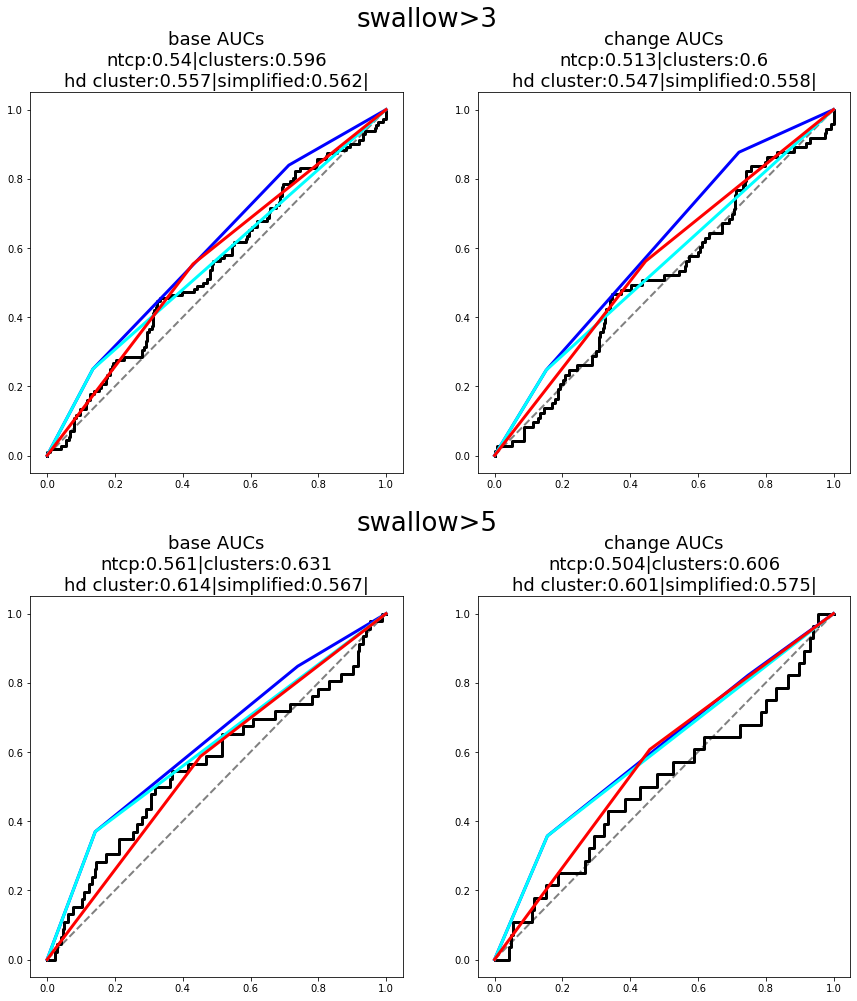

In [40]:
plot_roc_sets(swallow_ct,thresholds=[3,5])

In [41]:
show_dems(swallow_ct)

counts
0     86
1    203
2     60
Name: cluster, dtype: int64
--mimic--
65
_________________
_________________
is_male
             pval      tval overall_pval       False         True
cluster                                                          
0             1.0       0.0     0.155427   9 (10.5)%   77 (89.5)%
1        0.256373  1.288238     0.155427  24 (11.8)%  179 (88.2)%
2        0.096682  2.759444     0.155427    2 (3.3)%   58 (96.7)%
--mimic--
pval              0.065841
tval              3.383777
overall_pval      0.065841
False             2 (3.1)%
True            63 (96.9)%
Name: 1, dtype: object
_________________
_________________
t_stage
             pval       tval overall_pval         t0          t1          t2  \
cluster                                                                        
0        0.000596  23.686938     0.000005  9 (10.5)%  41 (47.7)%  25 (29.1)%   
1         0.64279   4.250708     0.000005  19 (9.4)%  59 (29.1)%  77 (37.9)%   
2        0.000013  

In [42]:
mucus_organs = [
    'Rt_Parotid_Gland','Lt_Parotid_Gland',
    'Rt_Submandibular_Gland','Lt_Submandibular_Gland',
]
mucus_ct = ClusterTester(mucus_df,
                       mucus_organs,
                       symptoms=['mucus'],
                       n_clusters=3,
                       outcome_dates=[33],
                       default_confounders=[
                           'hpv',
                           'age_65',
                           'Parotid_Gland_limit',
                           'performance_1','performance_2',
                           't_severe','n_severe'
                       ],
                       cluster_features=['V25','V30','V35','V40','V45','V50','V55','V60','V65'],
                      )
eval_ct(mucus_ct,thresholds=[5],delta_thresholds=[5])

lb 6
lb 16
lb 26
lb 31
V50_Rt_Submandibular_Gland>48.0, V45_Rt_Parotid_Gland>1.0 
 roc_cluster:0.953 roc_outcome_3:0.592 roc_outcome_change_3:0.572 cluster_precision:[0.916 0.988] cluster_recall:[0.988 0.918] cluster_f1:[0.95  0.952] roc_outcome_5:0.562 roc_outcome_change_5:0.576 roc_outcome_7:0.575 roc_outcome_change_7:0.6 
 _________________ 
 V50_Rt_Submandibular_Gland>48.0, V5_Rt_Parotid_Gland>41.0, V45_Rt_Parotid_Gland>1.0 
 roc_cluster:0.953 roc_outcome_3:0.592 roc_outcome_change_3:0.572 cluster_precision:[0.916 0.988] cluster_recall:[0.988 0.918] cluster_f1:[0.95  0.952] roc_outcome_5:0.562 roc_outcome_change_5:0.576 roc_outcome_7:0.575 roc_outcome_change_7:0.6 
 _________________ 
 V50_Rt_Submandibular_Gland>48.0, V55_Lt_Submandibular_Gland>29.0, V45_Rt_Parotid_Gland>1.0 
 roc_cluster:0.953 roc_outcome_3:0.592 roc_outcome_change_3:0.572 cluster_precision:[0.916 0.988] cluster_recall:[0.988 0.918] cluster_f1:[0.95  0.952] roc_outcome_5:0.562 roc_outcome_change_5:0.576 roc_outcom

lrt_pval  \
threshold cluster    confounders                                                    
-5        -1         hpv,age_65,Parotid_Gland_limit,performance_1,pe...  0.002359   
          0          hpv,age_65,Parotid_Gland_limit,performance_1,pe...  0.001500   
          1          hpv,age_65,Parotid_Gland_limit,performance_1,pe...  0.000901   
          2          hpv,age_65,Parotid_Gland_limit,performance_1,pe...  0.001287   
          simplified hpv,age_65,Parotid_Gland_limit,performance_1,pe...  0.032086   
 5        -1         hpv,age_65,Parotid_Gland_limit,performance_1,pe...  0.002531   
          0          hpv,age_65,Parotid_Gland_limit,performance_1,pe...  0.019372   
          1          hpv,age_65,Parotid_Gland_limit,performance_1,pe...  0.001864   
          2          hpv,age_65,Parotid_Gland_limit,performance_1,pe...  0.000790   
          simplified hpv,age_65,Parotid_Gland_limit,performance_1,pe...  0.009631   

                                                                         odds_ratio  \
threshold cluster    confounders                                                      
-5        -1         hpv,age_65,Parotid_Gland_limit,performance_1,pe...         NaN   
          0          hpv,age_65,Parotid_Gland_limit,performance_1,pe...    0.092844   
          1          hpv,age_65,Parotid_Gland_limit,performance_1,pe...    0.282007   
          2          hpv,age_65,Parotid_Gland_limit,performance_1,pe...    3.382138   
          simplified hpv,age_65,Parotid_Gland_limit,performance_1,pe...    2.171019   
 5        -1         hpv,age_65,Parotid_Gland_limit,performance_1,pe...         NaN   
          0          hpv,age_65,Parotid_Gland_limit,performance_1,pe...    0.291415   
          1          hpv,age_65,Parotid_Gland_limit,performance_1,pe...    0.351047   
          2          hpv,age_65,Parotid_Gland_limit,performance_1,pe...    3.181614   
          simplified hpv,age_65,Parotid_Gland_limit,performance_1,pe...    2.373055   

                                                                         aic_diff  \
threshold cluster    confounders                                                    
-5        -1         hpv,age_65,Parotid_Gland_limit,performance_1,pe... -8.098777   
          0          hpv,age_65,Parotid_Gland_limit,performance_1,pe... -8.078274   
          1          hpv,age_65,Parotid_Gland_limit,performance_1,pe... -9.020146   
          2          hpv,age_65,Parotid_Gland_limit,performance_1,pe... -8.360765   
          simplified hpv,age_65,Parotid_Gland_limit,performance_1,pe... -2.593905   
 5        -1         hpv,age_65,Parotid_Gland_limit,performance_1,pe... -7.957951   
          0          hpv,age_65,Parotid_Gland_limit,performance_1,pe... -3.467634   
          1          hpv,age_65,Parotid_Gland_limit,performance_1,pe... -7.679318   
          2          hpv,age_65,Parotid_Gland_limit,performance_1,pe... -9.265353   
          simplified hpv,age_65,Parotid_Gland_limit,performance_1,pe... -4.701913   

                                                                         bic_diff  
threshold cluster    confounders                                                   
-5        -1         hpv,age_65,Parotid_Gland_limit,performance_1,pe... -0.388633  
          0          hpv,age_65,Parotid_Gland_limit,performance_1,pe... -4.223202  
          1          hpv,age_65,Parotid_Gland_limit,performance_1,pe... -5.165074  
          2          hpv,age_65,Parotid_Gland_limit,performance_1,pe... -4.505693  
          simplified hpv,age_65,Parotid_Gland_limit,performance_1,pe...  1.261167  
 5        -1         hpv,age_65,Parotid_Gland_limit,performance_1,pe... -0.247807  
          0          hpv,age_65,Parotid_Gland_limit,performance_1,pe...  0.387438  
          1          hpv,age_65,Parotid_Gland_limit,performance_1,pe... -3.824246  
          2          hpv,age_65,Parotid_Gland_limit,performance_1,pe... -5.410281  
          simplified hpv,age_65,Parotid_Gland_limit,performanc

lb 5
lb 11
lb 15
lb 16


roc       mcc       dor  \
threshold outcome use_change name                                       
3         mucus   False      clusters    0.589938  0.190104  1.449710   
                             hd cluster  0.599909  0.190104  1.449710   
                             ntcp        0.556623  0.067696  0.170425   
                             simplified  0.597143  0.185043  1.130523   
                  True       clusters    0.621253  0.208551  1.210081   
                             hd cluster  0.620811  0.208551  1.210081   
                             ntcp        0.589663  0.099403  0.149668   
                             simplified  0.608630  0.187728  0.843750   
5         mucus   False      clusters    0.596264  0.163805  0.694444   
                             hd cluster  0.611409  0.163805  0.694444   
                             ntcp        0.491955 -0.040708  0.000000   
                             simplified  0.617047  0.172281  0.576421   
                  True       clusters    0.627930  0.185084  0.748538   
                             hd cluster  0.643491  0.185084  0.748538   
                             ntcp        0.497466 -0.033973  0.000000   
                             simplified  0.637749  0.177873  0.526942   

                                         accuracy  precision    recall  \
threshold outcome use_change name                                        
3         mucus   False      clusters    0.581662   0.429348  0.658333   
                             hd cluster  0.581662   0.429348  0.658333   
                             ntcp        0.630372   0.418182  0.191667   
                             simplified  0.598854   0.438272  0.591667   
                  True       clusters    0.575931   0.331522  0.709302   
                             hd cluster  0.575931   0.331522  0.709302   
                             ntcp        0.704871   0.345455  0.220930   
                             simplified  0.598854   0.333333  0.627907   
5         mucus   False      clusters    0.541547   0.217391  0.714286   
                             hd cluster  0.541547   0.217391  0.714286   
                             ntcp        0.830946   0.000000  0.000000   
                             simplified  0.587393   0.228395  0.660714   
                  True       clusters    0.538682   0.173913  0.780488   
                             hd cluster  0.538682   0.173913  0.780488   
                             ntcp        0.873926   0.000000  0.000000   
                             simplified  0.584527   0.179012  0.707317   

                                               f1    f_half        f2  \
threshold outcome use_change name                                       
3         mucus   False      clusters    0.519737  0.461449  0.594880   
                             hd cluster  0.519737  0.461449  0.594880   
                             ntcp        0.262857  0.338235  0.214953   
                             simplified  0.503546  0.462240  0.552960   
                  True       clusters    0.451852  0.371046  0.577652   
                             hd cluster  0.451852  0.371046  0.577652   
                             ntcp        0.269504  0.310458  0.238095   
                             simplified  0.435484  0.367847  0.533597   
5         mucus   False      clusters    0.333333  0.252525  0.490196   
                             hd cluster  0.333333  0.252525  0.490196   
                             ntcp        0.000000       NaN       NaN   
                             simplified  0.339450  0.262784  0.479275   
                  True       clusters    0.284444  0.205920  0.459770   
                             hd cluster  0.284444  0.205920  0.459770   
                             ntcp        0.000000       NaN       NaN   
                             simplified  0.285714  0.210450  0.444785   

                                         delong_pval  
threshold outcome use_change

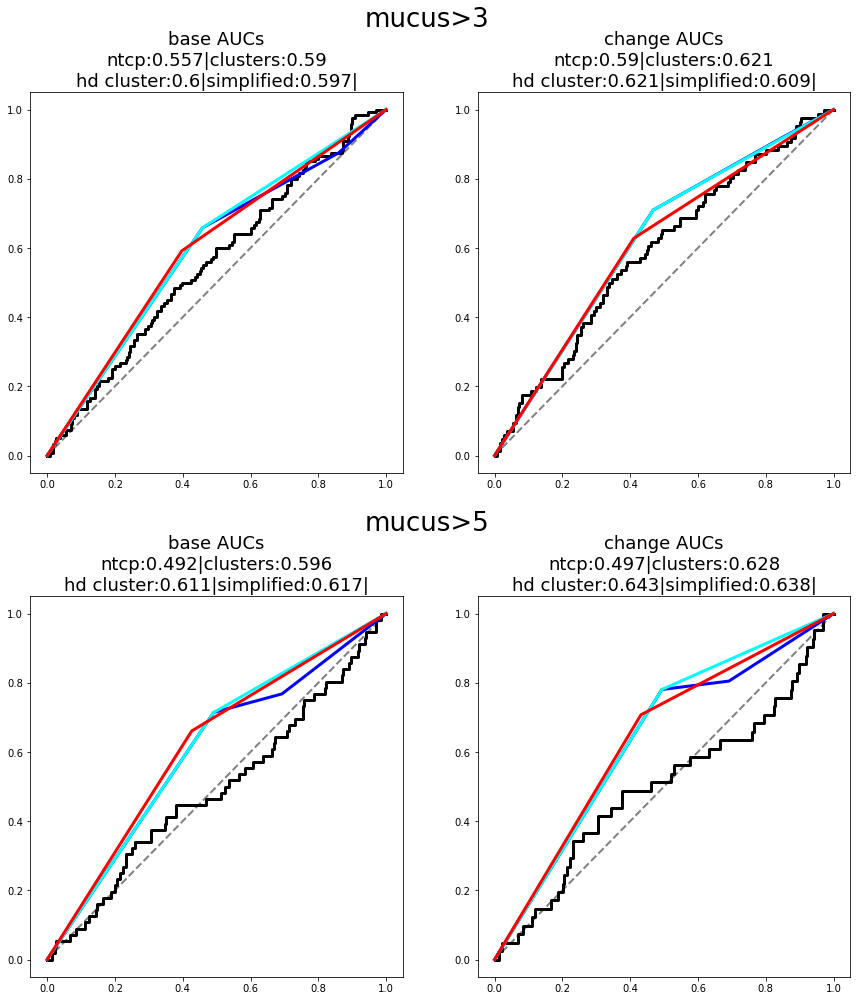

In [43]:
plot_roc_sets(mucus_ct,thresholds=[3,5])

In [44]:
show_dems(mucus_ct)

counts
0     34
1    131
2    184
Name: cluster, dtype: int64
--mimic--
171
_________________
_________________
is_male
             pval      tval overall_pval       False         True
cluster                                                          
0        0.584573    0.2989     0.563233    2 (5.9)%   32 (94.1)%
1        0.814497   0.05505     0.563233   12 (9.2)%  119 (90.8)%
2        0.464936  0.533987     0.563233  21 (11.4)%  163 (88.6)%
--mimic--
pval               0.630089
tval                0.23194
overall_pval       0.630089
False            19 (11.1)%
True            152 (88.9)%
Name: 1, dtype: object
_________________
_________________
t_stage
             pval       tval overall_pval         t0          t1          t2  \
cluster                                                                        
0        0.048979  12.647987     0.000021  4 (11.8)%  11 (32.4)%   9 (26.5)%   
1        0.000067  28.780971     0.000021   9 (6.9)%  54 (41.2)%  52 (39.7)%   
2        0.00

In [45]:
mucusitis_ct = ClusterTester(sddf3,
                       [
                           'Hard_Palate',
                           'Soft_Palate',
                           'SPC',
                           'Genioglossus_M',
                           "Supraglottic_Larynx"
                       ],
                       symptoms=['mucositis'],
                       n_clusters=4,
                       outcome_dates=[33],
                       default_confounders=[
                           'hpv',
                           'age_65',
                           'Parotid_Gland_limit',
                           'performance_1','performance_2',
                           't_severe','n_severe'
                       ],
                       cluster_features=['V40','V45','V50','V55','V60'],
                      )
eval_ct(mucusitis_ct,thresholds=[5],delta_thresholds=[5])

lb 1
V50_Hard_Palate>28.0 
 roc_cluster:0.997 roc_outcome_3:0.527 roc_outcome_change_3:0.539 cluster_precision:[1.  0.8] cluster_recall:[0.994 1.   ] cluster_f1:[0.997 0.889] roc_outcome_5:0.51 roc_outcome_change_5:0.518 roc_outcome_7:0.542 roc_outcome_change_7:0.5 
 _________________ 
 


lrt_pval  \
threshold cluster    confounders                                                    
-5        -1         hpv,age_65,Parotid_Gland_limit,performance_1,pe...  0.503742   
          0          hpv,age_65,Parotid_Gland_limit,performance_1,pe...  0.000409   
          1          hpv,age_65,Parotid_Gland_limit,performance_1,pe...  0.241943   
          2          hpv,age_65,Parotid_Gland_limit,performance_1,pe...  0.135445   
          3          hpv,age_65,Parotid_Gland_limit,performance_1,pe...  0.932119   
          simplified hpv,age_65,Parotid_Gland_limit,performance_1,pe...  0.652160   
 5        -1         hpv,age_65,Parotid_Gland_limit,performance_1,pe...  0.055453   
          0          hpv,age_65,Parotid_Gland_limit,performance_1,pe...  0.014548   
          1          hpv,age_65,Parotid_Gland_limit,performance_1,pe...  0.026117   
          2          hpv,age_65,Parotid_Gland_limit,performance_1,pe...  0.008612   
          3          hpv,age_65,Parotid_Gland_limit,performance_1,pe...  0.646799   
          simplified hpv,age_65,Parotid_Gland_limit,performance_1,pe...  0.409790   

                                                                         odds_ratio  \
threshold cluster    confounders                                                      
-5        -1         hpv,age_65,Parotid_Gland_limit,performance_1,pe...         NaN   
          0          hpv,age_65,Parotid_Gland_limit,performance_1,pe...    0.114033   
          1          hpv,age_65,Parotid_Gland_limit,performance_1,pe...    0.588607   
          2          hpv,age_65,Parotid_Gland_limit,performance_1,pe...    2.011822   
          3          hpv,age_65,Parotid_Gland_limit,performance_1,pe...    0.905581   
          simplified hpv,age_65,Parotid_Gland_limit,performance_1,pe...    0.610634   
 5        -1         hpv,age_65,Parotid_Gland_limit,performance_1,pe...         NaN   
          0          hpv,age_65,Parotid_Gland_limit,performance_1,pe...    0.311008   
          1          hpv,age_65,Parotid_Gland_limit,performance_1,pe...    0.390300   
          2          hpv,age_65,Parotid_Gland_limit,performance_1,pe...    3.052588   
          3          hpv,age_65,Parotid_Gland_limit,performance_1,pe...    0.585901   
          simplified hpv,age_65,Parotid_Gland_limit,performance_1,pe...    0.411673   

                                                                          aic_diff  \
threshold cluster    confounders                                                     
-5        -1         hpv,age_65,Parotid_Gland_limit,performance_1,pe...   3.653875   
          0          hpv,age_65,Parotid_Gland_limit,performance_1,pe... -10.492528   
          1          hpv,age_65,Parotid_Gland_limit,performance_1,pe...   0.630764   
          2          hpv,age_65,Parotid_Gland_limit,performance_1,pe...  -0.228963   
          3          hpv,age_65,Parotid_Gland_limit,performance_1,pe...   1.992744   
          simplified hpv,age_65,Parotid_Gland_limit,performance_1,pe...   1.796812   
 5        -1         hpv,age_65,Parotid_Gland_limit,performance_1,pe...  -1.583449   
          0          hpv,age_65,Parotid_Gland_limit,performance_1,pe...  -3.970431   
          1          hpv,age_65,Parotid_Gland_limit,performance_1,pe...  -2.948243   
          2          hpv,age_65,Parotid_Gland_limit,performance_1,pe...  -4.901513   
          3          hpv,age_65,Parotid_Gland_limit,performance_1,pe...   1.790040   
          simplified hpv,age_65,Parotid_Gland_limit,performance_1,pe...   1.320590   

                                                                          bic_diff  
threshold cluster    confounders                                                    
-5        -1         hpv,age_65,Parotid_Gland_limit,performance_1,pe...  15.219091  
          0          hpv,age_65,Parotid_Gland_limit,performance_1,pe...  -6.637457  
          1          hpv,age_65,Parotid_Gland_limit,performance_1,pe...   4.485835  
          2          hpv,age_65,P

lb 3
lb 4
lb 4


roc       mcc       dor  \
threshold outcome   use_change name                                       
3         mucositis False      clusters    0.577865  0.176371  0.300000   
                               hd cluster  0.522944  0.105606  0.040000   
                               ntcp        0.642027  0.087953  0.036364   
                               simplified  0.595377  0.151291  0.210084   
                    True       clusters    0.555866  0.139240  0.202241   
                               hd cluster  0.529409  0.125200  0.048649   
                               ntcp        0.622492  0.109802  0.044444   
                               simplified  0.597613  0.143214  0.176975   
5         mucositis False      clusters    0.600578  0.166113  0.231942   
                               hd cluster  0.491783 -0.014839  0.008929   
                               ntcp        0.600020 -0.033619  0.000000   
                               simplified  0.609454  0.143415  0.155803   
                    True       clusters    0.563083  0.125924  0.139265   
                               hd cluster  0.486730 -0.020901  0.005148   
                               ntcp        0.601227 -0.028601  0.000000   
                               simplified  0.621032  0.138306  0.130952   

                                           accuracy  precision    recall  \
threshold outcome   use_change name                                        
3         mucositis False      clusters    0.702006   0.230769  0.500000   
                               hd cluster  0.856734   0.375000  0.062500   
                               ntcp        0.845272   0.285714  0.083333   
                               simplified  0.724928   0.227273  0.416667   
                    True       clusters    0.696275   0.182692  0.475000   
                               hd cluster  0.879656   0.375000  0.075000   
                               ntcp        0.868195   0.285714  0.100000   
                               simplified  0.730659   0.193182  0.425000   
5         mucositis False      clusters    0.704871   0.160377  0.548387   
                               hd cluster  0.816619   0.076923  0.096774   
                               ntcp        0.899713   0.000000  0.000000   
                               simplified  0.739255   0.159091  0.451613   
                    True       clusters    0.699140   0.113208  0.521739   
                               hd cluster  0.833811   0.051282  0.086957   
                               ntcp        0.922636   0.000000  0.000000   
                               simplified  0.744986   0.125000  0.478261   

                                                 f1    f_half        f2  \
threshold outcome   use_change name                                       
3         mucositis False      clusters    0.315789  0.258621  0.405405   
                               hd cluster  0.107143  0.187500  0.075000   
                               ntcp        0.129032  0.192308  0.097087   
                               simplified  0.294118  0.250000  0.357143   
                    True       clusters    0.263889  0.208333  0.359848   
                               hd cluster  0.125000  0.208333  0.089286   
                               ntcp        0.148148  0.208333  0.114943   
                               simplified  0.265625  0.216837  0.342742   
5         mucositis False      clusters    0.248175  0.186813  0.369565   
                               hd cluster  0.085714  0.080214  0.092025   
                               ntcp        0.000000       NaN       NaN   
                               simplified  0.235294  0.182768  0.330189   
                    True       clusters    0.186047  0.134228  0.303030   
                               hd cluster  0.064516  0.055866  0.076336   
                               ntcp        0.000000       NaN       NaN   
                               simplified  0.198198  

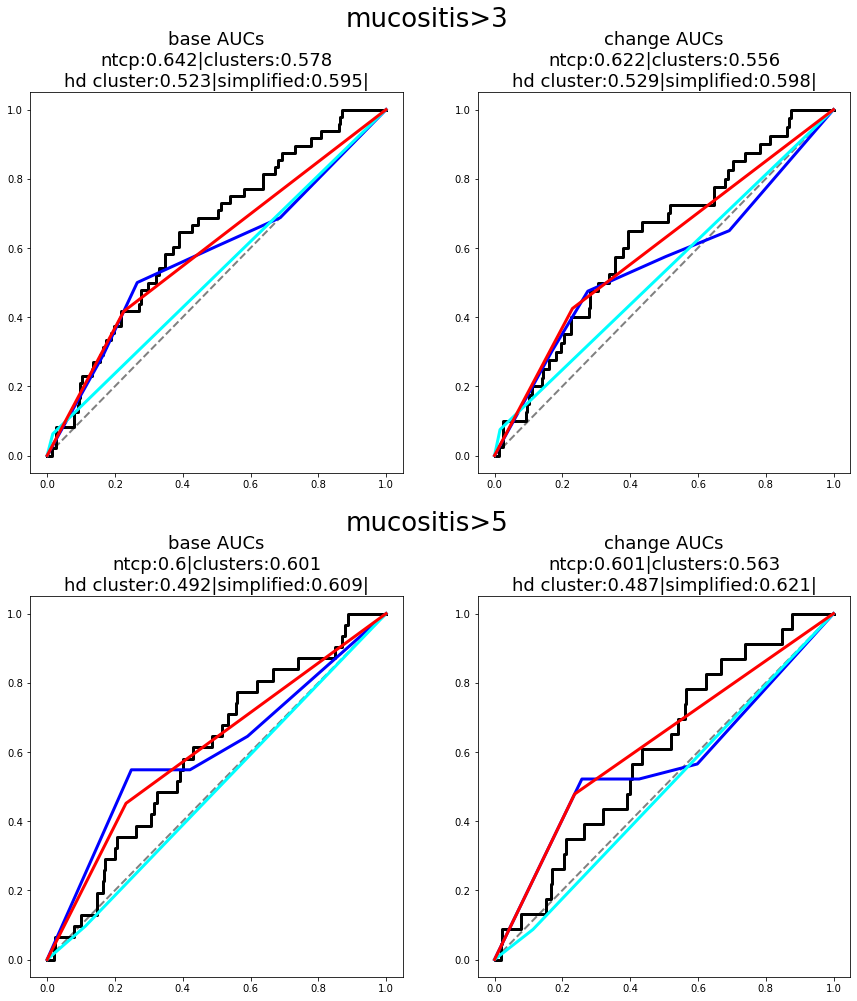

In [46]:
plot_roc_sets(mucusitis_ct,thresholds=[3,5])

In [47]:
voice_ct = ClusterTester(sddf3,
                       [
                           'Tongue',
                           'IPC',
#                            'MPC',
#                            'SPC',
                           'Rt_Submandibular_Gland',
                           'Larynx',
                           'Supraglottic_Larynx'
                       ],
                       symptoms=['voice'],
                       n_clusters=3,
                       outcome_dates=[33],
                       default_confounders=[
                           'hpv',
                           'age_65',
                           'Larynx_limit',
                           'performance_1','performance_2',
                           't_severe','n_severe',
                           'BOT','Tonsil',
                       ],
                       cluster_features=['V45','V50','V55','V60','V65'], 
#                        cluster_features=['V30','V35','V40','V45','V50','V55','V60','V65'],
                      )
eval_ct(voice_ct,thresholds=[5],delta_thresholds=[5])

lb 4
lb 7
lb 8
lb 8
V55_IPC>34.0, max_dose_Larynx>66.0 
 roc_cluster:0.971 roc_outcome_3:0.669 roc_outcome_change_3:0.592 cluster_precision:[0.997 0.8  ] cluster_recall:[0.964 0.978] cluster_f1:[0.98 0.88] roc_outcome_5:0.72 roc_outcome_change_5:0.673 roc_outcome_7:0.924 roc_outcome_change_7:0.9 
 _________________ 
 V55_IPC>34.0, mean_dose_Supraglottic_Larynx>57.0 
 roc_cluster:0.961 roc_outcome_3:0.672 roc_outcome_change_3:0.595 cluster_precision:[0.993 0.811] cluster_recall:[0.967 0.956] cluster_f1:[0.98  0.878] roc_outcome_5:0.723 roc_outcome_change_5:0.676 roc_outcome_7:0.927 roc_outcome_change_7:0.9 
 _________________ 
 V55_IPC>34.0 
 roc_cluster:0.964 roc_outcome_3:0.699 roc_outcome_change_3:0.621 cluster_precision:[0.997 0.746] cluster_recall:[0.951 0.978] cluster_f1:[0.973 0.846] roc_outcome_5:0.715 roc_outcome_change_5:0.667 roc_outcome_7:0.918 roc_outcome_change_7:0.9 
 _________________ 
 V55_IPC>34.0 
 roc_cluster:0.964 roc_outcome_3:0.699 roc_outcome_change_3:0.621 clust

lrt_pval  \
threshold cluster    confounders                                                    
-5        -1         hpv,age_65,Larynx_limit,performance_1,performan...  0.046325   
          0          hpv,age_65,Larynx_limit,performance_1,performan...  0.061765   
          1          hpv,age_65,Larynx_limit,performance_1,performan...  0.031938   
          2          hpv,age_65,Larynx_limit,performance_1,performan...  0.976313   
          simplified hpv,age_65,Larynx_limit,performance_1,performan...  0.409276   
 5        -1         hpv,age_65,Larynx_limit,performance_1,performan...  0.003659   
          0          hpv,age_65,Larynx_limit,performance_1,performan...  0.034210   
          1          hpv,age_65,Larynx_limit,performance_1,performan...  0.001500   
          2          hpv,age_65,Larynx_limit,performance_1,performan...  0.009127   
          simplified hpv,age_65,Larynx_limit,performance_1,performan...  0.000302   

                                                                         odds_ratio  \
threshold cluster    confounders                                                      
-5        -1         hpv,age_65,Larynx_limit,performance_1,performan...         NaN   
          0          hpv,age_65,Larynx_limit,performance_1,performan...    0.266475   
          1          hpv,age_65,Larynx_limit,performance_1,performan...    0.209931   
          2          hpv,age_65,Larynx_limit,performance_1,performan...    0.959648   
          simplified hpv,age_65,Larynx_limit,performance_1,performan...    2.559454   
 5        -1         hpv,age_65,Larynx_limit,performance_1,performan...         NaN   
          0          hpv,age_65,Larynx_limit,performance_1,performan...    0.298009   
          1          hpv,age_65,Larynx_limit,performance_1,performan...    0.161351   
          2          hpv,age_65,Larynx_limit,performance_1,performan...    8.987250   
          simplified hpv,age_65,Larynx_limit,performance_1,performan...   19.749075   

                                                                          aic_diff  \
threshold cluster    confounders                                                     
-5        -1         hpv,age_65,Larynx_limit,performance_1,performan...  -2.144164   
          0          hpv,age_65,Larynx_limit,performance_1,performan...  -1.489336   
          1          hpv,age_65,Larynx_limit,performance_1,performan...  -2.601827   
          2          hpv,age_65,Larynx_limit,performance_1,performan...   1.999118   
          simplified hpv,age_65,Larynx_limit,performance_1,performan...   1.319098   
 5        -1         hpv,age_65,Larynx_limit,performance_1,performan...  -7.221089   
          0          hpv,age_65,Larynx_limit,performance_1,performan...  -2.484160   
          1          hpv,age_65,Larynx_limit,performance_1,performan...  -8.078362   
          2          hpv,age_65,Larynx_limit,performance_1,performan...  -4.797879   
          simplified hpv,age_65,Larynx_limit,performance_1,performan... -11.059422   

                                                                         bic_diff  
threshold cluster    confounders                                                   
-5        -1         hpv,age_65,Larynx_limit,performance_1,performan...  5.565980  
          0          hpv,age_65,Larynx_limit,performance_1,performan...  2.365736  
          1          hpv,age_65,Larynx_limit,performance_1,performan...  1.253245  
          2          hpv,age_65,Larynx_limit,performance_1,performan...  5.854190  
          simplified hpv,age_65,Larynx_limit,performance_1,performan...  5.174169  
 5        -1         hpv,age_65,Larynx_limit,performance_1,performan...  0.489055  
          0          hpv,age_65,Larynx_limit,performance_1,performan...  1.370912  
          1          hpv,age_65,Larynx_limit,performance_1,performan... -4.223290  
          2          hpv,age_65,Larynx_limit,performance_1,performan... -0.942807  
          simplified hpv,age_65,Larynx_limit,perfo

lb 6
lb 16
lb 26
lb 31
using voice ntcp
using voice ntcp
using voice ntcp
using voice ntcp


roc       mcc       dor  \
threshold outcome use_change name                                       
3         voice   False      clusters    0.596263  0.155489  0.138980   
                             hd cluster  0.573760  0.155489  0.138980   
                             ntcp        0.635544 -0.001326  0.003333   
                             simplified  0.564778  0.092231  0.272696   
                  True       clusters    0.574650  0.075428  0.047758   
                             hd cluster  0.542624  0.075428  0.047758   
                             ntcp        0.588049 -0.047002  0.000000   
                             simplified  0.534127  0.040790  0.125000   
5         voice   False      clusters    0.719936  0.226344  0.184211   
                             hd cluster  0.693284  0.226344  0.184211   
                             ntcp        0.555011 -0.019035  0.000000   
                             simplified  0.606503  0.084237  0.112500   
                  True       clusters    0.573129  0.014889  0.004545   
                             hd cluster  0.519193  0.014889  0.004545   
                             ntcp        0.520408 -0.012315  0.000000   
                             simplified  0.446550 -0.028004  0.006623   

                                         accuracy  precision    recall  \
threshold outcome use_change name                                        
3         voice   False      clusters    0.799427   0.288889  0.254902   
                             hd cluster  0.799427   0.288889  0.254902   
                             ntcp        0.839542   0.142857  0.019608   
                             simplified  0.575931   0.183007  0.549020   
                  True       clusters    0.813754   0.155556  0.205882   
                             hd cluster  0.813754   0.155556  0.205882   
                             ntcp        0.882521   0.000000  0.000000   
                             simplified  0.561605   0.111111  0.500000   
5         voice   False      clusters    0.871060   0.155556  0.500000   
                             hd cluster  0.871060   0.155556  0.500000   
                             ntcp        0.951289   0.000000  0.000000   
                             simplified  0.573066   0.058824  0.642857   
                  True       clusters    0.859599   0.022222  0.166667   
                             hd cluster  0.859599   0.022222  0.166667   
                             ntcp        0.974212   0.000000  0.000000   
                             simplified  0.555874   0.013072  0.333333   

                                               f1    f_half        f2  \
threshold outcome use_change name                                       
3         voice   False      clusters    0.270833  0.281385  0.261044   
                             hd cluster  0.270833  0.281385  0.261044   
                             ntcp        0.034483  0.063291  0.023697   
                             simplified  0.274510  0.211161  0.392157   
                  True       clusters    0.177215  0.163551  0.193370   
                             hd cluster  0.177215  0.163551  0.193370   
                             ntcp        0.000000       NaN       NaN   
                             simplified  0.181818  0.131579  0.294118   
5         voice   False      clusters    0.237288  0.180412  0.346535   
                             hd cluster  0.237288  0.180412  0.346535   
                             ntcp        0.000000       NaN       NaN   
                             simplified  0.107784  0.071885  0.215311   
                  True       clusters    0.039216  0.026882  0.072464   
                             hd cluster  0.039216  0.026882  0.072464   
                             ntcp        0.000000       NaN       NaN   
                             simplified  0.025157  0.016181  0.056497   

                                         delong_pval  
threshold outcome use_change

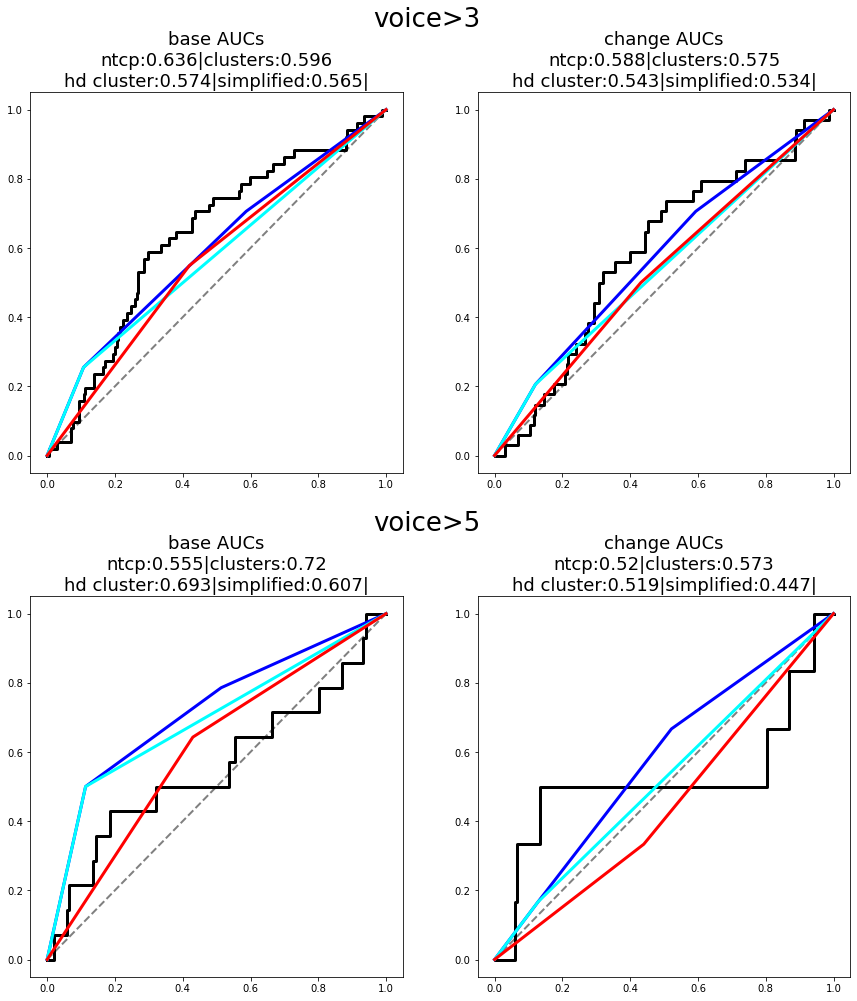

In [48]:
plot_roc_sets(voice_ct,thresholds=[3,5])

In [49]:
show_dems(voice_ct)

counts
0    138
1    166
2     45
Name: cluster, dtype: int64
--mimic--
55
_________________
_________________
is_male
             pval      tval overall_pval       False         True
cluster                                                          
0        0.809776  0.057944     0.409532  15 (10.9)%  123 (89.1)%
1        0.760996  0.092521     0.409532  18 (10.8)%  148 (89.2)%
2        0.284471  1.145603     0.409532    2 (4.4)%   43 (95.6)%
--mimic--
pval              0.140223
tval              2.175514
overall_pval      0.140223
False             2 (3.6)%
True            53 (96.4)%
Name: 1, dtype: object
_________________
_________________
t_stage
             pval       tval overall_pval          t0          t1          t2  \
cluster                                                                         
0        0.000301  25.293154     0.000001  16 (11.6)%  56 (40.6)%  43 (31.2)%   
1        0.327594   6.927607     0.000001   13 (7.8)%  48 (28.9)%  65 (39.2)%   
2        0.0000

In [ ]:
 def get_demographic_breakdown(self,
                                  cat_cols = None, 
                                  cont_cols = None,
                                  include_outcome=True,
                                  use_mimic=False,
                                 ):
        df = self.get_cluster_df(use_mimic=use_mimic)
        df.n_stage = df.n_stage.apply(lambda x: 'n2b' if x == 'n2' else x)
        clust_col = 'dose_clusters'
        if cat_cols is None:
            cat_cols = [
                'is_male','t_stage','n_stage','hpv',
                'performance_score',
                'ic','os','subsite','BOT','Tonsil',
                'Parotid_Gland_limit','IPC_limit','MPC_limit','SPC_limit',
                'previously_treated',
                'ic_prior_to_enrollment',
                'rt_prior_to_enrollment',
                'concurrent_prior_to_enrollment',
                'sx_prior_to_enrollment',
                'sx_prior_to_enrollment',
                'Technique',
                'sxprimary',
                'surgery',
                'dose_70','rt_dose','rt_fraction',
            ]
        if cont_cols is None:
            cont_cols = [
                'age',
                'followup_days',
                'rt_dose',
                'rt_fraction',
            ] + [c for c in df.columns if 'total_' in c]
        if include_outcome:
            outcome_name = '-'.join(self.symptoms)
            for thold in [3,5,7]:
                cname = outcome_name+'>'+str(thold)
                df[cname] = self.get_outcome(threshold=thold)
                cat_cols.append(cname)
        results = {'counts': pd.Series({c: d.shape[0] for c,d in df.groupby('dose_clusters')},name='cluster')}
        for col in cat_cols:
            if np.issubdtype(df[col].dtype,np.number):
                catdf = df.fillna(-1,downcast='infer')
            else:
                catdf = df.fillna('unknown').astype(str)
#             catdf = df[~df[col].isnull()]
            entrys = {}
            vchi2 = Metrics.vector_chi2(catdf[clust_col],catdf[col])
            for clust, subdf in catdf.groupby(clust_col):
                subchi2 = Metrics.vector_chi2(catdf.dose_clusters.apply(lambda x: x == clust), catdf[col])
                clust_entry = {'pval': subchi2[1],'tval':subchi2[0],'overall_pval':vchi2[1]}
                csize = subdf.shape[0]
                for vName, subsubdf in subdf.groupby(col):
                    count = subsubdf.shape[0]
                    clust_entry[vName] = str(count) + ' (' + str(np.round(count*100/csize,1)) + ')%'
                entrys[clust] = clust_entry
            edf = pd.DataFrame(entrys).T
            edf.index.name = 'cluster'
            results[col] = edf
        cont_results = {}
        def get_dist(vals):
            vals = vals.astype(float)
            [q5,median,q95] = vals.quantile([.05,.5,.95])
            mean = vals.mean()
            std = vals.std()
            ce = {
                'mean': mean,
                'std': std,
                'q5': q5,
                'median': median,
                'q95': q95,
            }
            return ce
        
        for col in cont_cols:
            tempdf = df[~df[col].isnull()]
            tempdf = df[df[col] > 0]
            combined_entry = get_dist(tempdf[col])
            tempchi2 = Metrics.vector_chi2(tempdf.dose_clusters, tempdf[col])
            combined_entry['tval'] = tempchi2[0]
            combined_entry['pval'] = tempchi2[1]
            entrys = {'total': combined_entry}
            for clust, subdf in tempdf.groupby(clust_col):
                clust_entry = get_dist(subdf[col])
                tempchi2 = Metrics.vector_chi2(tempdf.dose_clusters.apply(lambda x: x == clust), tempdf[col])
                clust_entry['tval'] = tempchi2[0]
                clust_entry['pval'] = tempchi2[1]
                entrys[clust] = clust_entry
            edf = pd.DataFrame(entrys).T
            edf.index.name = 'cluster'
            results[col] = edf
        return results

In [ ]:
# mucus_organs = [
#     'Hard_Palate',
#     "Soft_Palate",
#     'Tongue',
#     'Lt_Submandibular_Gland',
#     'Rt_Submandibular_Gland',
#     'Lt_Parotid_Gland',
#     'Rt_Parotid_Gland'
# ]
# mucus_ct = ClusterTester(sddf2,
#                        mucus_organs,
#                        symptoms=['mucositis'],
#                        n_clusters=3,
#                        default_confounders= [
#                            'hpv',
#                            'age_65',
#                            'performance_1','performance_2',
#                            't_severe','n_severe'],
#                        cluster_features=['V40','V45','V50','V55','V60'],
#                       )
# eval_ct(mucus_ct,thresholds=[0,2,3,4,5],delta_thresholds=[0,2,3,4,5])

# voice_organs = [
# #     'IPC',
# #     'Supraglottic_Larynx',
#     "Larynx",
#     'Tongue',
# #     'Genioglossus_M',
# #     'Hard_Palate',
# ]
# voice_ct = ClusterTester(sddf2,
#                        voice_organs,
#                        symptoms=['voice'],
#                        n_clusters=3,
#                        default_confounders= [
#                            'hpv',
#                            'age_65',
#                            'performance_1','performance_2',
#                            't_severe','n_severe'],
#                        cluster_features=['V50','V55','V60','V65','V70'],
#                       )
# eval_ct(voice_ct,thresholds=[0,2,3,4,5],delta_thresholds=[0,2,3,4,5])

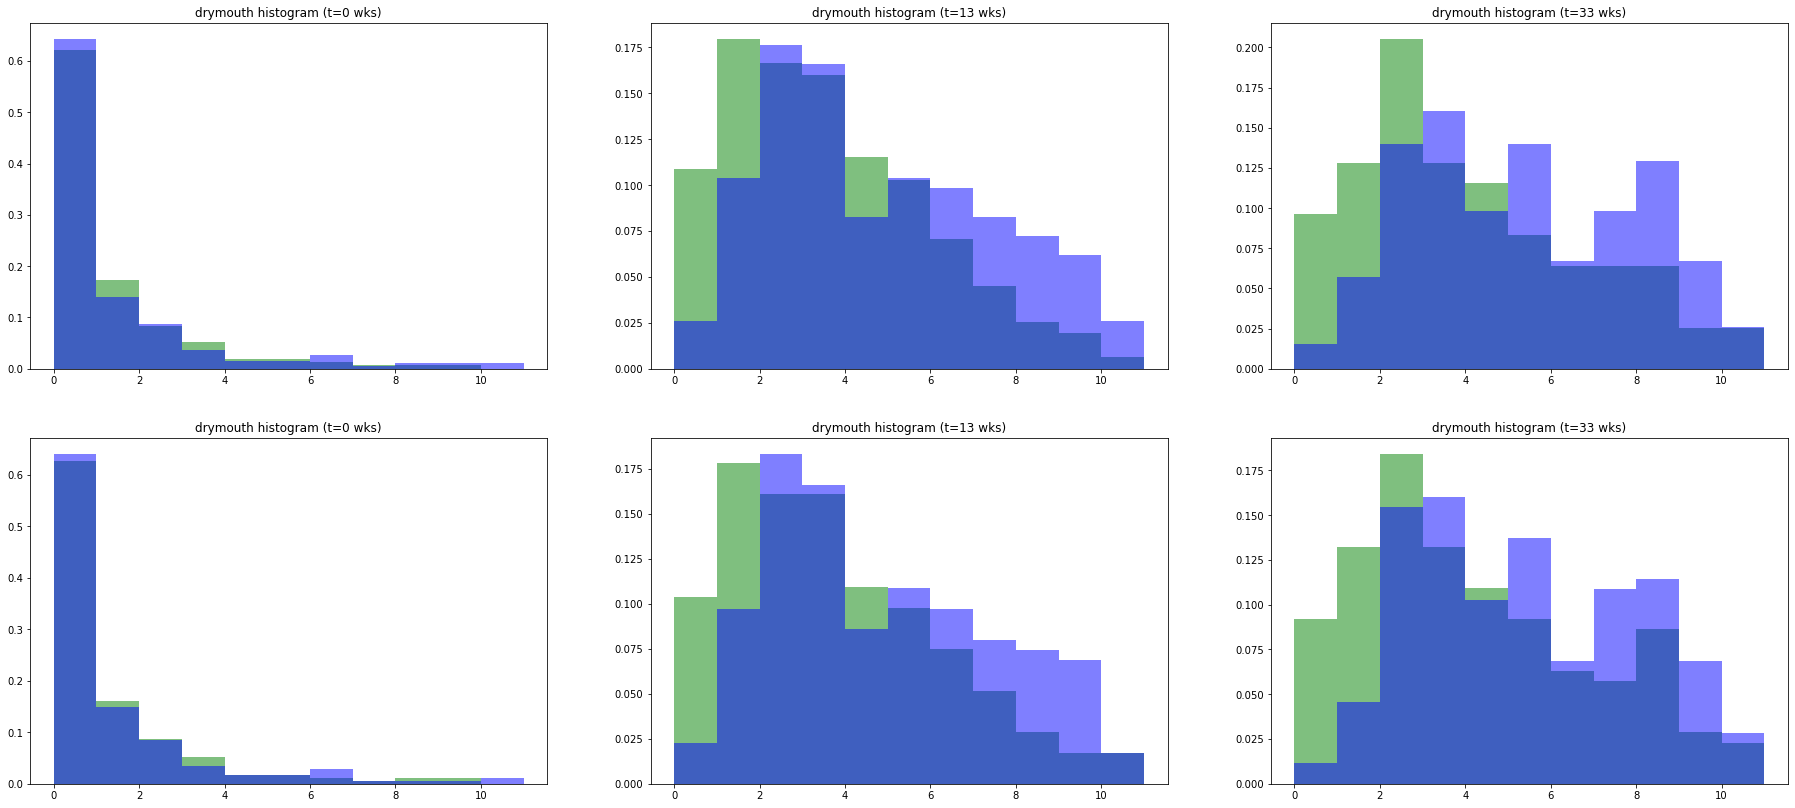

In [50]:
def symptom_histogram(ct,symptom=None,simplify=True,dates=[0,13,33],size=7,**kwargs):
    df = ct.get_cluster_df(**kwargs).copy()
    mimic_df = ct.get_cluster_df(use_mimic=True)
    if simplify:
        df['dose_clusters'] = df.dose_clusters == df.dose_clusters.max()
    df_dates =df.dates.iloc[0]
    dlocs = [df_dates.index(d) for d in dates if d in df_dates]
    if symptom is None:
        symptom = ct.symptoms[0]
    colors = ['green','blue']
    
    fig, axes = plt.subplots(2,len(dlocs),figsize = (1.5*len(dlocs)*size,2*size))
    for row, d in enumerate([df, mimic_df]):
        d['s'] = d['symptoms_'+symptom].apply(lambda x: [x[d] for d in dlocs])
        for cluster, subdf in d.groupby('dose_clusters'):
            color = colors[cluster]
            vals = np.stack(subdf.s.values)
            for i in range(len(dlocs)):
                axis = axes[row,i]
                hvals = vals[:,i]
                axis.hist(hvals,bins=[i for i in range(12)],color=color,alpha=.5,linewidth=4,histtype='stepfilled',density=True)
                axis.set_title(symptom + ' histogram (t=' + str(dates[i]) + ' wks)')
    return 
symptom_histogram(ct)

cluster 1 symptom at [0] [0.9411764705882353, 1.5, 2.323529411764706]
cluster 2 symptom at [0] [0.5737704918032787, 0.7295081967213115, 0.9508196721311475]
cluster 3 symptom at [0] [0.772020725388601, 1.0362694300518134, 1.2746113989637307]
cluster 3 (simplified) symptom at [0] [0.8, 1.0, 1.2685714285714285]
cluster 1 symptom at [13] [2.8823529411764706, 3.411764705882353, 4.0588235294117645]
cluster 2 symptom at [13] [2.7459016393442623, 3.0737704918032787, 3.442622950819672]
cluster 3 symptom at [13] [4.062176165803109, 4.373056994818653, 4.6217616580310885]
cluster 3 (simplified) symptom at [13] [4.057142857142857, 4.371428571428571, 4.662857142857143]
cluster 1 symptom at [33] [3.764705882352941, 4.5, 5.264705882352941]
cluster 2 symptom at [33] [3.0081967213114753, 3.3934426229508197, 3.778688524590164]
cluster 3 symptom at [33] [4.585492227979275, 4.9067357512953365, 5.22279792746114]
cluster 3 (simplified) symptom at [33] [4.611428571428571, 4.92, 5.228571428571429]


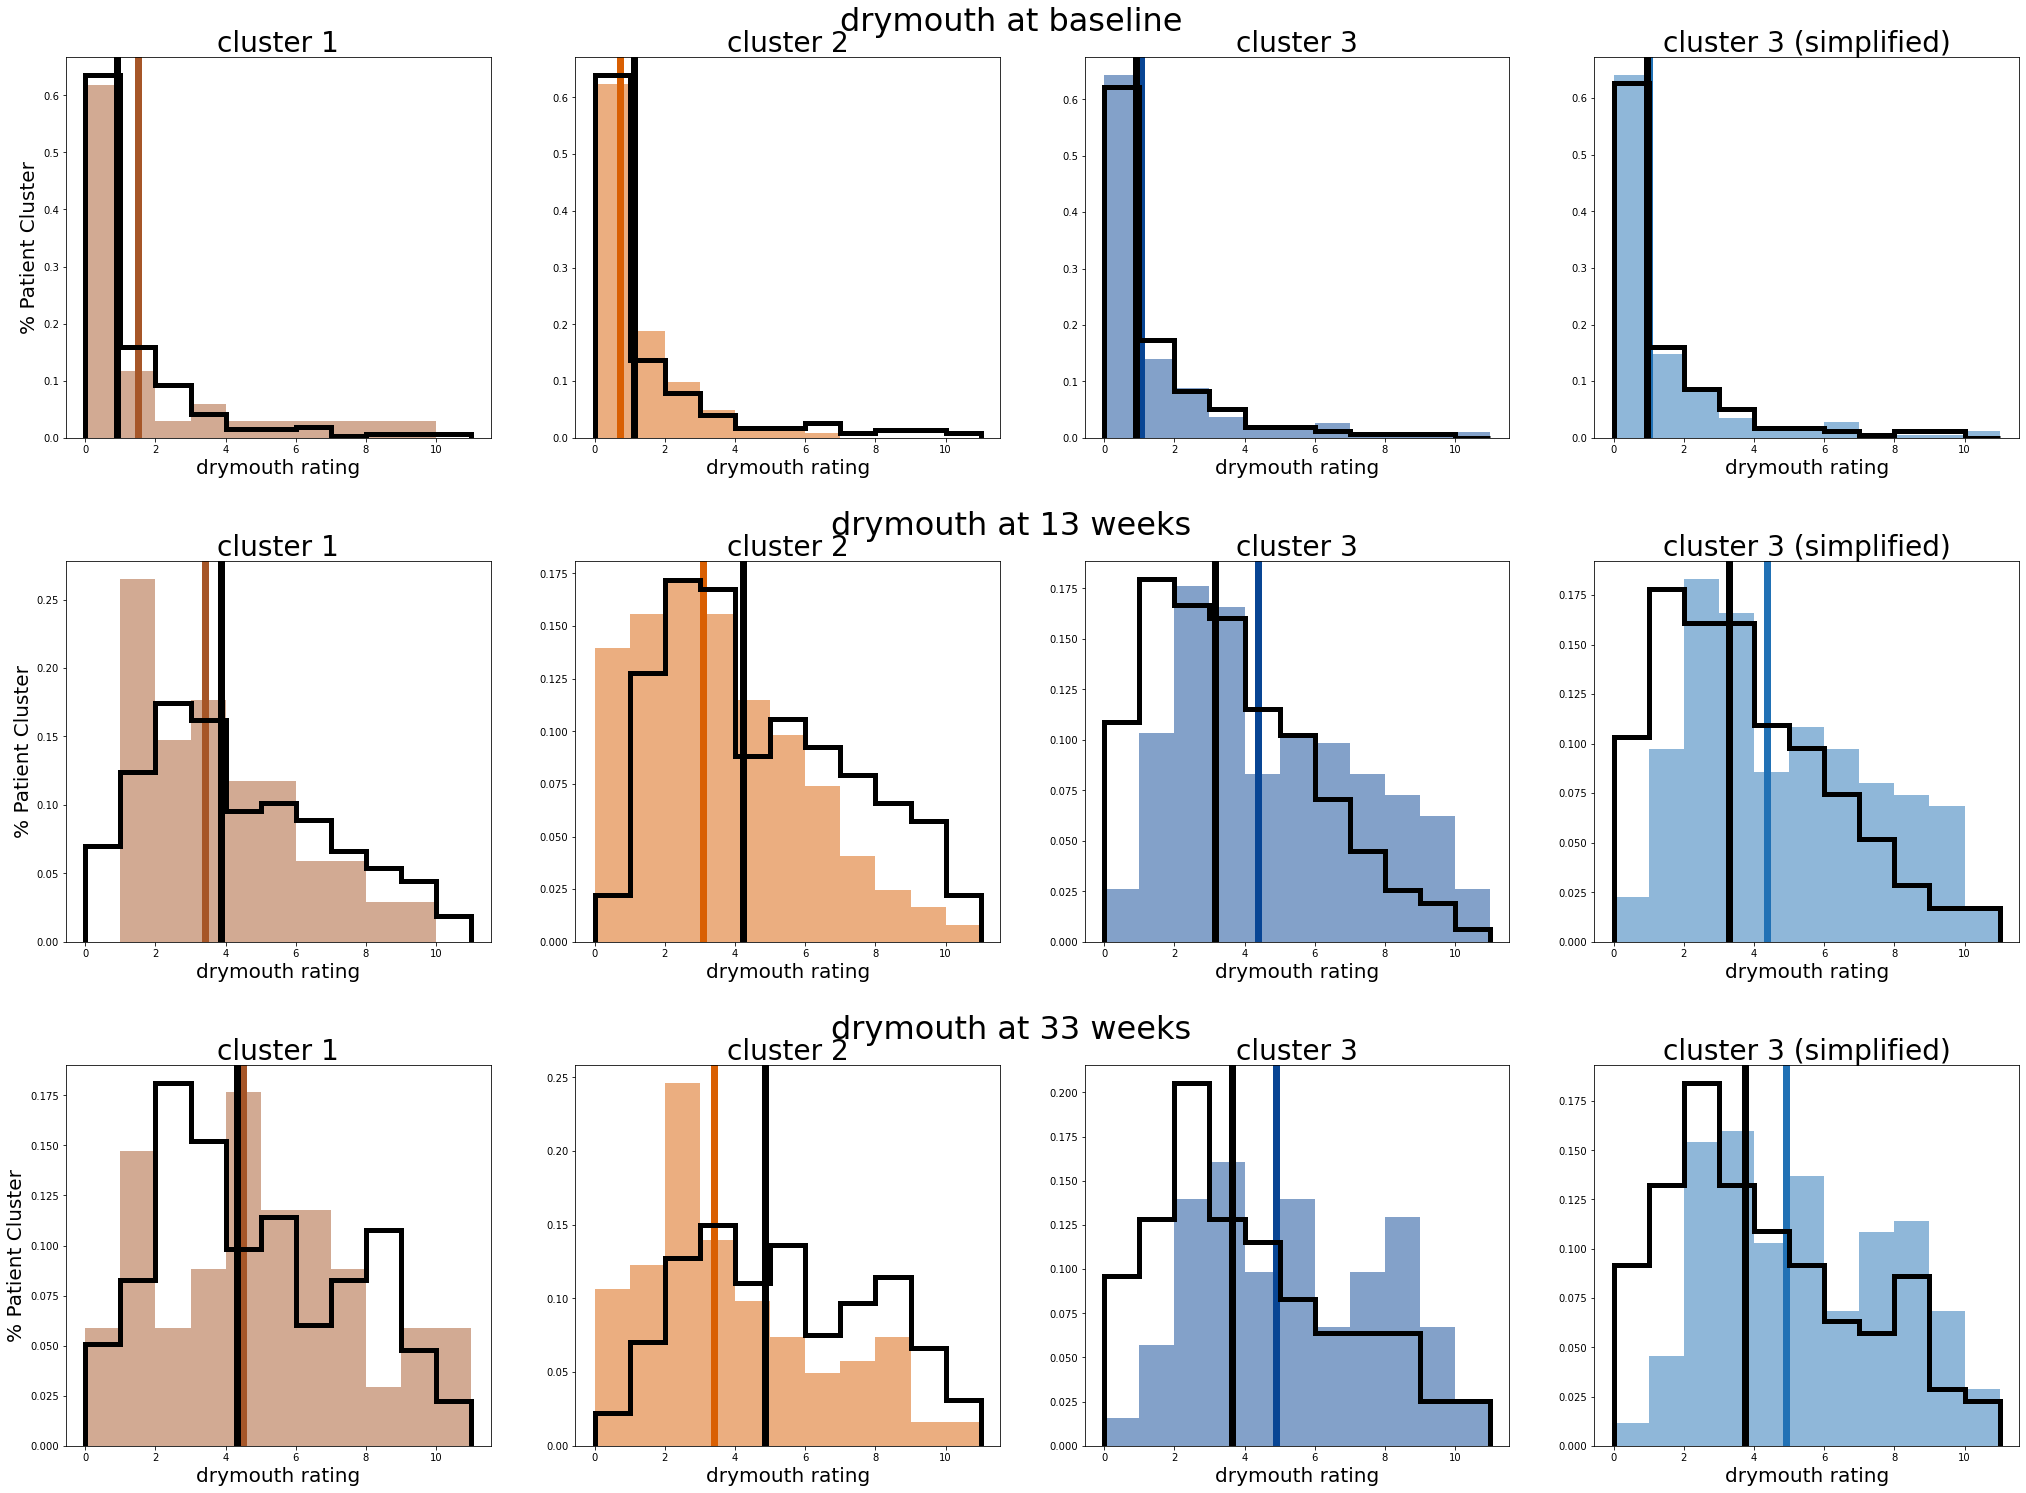

In [51]:
def bootstrap_conf_interval(vals, n = 200):
    results = []
    for i in range(n):
        tempvals = np.random.choice(vals,size=len(vals),replace=True)
        results.append(tempvals.mean())
    results = sorted(results)
    minval = results[int(len(results)*.05)]
    maxval =results[int(len(results)*.95)]
    return [minval, vals.mean(), maxval] 

def symptom_histogram_alt(ct,symptom=None,datelist=[[0],[13],[33]],size=7,**kwargs):
    df = ct.get_cluster_df(**kwargs).copy()
    mimic_df = ct.get_cluster_df(use_mimic=True)
    
    cnames = []
    
    for cluster in sorted(df.dose_clusters.unique()):

        name = 'cluster ' + str(cluster+1)
        df[name] = df['dose_clusters'] == cluster
        cnames.append(name)
    cnames.append('cluster 3 (simplified)')
    df[cnames[-1]] = mimic_df.dose_clusters
    (figwidth,figheight) = ((ct.n_clusters+2)*size,len(datelist)*size)
    fig = plt.figure(figsize=(figwidth,figheight))
    subfigs = fig.subfigures(len(datelist),1,wspace=1)
    df_dates =df.dates.iloc[0]
    
    if symptom is None:
        symptom = ct.symptoms[0]
        
    for row, dates in enumerate(datelist):
        subfig = subfigs[row]
        weekstring = '-'.join([str(d) for d in dates]) if len(dates) > 1 else str(dates[0])  
        if weekstring == '0':
            weekstring = 'baseline'
        else:
            weekstring += ' weeks'
        subfig.suptitle(symptom + ' at ' + weekstring ,fontsize=32)
        axes = subfig.subplots(1,len(cnames))
        dlocs = [df_dates.index(d) for d in dates if d in df_dates]
        df['s'] = df['symptoms_'+symptom].apply(lambda x: np.max([x[d] for d in dlocs]))
        colors = ['#a65628','#d95f02','#084594','#2171b5','#9ecae1']

        for col, name in enumerate(cnames):
            axis = axes[col]
            for thing in [True,False]:
                color = colors[col]
                if thing is False:
                    color = 'black'
                subdf = df[df[name].astype(bool) == thing]
                hvals = subdf.s.values
                htype = 'stepfilled' if thing else 'step'
                alpha = 1 if (htype == 'step') else .5
                axis.hist(hvals,bins=[i for i in range(12)],color=color,alpha=alpha,linewidth=5,histtype=htype,density=True)
                if thing:
                    print(name, 'symptom at', dates, bootstrap_conf_interval(hvals))
                axis.axvline(hvals.mean(),color=color,linewidth=7) 
            axis.set_title(name,fontsize=28)
            axis.set_xlabel(symptom + ' rating',fontsize=20)
            if col <= 0:
                axis.set_ylabel('% Patient Cluster',fontsize=20)
    return 
symptom_histogram_alt(ct)

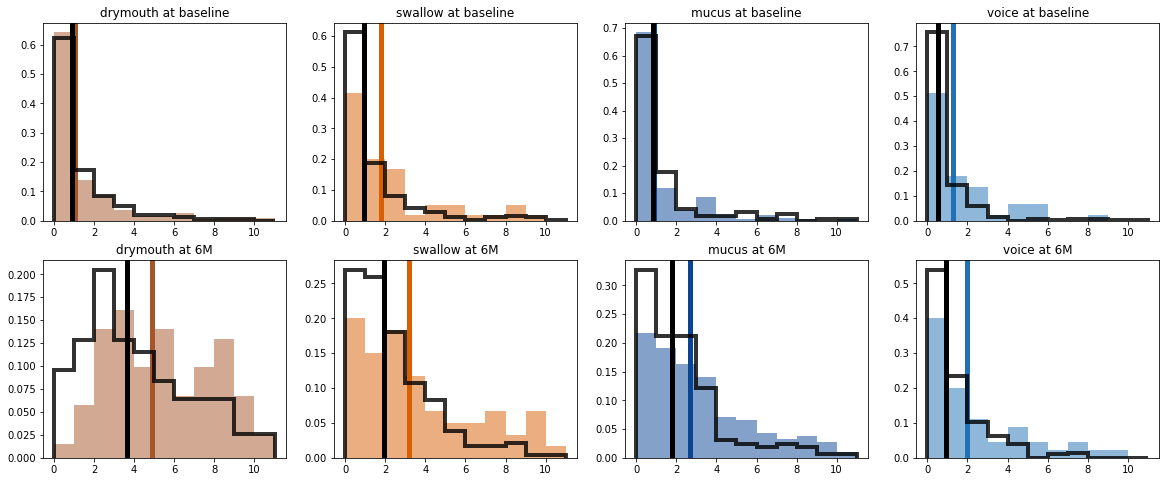

In [85]:
def symptom_histogram_alt2(ctlist,symptom=None,datelist=[[0],[33]],size=7,**kwargs):
    fig, ax = plt.subplots(len(datelist),len(ctlist),figsize = (5*len(ctlist),4*len(datelist)))
    colors = ['#a65628','#d95f02','#084594','#2171b5','#9ecae1']
    row = 0
    for ct in ctlist:
        symptom = ct.symptoms[0]
        df = ct.get_cluster_df(**kwargs).copy()
        df_dates =df.dates.iloc[0]
        mimic_df = ct.get_cluster_df(use_mimic=True)
        df['mimic'] = mimic_df['dose_clusters'].astype(bool)
        df['hd'] = df['dose_clusters'].apply(lambda x: x == df['dose_clusters'].max())
        df['not_hd'] = df['hd'].apply(lambda x: not x)
        for col,dates in enumerate(datelist):
            axis = ax[col,row]
            weekstring = '-'.join([str(d) for d in dates]) if len(dates) > 1 else str(dates[0])  
            if weekstring == '0':
                weekstring = 'baseline'
            elif dates[0] == 33:
                weekstring = '6M'
            else:
                weekstring += ' weeks'
            dlocs = [df_dates.index(d) for d in dates if d in df_dates]
            df['s'] = df['symptoms_'+symptom].apply(lambda x: np.max([x[d] for d in dlocs]))
            for i, column in enumerate(['hd','not_hd']):
                subdf = df[df[column].astype(bool)]
                hvals = subdf.s.values
                htype = 'stepfilled' if (column == 'hd') else 'step'
                alpha = .8 if (htype == 'step') else .5
                color = 'black' if column == 'not_hd' else colors[row]
                axis.hist(hvals,bins=[i for i in range(12)],color=color,alpha=alpha,linewidth=4,histtype=htype,density=True)
                if column != 'mimic':
                    axis.axvline(hvals.mean(),color=color,linewidth=5) 
            axis.set_title(symptom + ' at ' +weekstring)
        row += 1
symptom_histogram_alt2([ct,swallow_ct,mucus_ct, voice_ct])

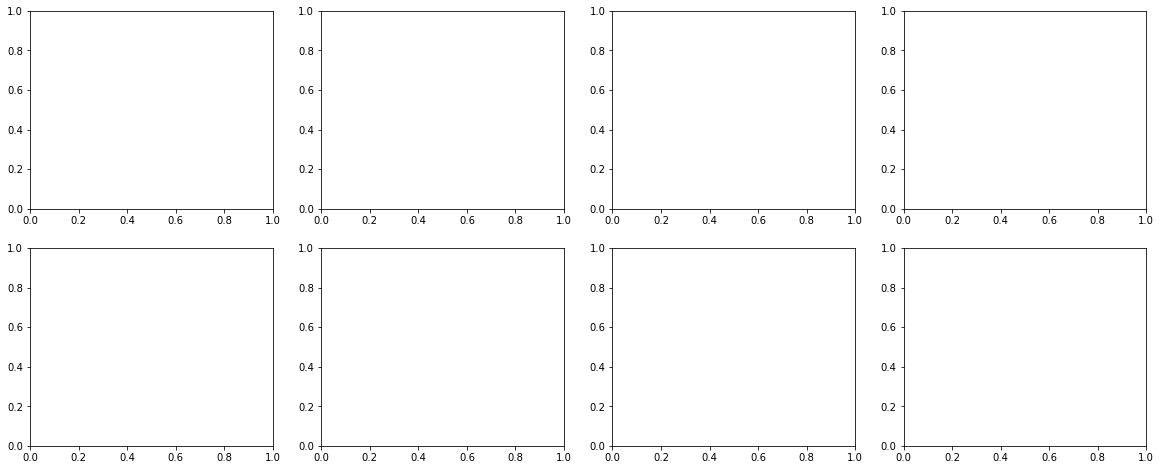

In [90]:
def all_cluster_df(ctlist,symptom=None,datelist=[[0],[33]],size=7,**kwargs):
    #assume ilftering is the same
    fig, ax = plt.subplots(len(datelist),len(ctlist),figsize = (5*len(ctlist),4*len(datelist)))
    colors = ['#a65628','#d95f02','#084594','#2171b5','#9ecae1']
    row = 0
    main_df = None
    new_cols = []
    for ct in ctlist:
        symptom = ct.symptoms[0]
        df = ct.get_cluster_df(**kwargs).copy()
        mimic_df = ct.get_cluster_df(use_mimic=True,**kwargs).copy()
        if main_df is None:
            main_df = df.drop(['dose_clusters'],axis=1)
        colname = symptom + '_cluster'
        new_cols.append(colname)
        new_cols.append(colname + '_mimic')
        main_df[colname] = df['dose_clusters']
        main_df[colname + '_mimic'] = mimic_df['dose_clusters']
        
        
    
    return main_df, new_cols
combined_df, new_cluster_cols  = all_cluster_df([ct,swallow_ct,mucus_ct, voice_ct])

In [106]:
def format_for_table(df):
    df = df.copy()
    to_keep = ['is_male','tstage','nstage','hpv','subsite','treatment']
    df['tstage'] = df.t_stage.apply(lambda x: 'other' if x not in ['t3','t4'] else x)
    def format_n(string):
        if string in ['n2a','n2b']:
            return 'n2a/b'
        if string in ['n2c','n3']:
            return 'n2c/n3'
        return 'other'
    df['nstage'] = df.n_stage.apply(format_n )
    df['subsite'] =  df.subsite.apply(lambda x: 'other' if x not in ['BOT','Tonsil'] else x)
    def format_treatment(string):
        if string in ['IMPT','VMAT'] or:
            return 'IMPT/VMAT'
        if string in ['IMRT']:
            return string
        if string == '3-D plan' or '3d' in str(string).lower():
            return '3D Conformational'
        print(string)
        return 'other'
    df['treatment'] = df.Technique.apply(format_treatment)
    return df.treatment.unique()
format_for_table(combined_df)

IMRT(VMAT)
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan


array(['IMPT/VMAT', 'IMRT', 'other', '3D Conformational'], dtype=object)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import ComplementNB

def test_cv_models(ct,key=None,confounders=None,models=None,include_mimic=True,include_delong=True):
    if models is None:
        models = [
            ComplementNB(),
            LogisticRegression(class_weight='balanced',random_state=0),
            LogisticRegression(penalty='l1',solver='saga',class_weight='balanced',random_state=0),
            LogisticRegression(penalty='elasticnet',l1_ratio=.5,solver='saga',class_weight='balanced',random_state=0),
            RandomForestClassifier(n_estimators=500,class_weight='balanced',random_state=0),
            RandomForestClassifier(n_estimators=500,max_depth=3,random_state = 0),
            RandomForestClassifier(n_estimators=500,max_depth=3,class_weight='balanced',random_state = 0),
            RandomForestClassifier(n_estimators=500,max_depth=10,random_state = 0),
            RandomForestClassifier(n_estimators=500,max_depth=10,class_weight='balanced',random_state = 0),
        ]
    thresholds = [3,5,7]
    results = []
    if confounders is None:
        confounders = ct.default_confounders[:]
    for model in models:
        for t in thresholds:
            res = ct.get_cv_auc(threshold=t,model=model,confounders=confounders)
            if include_delong:
                res['delong_pval'] = ct.delong_roc(threshold=t,model=model,confounders=confounders)
            if include_mimic:
                res2 = ct.get_cv_auc(threshold=t,model=model,confounders=confounders,use_mimic=True)
                for k,v in res2.items():
                    res[k+'_mimic'] = v
                if include_delong:
                    res['delong_pval_mimic'] = ct.delong_roc(threshold=t,model=model,confounders=confounders,use_mimic=True)
            if key is not None:
                res['key'] = key
            res['threshold'] = t
            res['model'] = str(model)
            res['base_roc'] = res['roc'] - res['roc_change']
            results.append(res)
    return results

def best_model_df(c, metric='base_roc',**kwargs):
    return pd.DataFrame(test_cv_models(c,**kwargs)).sort_values([metric,'threshold'],kind='mergesort',ascending=False).groupby(['threshold',metric,'model']).first()

# best_model_df(ct)

In [ ]:
def plot_best_models(results,basetitle='drymouth cv'):
    dfs = [pd.DataFrame(res) for res in results]
    #I assume these all have the same set of models
    n_models = len(dfs[0].model.unique())
    colors = ['#1b9e77','#d95f02','#7570b3','#e7298a','grey','navy','#e6ab02']
    n_rows = len(dfs)
    fig,axes = plt.subplots(n_rows,n_models,figsize=(8*n_rows,6*n_models))
    ymin = 0
    ymax = 0
    def format_model(m):
        m = str(m).replace('Regression','').replace("Classifier",'')
        m = re.sub(r'[a-zA-z]+\=', '', m)
        return m
    for row, df in enumerate(dfs):
        col=0
        for model, subdf in df.groupby('model'):
            axis = axes[row,col]
            subdf.plot(kind='barh',x='threshold',y=['roc_change','roc_change_mimic','f1_change','f1_change_mimic'],ax=axis,color=colors)
            col+=1
            (min_y, max_y) = axis.get_xlim()
            ymin = min(min_y,ymin)
            ymax = max(max_y,ymax)
            axis.set_title(format_model(model) + ' | ' + basetitle)
    [[ax.set_xlim((ymin,ymax)) for ax in row] for row in axes]
            
# models=[
#     LogisticRegression(class_weight='balanced',random_state=0),
#     RandomForestClassifier(n_estimators = 500, max_depth=5,class_weight='balanced',random_state=0),
#     LogisticRegression(penalty='elasticnet',l1_ratio=.5,solver='saga',class_weight='balanced',random_state=0),
# ]

# test = test_cv_models(ct,
#                       models=models,
#                      )
# test2 = test_cv_models(ClusterTester(sddf,ct.cluster_organs,n_clusters=2,cluster_features=ct.cluster_features),
#                       models=models,
#                      )
# plot_best_models([test,test2])

In [ ]:
def get_cluster_dvhs(ctester,features=None,organs=None,**kwargs):
    if features is None:
        features= ctester.cluster_features[:]
    if organs is None:
        organs = ctester.cluster_organs[:]
        
    df = ctester.get_cluster_df(**kwargs)
    opositions = [Const.organ_list.index(i) for i in organs if i in Const.organ_list]
    filter_organs = lambda x: np.array([x[o] for o in opositions])
    cluster_vals = {}
    for cluster, subdf in df.groupby('dose_clusters'):
        vals = []
        for feature in features:
            farray = np.stack(subdf[feature].apply(filter_organs).values)
            vals.append(farray.T)
        vals = np.stack(vals,axis=-1) #organs x patients x features
        vals = np.swapaxes(vals,1,-1) #organs x features x patients
        cluster_vals[cluster] = vals
    return cluster_vals

def get_rule_points(ct):
    rule = list(ct.current_rules.values())[0][0]
    features = rule['features']
    thresholds = rule['thresholds']
    get_val = lambda x: re.match('V(\d+)_([a-zA-Z_]+)',x).groups()
    fzip = [get_val(f) for f in features]
    odict = {}
    for i,(num, organ) in enumerate(fzip):
        num = int(num)
        thold = thresholds[i]
        odict[organ] = {'value': num,'threshold': thold}
    return odict

def plot_cluster_dvhs(ctester,quantiles=[.15,.5,.85],features=None,organs=None,include_mimic=False,size=6,**kwargs):
    if features is None:
        features= get_all_dvh(ct)#ctester.cluster_features[:]
    if organs is None:
        organs = ctester.cluster_organs[:]
    data = get_cluster_dvhs(ctester,features=features,organs=organs,**kwargs)
    if include_mimic and not kwargs.get('use_mimic',False):
        data2 = get_cluster_dvhs(ctester,features=features,organs=organs,use_mimic=True,**kwargs)
        data[ctester.n_clusters] = data2[1]
    (n_rows, n_cols) = (len(quantiles),len(organs))
    fig,axes = plt.subplots(n_rows,n_cols,figsize=(1.5*size*n_cols,size*n_rows))
    xlabels = [int(f[1:]) for f in features]
    ylim = np.max([v.max() for k,v in data.items()])
    colors = ['#1b9e77','#d95f02','#7570b3','#e7298a','grey','navy','#e6ab02']
    rules = get_rule_points(ctester)
    format_title = lambda x: x.replace('Lt','Ipsilateral').replace('Rt','Contralateral').replace('_',' ')
    for clustkey, carray in data.items():
        for col, organ in enumerate(organs):
            rule = rules.get(organ)
            qtiles = np.nanquantile(carray[col],quantiles,axis=-1)
            for row,quant in enumerate(qtiles):
                axis = axes[row,col]
                axis.plot(xlabels,quant,linewidth=4,color=colors[clustkey])
                axis.set_ylim((0,ylim*1.1))
                axis.set_title(format_title(organ) + ' ' + str(100*quantiles[row]) + '%')
                if rule is not None:
                    corner = [rule['value'],rule['threshold']]
                    rheight = ylim - corner[1]
                    rwidth = xlabels[-1] - corner[0]
                    rect = Rectangle(corner,rwidth,rheight,alpha=.1,facecolor='red')
                    axis.add_patch(rect)
    return
    

from matplotlib.patches import Rectangle
plot_cluster_dvhs(ct)

In [ ]:
def plot_cluster_dvhs_alt(ctester,quantile_levels=[[.3,.70]],features=None,organs=None,include_mimic=False,size=5,**kwargs):
    #variant where it's all one column
    #assume quantiles is 3 values (lower bound, mean, upper bound)
    if features is None:
        features= get_all_dvh(ct)#ctester.cluster_features[:]
    if organs is None:
        organs = ctester.cluster_organs[:]
    print(organs)
    data = get_cluster_dvhs(ctester,features=features,organs=organs,**kwargs)
    if include_mimic and not kwargs.get('use_mimic',False):
        data2 = get_cluster_dvhs(ctester,features=features,organs=organs,use_mimic=True,**kwargs)
        data[ctester.n_clusters] = data2[1]
    n_rows = (len(organs)//2) + 1
    fig,axes = plt.subplots(n_rows,2,figsize=(3*size,size*n_rows))
    xlabels = [int(f[1:]) for f in features]
    ylim = np.max([v.max() for k,v in data.items()])
    colors = ['#a65628','#d95f02','#084594','#2171b5','#9ecae1']
    rules = get_rule_points(ctester)
    format_title = lambda x: x.replace('Lt','Ipsilateral').replace('Rt','Contralateral').replace('_',' ')
    
    for clustkey, carray in data.items():
        color = colors[clustkey]
        row = 0
        col = 0
        for pos, organ in enumerate(organs):
            axis=axes[row,col]
            col += 1
            if col > 1:
                col = 0
                row += 1
            rule = rules.get(organ)
            avg = np.nanmedian(carray[pos],axis=-1)
            axis.plot(xlabels,avg,linewidth=4,color=color)
            for quantiles in quantile_levels:
                qtiles = np.nanquantile(carray[pos],quantiles,axis=-1)
                axis.fill_between(xlabels,qtiles[0],qtiles[-1],facecolor=color,alpha=.2)
                for q in qtiles:
                    axis.plot(xlabels,q,linewidth=2,alpha=.75)
                
            axis.set_ylim((0,ylim*1.1))
            axis.set_title(format_title(organ),fontsize=25)
            if rule is not None:
                corner = [rule['value'],rule['threshold']]
                rheight = ylim - corner[1]
                rwidth = xlabels[-1] - corner[0]
                rect = Rectangle(corner,rwidth,rheight,alpha=.1,facecolor='grey')
                axis.add_patch(rect)
                
    return

from matplotlib.patches import Rectangle
plot_cluster_dvhs_alt(ct)

In [ ]:
def get_dvhs(ctester,features=None,organs=None,**kwargs):
    if features is None:
        features= ctester.cluster_features[:]
    if organs is None:
        organs = ctester.cluster_organs[:]
        
    df = ctester.get_cluster_df(**kwargs)
    opositions = [Const.organ_list.index(i) for i in organs if i in Const.organ_list]
    filter_organs = lambda x: np.array([x[o] for o in opositions])
    vals = []
    for feature in features:
        farray = np.stack(df[feature].apply(filter_organs).values)
        vals.append(farray.T)
    vals = np.stack(vals,axis=-1) #organs x patients x features
    vals = np.swapaxes(vals,1,-1) #organs x features x patients
    return vals

def fix_oname(name):
    return name.replace('Lt_','Ips_').replace('Rt_','Contra_').replace('_',' ')

def multivar_odds(x,y,
                  regularize = True,
                  scale=True,
                  max_odds = 100,
                  alpha=None,
                   ):
    #this version uses sklearn because it doesn't work without it's good regularization
    if y.max() > 1:
        y = y/y.max()
        
    valid = [(x[:,i].std() > .001) for i in range(x.shape[1])]
    good_indices = [i for i,v in enumerate(valid) if v]
    good_x = np.stack([x[:,idx] for idx in good_indices],axis=1).astype(float)
    if regularize:
        good_x = (good_x - good_x.mean(axis=0))/(np.nanstd(good_x,axis=0))
    if scale:
        good_x = (good_x - good_x.min(axis=0))/(good_x.max(axis=0) - good_x.min(axis=0))
    good_x = np.nan_to_num(good_x,0)
    boolean = (len(np.unique(y)) <= 2)
    if boolean:
        if alpha is None:
            alpha = .1
        model = LogisticRegression(penalty='l2',C=1/alpha)
    else:
        if alpha is None:
            alpha = .0000001
        model = Ridge(alpha=alpha,positive=True)
    odds_vals = []
    
    m = model.fit(x,y)
    good_odds = m.coef_.ravel()
    print(good_odds.shape)
    if boolean:
        good_odds = np.exp(good_odds)
    odds = []
    pos = 0
    for is_valid in valid:
        if is_valid: 
            o = good_odds[pos]
            pos += 1
        else:
            o = 0
        if max_odds is not None:
            o = np.min([max_odds,o])
            if not boolean:
                o = np.max([-max_odds,o])
        odds.append(o)
    return np.array(odds)

def test_dvh_info(ctester,threshold=-1,metric='info',confounders=None,use_change=False,features=None,organs=None):
    if features is None:
        features= get_all_dvh(ctester)
    if confounders is None:
        confounders = ctester.default_confounders[:]
    confounder_df = ctester.df[confounders]
#     organs =  Const.organ_list[:] 
    if organs is None:
        organs = ctester.cluster_organs[:]
    darray = get_dvhs(ctester,features=features,organs=organs) #
    darray = np.swapaxes(darray,-1,0) #patients x features x organs
    darray = darray.reshape((darray.shape[0],-1)) #patients x features - organs
    darray = (darray - darray.mean(axis=1).reshape(-1,1))/(.0001 + darray.std(axis=1).reshape(-1,1))
    darray = (darray - darray.min(axis=1).reshape(-1,1))/(darray.max(axis=1).reshape(-1,1) - darray.min(axis=1).reshape(-1,1))
    darray = np.nan_to_num(darray)
    outcome = ctester.get_outcome(threshold=threshold,use_change=use_change)
    if confounders is not None and len(confounders) > 0:
        merged = np.concatenate([darray,confounder_df.values],axis=-1)
    else:
        merged = darray
    if 'odds' in metric and 'multi' in metric:
        info = multivar_odds(merged,outcome)
    else:
        if threshold > 0:
            if metric == 'info':
                info = mutual_info_classif(merged,outcome,n_neighbors=6,random_state=0)
            elif metric == 'pvalue':
                info = 1 - f_classif(merged,outcome)[1]
            else:
                info = f_classif(merged,outcome)[0]
        else:
            if metric=='info':
                info = mutual_info_regression(merged,outcome,n_neighbors=6,random_state=0)
            elif metric== 'pvalue':
                info = 1 - f_regression(merged,outcome)[1]
            else:
                info = f_regression(merged,outcome)[0]
    info = np.nan_to_num(info,1)
    res = {}
    pos = 0
    for f in features:
        values = []
        entry = {}
        for o in organs:
            curr_info = info[pos]
            values.append(curr_info)
            entry[fix_oname(o)] = curr_info
            pos += 1
        res[f] = entry
    df = pd.DataFrame(res)
    df['max'] = df.apply(lambda x: np.mean(x),axis=1)
    df = df.sort_values('max',ascending=False)
#     df[ = df.apply(lambda x: np.max(x),axis=1)
    return df.drop('max',axis=1)

def plot_dvh_correlations(ct,
                          metrics=None,
                          features = None,
                          thresholds=[-1],
                          organs = None,
                          **kwargs):
    if metrics is None:
        metrics = ['info','f-statistic']
    fig = plt.figure(constrained_layout=True,figsize=(10*len(metrics),len(thresholds)*5))
    axes = fig.subfigures(len(thresholds),1)
    if organs is None:
        organs = sorted(ct.cluster_organs[:])
    order = [fix_oname(o) for o in organs]
    color_dict = {
        'info': 'Blues',
        'f-statistic': "Greens",
        'multivar_odds': 'Purples'
    }
    for row, threshold in enumerate(thresholds):
        use_change = False
        thold = np.abs(threshold)
        if threshold < 0:
            use_change = True
        if thold == 1:
            thold = 0
                
        subfig = axes[row]
        title = ct.symptoms[0] 
        if use_change:
            title = 'Δ' + title
        if thold > 1:
            title += '>=' +str(thold)
        else:
            title += ' (linear)'
        subfig.suptitle(title,fontsize=35)
        subplots = subfig.subplots(1,len(metrics))
        for col, metric in enumerate(metrics):
            
            ax = subplots[col]
            temp = test_dvh_info(ct,
                                 metric=metric,
                                 use_change=use_change,
                                 threshold=thold,
                                 features=features,
                                 organs=organs,
                                 **kwargs)
            temp['mean'] = temp.values.mean(axis=1)
            d = temp.loc[order]
            d.columns = [c.replace('_','\n') for c in d.columns]
            sns.heatmap(d,ax=ax,cmap=color_dict.get(metric,'Reds'),annot=True)  
            
            title =  metric.replace('_',' ')
            ax.set_title(title,fontdict={'fontsize': 25})
    return fig,axes

plot_dvh_correlations(ct,
                      metrics=['info','multivar_odds','f-statistic'],
                      features = ['V20','V25','V30','V35','V40','V45','V50','V55','V60','V70','mean_dose'],
                      thresholds = [5,-5],
                      confounders=['hpv'],
                      organs = ct.cluster_organs + ['Tongue','Extended_Oral_Cavity','Soft_Palate'],
                     )

In [ ]:
plot_dvh_correlations(ct_i,
                      metrics=['info','multivar_odds','f-statistic'],
                      features = ['V20','V25','V30','V35','V40','V45','V50','V55','V60','V70','mean_dose'],
                      thresholds = [5,-5],
                      confounders=['hpv'],
                      organs = ct_i.cluster_organs + ['Tongue','Extended_Oral_Cavity','Soft_Palate']
                     )

In [ ]:
def get_rule_points(ct):
    rule = list(ct.current_rules.values())[0][0]
    features = rule['features']
    thresholds = rule['thresholds']
    get_val = lambda x: re.match('V(\d+)_([a-zA-Z_]+)',x).groups()
    fzip = [get_val(f) for f in features]
    odict = {}
    for i,(num, organ) in enumerate(fzip):
        num = int(num)
        thold = thresholds[i]
        odict[organ] = {'value': num,'threshold': thold}
    return odict
get_rule_points(ct)

In [ ]:
def get_mimic_cv_results(df):
    organ_lists = [
#         [
#             'Genioglossus_M',
#             'Rt_Parotid_Gland','Lt_Parotid_Gland',
#             'Rt_Submandibular_Gland','Lt_Submandibular_Gland',
#         ],
                [
#             'Tongue',
                    'Hard_Palate',
            'Rt_Parotid_Gland','Lt_Parotid_Gland',
            'Rt_Submandibular_Gland','Lt_Submandibular_Gland',
        ],
#         [
#             'Mylogeniohyoid_M',
#             'Rt_Parotid_Gland','Lt_Parotid_Gland',
#             'Rt_Submandibular_Gland','Lt_Submandibular_Gland',
#         ],
#         [
#             'Rt_Parotid_Gland','Lt_Parotid_Gland',
#             'Rt_Submandibular_Gland','Lt_Submandibular_Gland',
#         ],
    ]
    confounder_lists = [
        None,
#         ['t4','t3','n_severe','hpv'],
#         ['t4','t3','n_severe','hpv','Parotid_Gland_limit'],
#         ['t4','t3','n2','n3','hpv','BOT','Tonsil','Parotid_Gland_limit'],
#         ['t4','t3','n_severe','hpv','BOT','Tonsil','Parotid_Gland_limit','Esophagus_limit'],
    ]
    symptom_lists = [
        ['drymouth'],
#         ['swallow'],
#         ['taste'],
#         ['teeth'],
#         ['choke'],
#         ['sob'],
#         ['voice'],
#         ['nausea','vomit'],
#         ['drymouth','swallow'],
#         ['mucus','mucositis'],
    ]
    outcome_date_list = [
        [13],
        [33]
    ]
    feature_lists = [
#         ['V40','V45','V50','V55','V60'],
#         ['V40','V45','V50','V55','V60','V65'],
        ['V25','V30','V35','V40','V45','V50','V55','V60'],
#         ['V40','V50','V60'],
    ]
    
    thresholds = [5]
    cluster_sizes = [
        2,
        3,
        4,
    ]
    
    models = [
#         LogisticRegression(class_weight='balanced',random_state=0),
        LogisticRegression(penalty='elasticnet',l1_ratio=.5,solver='saga',class_weight='balanced',random_state=0)
#         RandomForestClassifier(max_depth=3,class_weight='balanced'),
    ]
    n_runs = np.prod([len(l) for l in [outcome_date_list,organ_lists,confounder_lists,symptom_lists,feature_lists,thresholds,cluster_sizes,models]])
    i = 1
    result_list = []
    for organs in organ_lists:
        for symptoms in symptom_lists:
            for features in feature_lists:
                for n in cluster_sizes:
                    for outcome_dates in outcome_date_list:
                        ct = ClusterTester(df,
                                           organs,
                                           n_clusters=n,
                                           cluster_features = features,
                                           symptoms=symptoms,
                                           outcome_dates=outcome_dates,
                                          )
                        #pre-compute mimic model results
                        ct.get_cluster_df(use_mimic=True)
                        for confounders in confounder_lists:
                            for model in models:
                                for threshold in thresholds:
                                    base_results = ct.get_cv_auc(threshold=threshold,
                                                                 model=model,
                                                                 use_mimic = False,
                                                                 confounders=confounders)
                                    mimic_results = ct.get_cv_auc(threshold=threshold,
                                                                 model=model,
                                                                 use_mimic = True,
                                                                 confounders=confounders)
                                    clust_resultlist = [(c,ct.get_cv_auc(threshold=threshold,confounders=confounders,cluster=c)) for c in range(ct.n_clusters)]
                                    entry = {
                                        'organs': organs,
                                        'symptoms': symptoms,
                                        'features': features,
                                        'n_clusters': n,
                                        'confounders': confounders,
                                        'model': model,
                                        'threshold': threshold,
                                        'dates': ''.join([str(i) for i in outcome_dates]) if len(outcome_dates) > 0 else outcome_dates[0],
                                    }
                                    print('_____',np.round(100*i/n_runs,2),'%_______')
                                    print(entry)
                                    for k,v in base_results.items():
                                        mr = mimic_results.get(k)
                                        entry[k+'_base'] = v
                                        entry[k+'_mimic'] = mr
                                        if k.replace('_change','') in ['roc','mcc','f1']:
                                            print('base '+k,v,'mimic '+k,mr)
                                    for (c,res) in clust_resultlist:
                                        for k,v in res.items():
                                            entry[k+'_'+str(c)] = v
                                            if k.replace('_change','') in ['roc','mcc','f1']:
                                                print(str(c) + k,v)
                                    result_list.append(entry)
                                    print('___________')
                                    print()
                                    i += 1
    return result_list


def format_cv_results(results):
    laucdf = pd.DataFrame(results).sort_values('roc_change_mimic')
    groups = ['symptoms','threshold','n_clusters','organs','features','confounders']
    for col in ['organs','symptoms','features','confounders']:
        laucdf[col] = laucdf[col].apply(lambda x: ','.join(x))
    for c in groups:
        if len(laucdf[c].unique()) < 2:
            groups.remove(c)
    return laucdf.groupby(groups).first()

def plot_cvtest(cvtest,y=[],ykey='roc_change',colcol='dates',rowcol='n_clusters',x='threshold',**kwargs):
    #I reveresed rows and cols on accidents but it's too complicated to fix 
    df = pd.DataFrame(cvtest)
    colors =['#1b9e77','#d95f02','#7570b3','#e7298a','lightgrey','navy','#e6ab02']
    for col in ['organs','symptoms','features','confounders']:
        try:
            df[col] = df[col].apply(lambda x: ','.join(x) if x is not None else 'None')
        except Exception as e:
            print(col,e)
    for key, value in kwargs.items():
        if key in df.columns:
            df = df[df[key] == value]
    nrows = len(df[rowcol].unique())
    ncols = len(df[colcol].unique())
    fig,axes = plt.subplots(ncols,nrows,figsize=(5*nrows,6*ncols))
    
    colpos = 0
    ymin = 0
    ymax = 0
    for col, coldf in df.groupby(colcol):
        rowpos = 0
        for row,subdf in coldf.groupby(rowcol):
            subdf= subdf.dropna(axis=1,how='all')
            ytemp =  [c for c in subdf.columns if ykey in c] +y
            if ncols > 1:
                axis = axes[colpos,rowpos]
            else:
                axis = axes[rowpos]
            original_roc = subdf.roc_base - subdf.roc_change_base
            print(original_roc.min(),original_roc.mean(),original_roc.max())
            axis.set_title('ΔAUC (base=' + str(np.round(original_roc.mean(),3)) +' , n='+str(row)+', '+ str(col) + 'wks' +')')
            subdf[ytemp+[x]].fillna(0).plot(kind='barh',y=ytemp,x=x,ax=axis,color=colors)
            h, l = axis.get_legend_handles_labels()
            l = ['C-' + text.replace(ykey,'').replace('_','').replace('base','All') for text in l]
            axis.legend(h[::-1], l[::-1])
            rowpos += 1
            (min_y, max_y) = axis.get_xlim()
            ymin = min(min_y,ymin)
            ymax = max(max_y,ymax)
        
        colpos+=1
    for row in axes:
        if ncols > 1:
            for ax in row:
                ax.set_xlim((ymin,ymax))
        else:
            row.set_xlim((ymin,ymax))
    return df


# cvtest = get_mimic_cv_results(sddf3)
plot_cvtest(cvtest,colcol='threshold',x='dates')
# format_cv_results(cvtest).to_csv(Const.data_dir+'base_organ_cv_test_results_'+timestamp()+'.csv')
# format_cv_results(cvtest).plot(kind='barh',y=['roc_change_base','roc_change_mimic'],figsize=(10,30))

In [ ]:
def get_limit_performance(ct,
                          other_cols = [
                              't4','t3','t_severe',
                              'n3','n_severe',
                              'IMRT','VMAT',
                              'age_65','old',
                              'performance_1','performance_2','performance_high'
                          ]
                         ):
    df = ct.df.copy()
    limits = [c for c in df.columns if '_limit' in c]
    y = ct.get_outcome()
    results = []
    for limit in limits + other_cols:
        subdf = df[~df[limit].isnull()]
        ypred = np.zeros((len(y),2))
        ypred[:,1] = subdf[limit].values
        ypred[:,0] = ~subdf[limit].values
        res = get_stratification_metrics(y,ypred)
        res['name'] = limit
        results.append(res)
    return pd.DataFrame(results).sort_values('mcc',ascending=False)

get_limit_performance(ct)

In [ ]:
def get_confounder_correlations(ct,
                                use_cluster=True,
                                use_mimic=True,
                                cols = [
                                      't4','t3',
                                      'n2','n3',
                                      'HPV+',
                                      'IMRT','VMAT','IMPT',
                                      'BOT','Tonsil',
                                      'age_65',
                                      'performance_1','performance_2',
                                  ],
                                use_limits = False,
                                as_df=True,
                               ):
    df = ct.df.copy()
    name_map = {
        't4': 'T-stage 4',
        't3': 'T-stage 3',
        'n2': 'N-stage 2',
        'n3': 'N-stage 3',
        'hpv_pos': 'HPV+',
        't_severe': 'T-stage > 2',
        'n_severe': 'N-stage > 1',
        'age_65': 'age > 65',
        'performance_1_1': 'perf. score = 1',
        'performance_2_1': 'perf. score = 2',
        'performance_high': 'perf. score > 0',
    }
    df['HPV+'] = df.hpv.apply(lambda x: x==1)
    to_keep = cols[:]
    if use_cluster:
        cluster_df = ct.get_cluster_df()
        
        cluster_df = Utils.onehotify(df[['dose_clusters']])
        for col in cluster_df.columns:
            to_keep.append(col)
            df[col] = cluster_df[col]
            
    if use_mimic:
        mimic_df = ct.get_cluster_df(use_mimic=True)
        df['simple_cluster'] = mimic_df['dose_clusters'].astype(bool)
        to_keep.append('simple_cluster')
    if use_limits:
        to_keep = to_keep + [c for c in df.columns if '_limit' in c and 'Brainstem' not in c and c not in cols]
    df = Utils.onehotify(df[to_keep],drop_first=True)
    thresholds = [5]
    results = []
    for use_change in [False,True]:
        for threshold in thresholds:
            y = ct.get_outcome(threshold = threshold,use_change=use_change)
            for col in df.columns:
                ypred = df[col].fillna(0).values
                if threshold > 0:
                    [effect,pval] = Metrics.boolean_fisher_exact(y,ypred)
                else:
                    [effect,pval] = Metrics.vector_chi2(y,ypred)
                if use_change:
                    t = -threshold
                else:
                    t = threshold
                cname = name_map.get(col,col)
                cname = cname.replace('_1','').replace('.0','').replace('_True','').replace('_','\n')
                cname = name_map.get(cname,cname)
                entry = {
#                     'outcome_change':use_change,
                    'threshold':t,
                    'covariate': cname,
                    'effect': effect,
                    'pvalue': pval,
                }
                results.append(entry)
    if as_df:
        results = pd.DataFrame(results)
    return results#.groupby(['outcome_change','threshold','covariate']).first()

def plot_confounder_correlations(ct,**kwargs):
    ccors = get_confounder_correlations(ct,**kwargs)
    ccors['outcome'] = ccors.threshold.apply(lambda x: 'absolute >=' + str(x) if x >= 0 else 'change >=' + str(np.abs(x)) )
    ccors = ccors.sort_values('effect',ascending=False)
    chart = sns.catplot(
        data=ccors,
        height=12,
        aspect=1,
        x='effect',
        y='covariate',
        hue='outcome',
        kind='bar',
        orient='h',
        palette='colorblind',
    )
    ax = chart.facet_axis(0,0)
    for c in ax.containers:
        threshold = c.get_label()
        pvals = ccors[ccors.outcome==threshold].pvalue.values
        labels = [('' if p > .05 else '*') for p in pvals]
        ax.bar_label(c,labels=labels,label_type='edge',fontsize=20)
        ax.vlines(1,-.5,len(ccors.covariate.unique())-.5,color='lightgrey',linewidth=4)
    return ccors
plot_confounder_correlations(ct,use_limits=False,use_mimic=False,use_cluster=False)

In [ ]:
def plot_confounder_set_correlations(ctlist, **kwargs):
    res = []
    fig = plt.figure(constrained_layout=True,figsize=(30,15))
    axes = fig.subplots(2,1)
    for c in ctlist:
        ccors = get_confounder_correlations(c,as_df=False,**kwargs)
        ccors = [c for c in ccors if c['threshold'] == 5]
        symptom = c.symptoms[0]
        for item in ccors:
            item['symptom'] = symptom
        res.extend(ccors)
    res = pd.DataFrame(res)
    def get_sig(val):
        if val > .05:
            return 0
        return 6*(1 - val)**2
    res['significance'] = res['pvalue'].apply(get_sig)
    for key,axis in zip(['effect','significance'],axes):
        formatted = []
        for symptom, subdf in res.groupby('symptom'):
            entry = {'symptom': symptom}
            for covar, subsubdf in subdf.groupby('covariate'):
                entry[covar] = subsubdf[key].values[0]
            formatted.append(entry)
        formatted = pd.DataFrame(formatted)
        formatted = pd.DataFrame(formatted.set_index('symptom'))
        sns.heatmap(
            data = formatted,
            cmap = 'Blues' if key == 'effect' else 'Greens',
            annot=(key == 'effect'),
            square=True,
            annot_kws={'fontsize':30},
            ax = axis,
            vmin = 0,
            vmax = 6,
        )
    return

plot_confounder_set_correlations(
    [ct, mucus_ct, swallow_ct, voice_ct],
    use_limits=False,
    use_mimic=False,
    use_cluster=False,
)

In [ ]:
plot_confounder_set_correlations(
    [ct, mucus_ct, swallow_ct, voice_ct],
    use_limits=True,
    use_mimic=False,
    use_cluster=False,
    cols = [],
)

In [ ]:
plot_confounder_set_correlations(
    [ct, mucus_ct, swallow_ct, voice_ct],
    use_limits=True,
    use_mimic=False,
    use_cluster=False,
    cols = [],
)

In [ ]:
plot_confounder_correlations(ct,use_limits=True,use_mimic=False,use_cluster=False,cols=[])